# Predicting Hospital Readmission Rates for Diabetic Patients

#### This code is the final notebook of Team 8. The sections are as follows:
- 0
- 1
- 2
- 3
- 4


#### Note - In some cases in the notebook, AI tools were used to help with coding and debugging. This was predominantly used for tasks such as nicely formatting results, generating diagrams.

# 0 Utils

In [1]:
# Helps log the results of an experiment

import os
import pandas as pd
from datetime import datetime

RESULTS_FILE = "model_results_log.csv"

def log_result(
    model_name,
    params,
    mean_score,
    std_score=None,
    notes=None
):
    """
    Append a single experiment result to a CSV log.
    """
    row = {
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "model": model_name,
        "params": str(params),
        "mean_f1_macro": mean_score,
        "std_f1_macro": std_score,
        "notes": notes
    }

    df_row = pd.DataFrame([row])

    if os.path.exists(RESULTS_FILE):
        df_row.to_csv(RESULTS_FILE, mode="a", header=False, index=False)
    else:
        df_row.to_csv(RESULTS_FILE, mode="w", header=True, index=False)

    print(f"✔ Logged result for {model_name}")

# 1 Cleaning Data

#### We will not load test data here yet to prevent any accidental leakage. That will be done at the end of the notebook, in a seperate processing step.

In [2]:
data_path = "../dataset/diabetic_data_training.csv"
train_df=pd.read_csv(data_path)

print("training data shape:", train_df.shape)

print("training data")
display(train_df.head())


training data shape: (91589, 50)
training data


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
1,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
2,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
3,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
4,35754,82637451,Caucasian,Male,[50-60),?,2,1,2,3,...,No,Steady,No,No,No,No,No,No,Yes,>30


## 1.1 Checking Target Distribution Balance

In [3]:
less_than_30 = 0
more_than_30 = 0
not_readmitted = 0
for _, row in train_df.iterrows():
    if row["readmitted"] == "NO":
        not_readmitted += 1
    elif row["readmitted"] == ">30":
        more_than_30 += 1
    else:
        less_than_30 += 1
print("<30:", less_than_30)
print(">30:", more_than_30)
print("NO:", not_readmitted)

<30: 10245
>30: 31989
NO: 49355


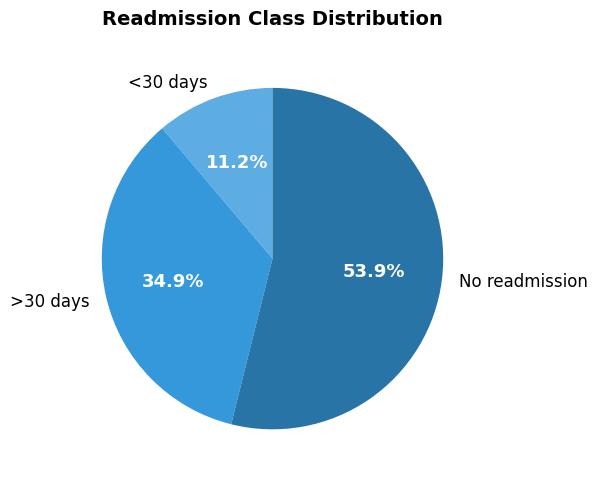

In [4]:
import matplotlib.pyplot as plt


class_counts = train_df['readmitted'].value_counts().sort_index()
labels = ['<30 days', '>30 days', 'No readmission']  
values = class_counts.values

colors = ['#5dade2', '#3498db', '#2874a6'] 

fig, ax = plt.subplots(figsize=(6, 6))

wedges, texts, autotexts = ax.pie(
    values, 
    labels=labels, 
    colors=colors, 
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 12}
)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(13)
ax.set_title('Readmission Class Distribution', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('class_distribution.pdf', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

#### This uneven split motivates us to use stratified folds for validation. Furthermore, we choose F1 macro as our main metric in order to take into account the class imbalance. We will also have to be careful to check confusion matrices and check if the models are forgetting the <30 class.

## 1.3. Missing Values

#### Some columns have a lot of values missing. For those, with missing values >70%, we could drop them as they are likely noise (and we can't really fill the values in with median / mode). However, what could potentially better is that we use a binary indicator, as a presence of a measurement can be a signal.

In [5]:
import numpy as np

train_df = train_df.replace('?', np.nan)

missing_column_fraction = (train_df.isnull().sum() / len(train_df))

very_high_missing = missing_column_fraction[missing_column_fraction > 0.7].index.tolist()
high_missing = missing_column_fraction[(missing_column_fraction > 0.2) & (missing_column_fraction <= 0.7)].index.tolist()
low_missing = missing_column_fraction[(missing_column_fraction > 0) & (missing_column_fraction <= 0.2)].index.tolist()
no_missing = missing_column_fraction[missing_column_fraction == 0].index.tolist()

print("Very high missing (>0.7)", very_high_missing)
print("High missing (0.7 > x > 0.2)", high_missing)
print("Low missing (0.2 > x > 0)", low_missing)
print("No missing", no_missing)

Very high missing (>0.7) ['weight', 'max_glu_serum', 'A1Cresult']
High missing (0.7 > x > 0.2) ['payer_code', 'medical_specialty']
Low missing (0.2 > x > 0) ['race', 'diag_1', 'diag_2', 'diag_3']
No missing ['encounter_id', 'patient_nbr', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [6]:
# Because A1Cresult and max_glu_serum have significant medical relevance, we will keep the values even though a lot are missing. Explained in section 3.1.3
# in report. We create a binary column flagging if the measurement exists and then create a column with ordered measurements.
very_high_missing.remove("A1Cresult")
very_high_missing.remove("max_glu_serum")

train_df['A1Cresult_not_recorded'] = train_df['A1Cresult'].isna().astype(int)
train_df['max_glu_serum_not_recorded'] = train_df['max_glu_serum'].isna().astype(int)

mapping_A1C = {
    'Norm': 1,
    '>7': 2,
    '>8': 3
}

mapping_glu = {
    'Norm': 1,
    '>200': 2,
    '>300': 3
}

train_df['A1Cresult_recorded'] = train_df['A1Cresult'].map(mapping_A1C).fillna(0).astype(int)
train_df['max_glu_serum_recorded'] = train_df['max_glu_serum'].map(mapping_glu).fillna(0).astype(int)
train_df.drop(columns=["A1Cresult"], inplace=True)
train_df.drop(columns=["max_glu_serum"], inplace=True)

In [7]:
# For other Very High Missing we create a binary column, whether the value has been recorded or not

for col in very_high_missing:
    train_df[col] = 1 - train_df[col].isnull().astype(int)
    train_df = train_df.rename(columns={col: f"is_{col}_recorded"})


# For High Missing we can create a new class of "Unknown", we don't need to create a seperate column to flag this is weird, as it will be
# correlated
for col in high_missing:
    train_df[col] = train_df[col].fillna("Unknown")


# For Low Missing we can reaplce with a median for numerical values, mode for non-numerical. For race, mode is reasonable because there 
# aren't many options, however, for daignoses we could do a new category unknown to not distort the distribution too much. 
for col in ["diag_1", "diag_2", "diag_3"]:
    train_df[col] = train_df[col].fillna("Unknown")

train_df[f'is_{col}_interpolated'] = train_df[col].isnull().astype(int)
train_df["race"] = train_df["race"].fillna(train_df["race"].mode()[0])


## 1.4. Making sense of the Data

In [8]:
# We can drop columns like encounter_id - we can see in the feature table that they are not classified as features. patient_nbr should not be
# dropped, as it will be used for grouping folds (some patients come to the hospital more times and we need them in the same fold to avoid leakage) 
train_df = train_df.drop("encounter_id", axis=1)

len(set(train_df["patient_nbr"].values))

65932

In [9]:
# Since age is actually an ordered column we will take the midpoint value 
def age_parser(age_string):
    bounds = age_string.strip("[]()").split("-")
    return (int(bounds[0]) + int(bounds[1])) // 2
train_df["age"] = train_df["age"].apply(lambda x: age_parser(x))


In [10]:
# If we check the IDS_mapping file we can see that the data in columns admission_type_id, discharge_disposition_id, admission_source_id
# shouldn't be ordered integers but strings - so we change them to strings and then do one-hot encoding
train_df["admission_type_id"] = train_df["admission_type_id"].astype(str)
train_df["admission_source_id"] = train_df["admission_source_id"].astype(str)
train_df["discharge_disposition_id"] = train_df["discharge_disposition_id"].astype(str)

In [11]:
int_cols = train_df.select_dtypes(include=['int', 'int64', 'int32']).columns.tolist()
print(int_cols)

['patient_nbr', 'age', 'is_weight_recorded', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'A1Cresult_not_recorded', 'max_glu_serum_not_recorded', 'A1Cresult_recorded', 'max_glu_serum_recorded', 'is_diag_3_interpolated']


## 1.5. Encoding into Numerical Values

#### Most models need numerical values so for columns with multiple options we can encode as binaries. However, we have to make sure we don't get an explosion of features. Hence we will use top N version of One-Hot-Encoding -> we will only do binary flags for most common N options

In [12]:
column_values = {}
for column in train_df.columns:
    unique_values = set(train_df[column])
    column_values[column] = unique_values
column_values

{'patient_nbr': {33947649,
  92667906,
  83623941,
  128319494,
  40763403,
  2752524,
  72351756,
  89391123,
  87031827,
  86507541,
  43515927,
  16121880,
  41287707,
  24117282,
  39583782,
  7471143,
  152698919,
  32899113,
  85196844,
  82968624,
  36438066,
  121372727,
  4849722,
  60031035,
  53870652,
  2621502,
  41287743,
  92274750,
  1835073,
  41680962,
  185991233,
  90701892,
  786501,
  57147462,
  64618560,
  24772680,
  95551560,
  87162957,
  88080462,
  44171343,
  38535246,
  67240017,
  43515990,
  9961560,
  61997148,
  112197726,
  111018078,
  59113566,
  5898339,
  112197735,
  23199849,
  47710314,
  24772716,
  21889134,
  96600177,
  2359413,
  20447352,
  102498426,
  524412,
  92536965,
  19136646,
  135,
  22937733,
  84410505,
  97648776,
  23724171,
  102236301,
  76021902,
  110231694,
  45613197,
  43909263,
  70254738,
  36044946,
  44957844,
  69992595,
  42074262,
  67633299,
  38011032,
  48758931,
  13107357,
  91357344,
  52297893,
  432554

In [13]:
# We first check whether columns are actually consistent - like having a column with 99% integers, 1% unknown or something would be annoying 
# in processing

result = []

for col in train_df.columns:
    series = train_df[col]
    total = len(series)
    numeric_count = series.apply(lambda x: isinstance(x, (int, float, np.integer, np.floating)) and not pd.isnull(x)).sum()
    string_count = series.apply(lambda x: isinstance(x, str)).sum()

    result.append({
        'Column': col,
        'Total': total,
        'Numeric': numeric_count,
        'String': string_count,
        'Type Breakdown': f"Strings: {string_count}, Numerics: {numeric_count}"
    })

breakdown_df = pd.DataFrame(result)
print(breakdown_df)


                        Column  Total  Numeric  String  \
0                  patient_nbr  91589    91589       0   
1                         race  91589        0   91589   
2                       gender  91589        0   91589   
3                          age  91589    91589       0   
4           is_weight_recorded  91589    91589       0   
5            admission_type_id  91589        0   91589   
6     discharge_disposition_id  91589        0   91589   
7          admission_source_id  91589        0   91589   
8             time_in_hospital  91589    91589       0   
9                   payer_code  91589        0   91589   
10           medical_specialty  91589        0   91589   
11          num_lab_procedures  91589    91589       0   
12              num_procedures  91589    91589       0   
13             num_medications  91589    91589       0   
14           number_outpatient  91589    91589       0   
15            number_emergency  91589    91589       0   
16            

In [14]:
# Now we see that we have consistent - either all-strings or all-integer columns. Now we can do the top N encoding where necessary.
# We just the value that would capture 90% of the data, 10% is "Other"

for col in train_df.columns:
    if train_df[col].dtype == 'object':
        freq_dict = train_df[col].value_counts().nlargest(500).to_dict()
        if len(freq_dict) > 10:
            print(f"Column: {col}")
            print(freq_dict)
            print("\n")

Column: discharge_disposition_id
{'1': 54187, '3': 12607, '6': 11589, '18': 3341, '2': 1893, '22': 1791, '11': 1475, '5': 1071, '25': 882, '4': 738, '7': 557, '23': 380, '13': 346, '14': 341, '28': 130, '8': 98, '15': 59, '24': 42, '9': 19, '17': 12, '16': 9, '19': 7, '10': 6, '27': 4, '12': 3, '20': 2}


Column: admission_source_id
{'7': 51839, '1': 26563, '17': 6099, '4': 2837, '6': 2035, '2': 982, '5': 759, '3': 172, '20': 147, '9': 115, '8': 15, '22': 12, '10': 8, '14': 2, '25': 2, '11': 1, '13': 1}


Column: payer_code
{'Unknown': 36247, 'MC': 29160, 'HM': 5658, 'SP': 4522, 'BC': 4167, 'MD': 3193, 'CP': 2281, 'UN': 2209, 'CM': 1737, 'OG': 930, 'PO': 530, 'DM': 490, 'CH': 132, 'WC': 126, 'OT': 83, 'MP': 70, 'SI': 53, 'FR': 1}


Column: medical_specialty
{'Unknown': 44992, 'InternalMedicine': 13191, 'Emergency/Trauma': 6808, 'Family/GeneralPractice': 6711, 'Cardiology': 4776, 'Surgery-General': 2783, 'Nephrology': 1445, 'Orthopedics': 1287, 'Orthopedics-Reconstructive': 1109, 'Radio

#### Domain Useful Knowledge

In [15]:
# ICD - diagnosis IDs - our idea was to just use the most common ones and the rest into other bucket (top N encoding)
# But then we also found in literature https://pmc.ncbi.nlm.nih.gov/articles/PMC3996476/pdf/BMRI2014-781670.pdf that
# we can group the diagnoses into 9 seperate groups by looking at the actual meaning od ICD
# Circulatory 390–459, 785 
# Respiratory 460–519, 786 
# Digestive 520–579, 787 
# Diabetes 250.xx 5,747 
# Injury 800–999 4,697 
# Musculoskeletal 710–739 
# Genitourinary 580–629, 788 
# Neoplasms 140–239 
# Other

In [16]:
diag_dict = (
    {a: "Circulatory" for a in range(390, 460)} |
    {785: "Circulatory"} |
    {b: "Respiratory" for b in range(460, 520)} |
    {786: "Respiratory"} |
    {c: "Digestive" for c in range(520, 580)} |
    {787: "Digestive"} |
    {250: "Diabetes"} |
    {d: "Injury" for d in range(800, 1000)} |
    {e: "Musculoskeletal" for e in range(710, 740)} |
    {f: "Genitourinary" for f in range(580, 630)} |
    {788: "Genitourinary"} |
    {g: "Neoplasms" for g in range(140, 240)} |
    {0: "Other"}
)

In [17]:
def is_int_convertible(string):
    try:
        int(string)
        return True
    except (ValueError, TypeError):
        return False

def diag_funct(diag_code):
    if is_int_convertible(diag_code):
        return int(diag_code)
    else:
        return 0

def map_funct(int_code):
    if int_code in diag_dict.keys():
        return diag_dict[int_code]
    else:
        return diag_dict[0]

train_df['diag_1'] = train_df['diag_1'].apply(diag_funct)
train_df['diag_2'] = train_df['diag_2'].apply(diag_funct)
train_df['diag_3'] = train_df['diag_3'].apply(diag_funct)

train_df['diag_1'] = train_df['diag_1'].apply(map_funct)
train_df['diag_2'] = train_df['diag_2'].apply(map_funct)
train_df['diag_3'] = train_df['diag_3'].apply(map_funct)

In [18]:
# Discharge disposition ID and Admission_source_ID are clinically important - we can see in the feature table they have meaning,
# here even some minority classes have a lot of relevance, for example that the patient is deceased. As such we use all of them. Similar reasoning was also
# employed in a paper conducting a similar investigation to ours (10.21037/jmai-24-70)

In [19]:
# Function to take first N so that captures X% of the data, however, some will have all encodings (discharge_disposition_id, admission_source_id)
ENCODE_ALL = ['diag_1', 'diag_2', 'diag_3', 'discharge_disposition_id', 'admission_source_id']
def get_top_n_to_cover_required_fraction(series, coverage=0.91):
    value_counts = series.value_counts()
    cumulative_frac = value_counts.cumsum() / len(series)
    top_categories = cumulative_frac[cumulative_frac <= coverage].index.tolist()
    
    return top_categories


for col in train_df.columns:
    if train_df[col].dtype == 'object' and col != "readmitted":
        if col in ENCODE_ALL:
            top_categories = train_df[col].unique().tolist()
        elif train_df[col].nunique() <= 10:
            top_categories = train_df[col].unique().tolist()
        else: 
            top_categories = get_top_n_to_cover_required_fraction(train_df[col], coverage=0.90)
            
        for value in top_categories:
            value_name = col + "_" + str(value)
            train_df[value_name] = (train_df[col] == value).astype(int)
        
        # If we have some left over, we make the Other column, meaning if we have more than 10
        if len(top_categories) < train_df[col].nunique():
            train_df[f"{col}_Other"] = (~train_df[col].isin(top_categories)).astype(int)

        # Also dropping the original not-numerical column
        train_df = train_df.drop(col, axis=1)

# We have to check if "Other" is even needed - can drop it if not
empty_cols = []
for col in train_df.columns:
    if (train_df[col] == 0).all():
        empty_cols.append(col)

train_df = train_df.drop(columns=empty_cols)  

# Also moving the target variable to the end for structure
cols = [col for col in train_df.columns if col != 'readmitted'] + ['readmitted']
train_df = train_df[cols]

/var/folders/qr/9xd6tq253fd131999hbk5ztc0000gn/T/ipykernel_50320/3653311609.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df[value_name] = (train_df[col] == value).astype(int)
/var/folders/qr/9xd6tq253fd131999hbk5ztc0000gn/T/ipykernel_50320/3653311609.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df[value_name] = (train_df[col] == value).astype(int)
/var/folders/qr/9xd6tq253fd131999hbk5ztc0000gn/T/ipykernel_50320/3653311609.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the 

In [20]:
data_path="diabetic_data_training.csv"
train_df.to_csv("clean_train_df.csv", index=False)

# 2. Feature Engineering

In [21]:
train_df = pd.read_csv("clean_train_df.csv")

### 2.0. Linear Feature Engineering + Glucose-related features

In [22]:
DIABETES_DRUG_COLS = [
    "metformin", "repaglinide", "nateglinide", "chlorpropamide", "glimepiride",
    "acetohexamide", "glipizide", "glyburide", "tolbutamide", "pioglitazone",
    "rosiglitazone", "acarbose", "miglitol", "troglitazone", "tolazamide",
    "examide", "citoglipton", "insulin", "glyburide-metformin",
    "glipizide-metformin", "glimepiride-pioglitazone", "metformin-rosiglitazone",
    "metformin-pioglitazone"
]

drug_up_cols = [col for col in train_df.columns if col.endswith('_Up') and 
                any(drug in col for drug in DIABETES_DRUG_COLS)]
drug_steady_cols = [col for col in train_df.columns if col.endswith('_Steady') and 
                any(drug in col for drug in DIABETES_DRUG_COLS)]



In [23]:
drug_interesting_cols = drug_steady_cols + drug_up_cols

### 2.1 Ablation Testing for Glucose-Related Features - Initial, nontuned implementations of logistic regression and neural nets

### Note: Ablation tests were run on initial, default hyperparameters before tuning. The tests were conducted for logistic regression and neural networks, as they proved to be fastest as well as best peforming on initial toy tests. This approach is a tradeoff between efficiency and feature selection quality, as tuning might marginally improve some features, however it would be timewise inefficient to test on many configurations.

### Experiments run: A1C_not_recorded + A1c_not_recorded, just A1C_recorded, just A1C_not_recorded, none of the two columns. Same configuration for max_glu_serum

In [26]:
from sklearn.model_selection import cross_val_score, StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np

X = train_df.drop(columns=["readmitted", 'patient_nbr'])
y = LabelEncoder().fit_transform(train_df["readmitted"])

groups = train_df["patient_nbr"]
a1c_cols = [col for col in X.columns if 'A1C' in col] # This can be changed to run the correct glucose experiment


X_with_a1c = X
X_without_a1c = X.drop(columns=a1c_cols)

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(C=1.0, max_iter=1000,class_weight='balanced', random_state=42)) 
])

nn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('nn', MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42, early_stopping=True))
])

# We use the 10-fold validation, stratified and grouped by patient_nbr
gkf = StratifiedGroupKFold(n_splits=10)


print("="*60)
print("LOGISTIC REGRESSION - 10-Fold CV (Macro F1)")
print("="*60)
lr_with = cross_val_score(lr_pipeline, X_with_a1c, y, groups=groups, cv=gkf, scoring='f1_macro')
lr_without = cross_val_score(lr_pipeline, X_without_a1c, y, groups=groups, cv=gkf, scoring='f1_macro')

print(f"With A1C:    {lr_with.mean():.4f} (+/- {lr_with.std():.4f})")
print(f"Without A1C: {lr_without.mean():.4f} (+/- {lr_without.std():.4f})")
print(f"Difference:  {lr_with.mean() - lr_without.mean():.4f}\n")


print("="*60)
print("NEURAL NETWORK - 10-Fold CV (Macro F1)")
print("="*60)
nn_with = cross_val_score(nn_pipeline, X_with_a1c, y, groups=groups, cv=gkf, scoring='f1_macro')
nn_without = cross_val_score(nn_pipeline, X_without_a1c, y, groups=groups, cv=gkf, scoring='f1_macro')

print(f"With A1C:    {nn_with.mean():.4f} (+/- {nn_with.std():.4f})")
print(f"Without A1C: {nn_without.mean():.4f} (+/- {nn_without.std():.4f})")
print(f"Difference:  {nn_with.mean() - nn_without.mean():.4f}\n")

LOGISTIC REGRESSION - 10-Fold CV (Macro F1)


/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: d

With A1C:    0.4431 (+/- 0.0045)
Without A1C: 0.4431 (+/- 0.0046)
Difference:  -0.0000

NEURAL NETWORK - 10-Fold CV (Macro F1)


/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  

With A1C:    0.4075 (+/- 0.0060)
Without A1C: 0.4040 (+/- 0.0088)
Difference:  0.0035



/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  

### 2.2 Correlation of Features with Target Variable - by seperate class

In [27]:
from sklearn.preprocessing import LabelEncoder

X = train_df.drop(columns=["readmitted", 'patient_nbr'])

le = LabelEncoder()
y = le.fit_transform(train_df["readmitted"])

class_names = {i: label for i, label in enumerate(le.classes_)}

for class_label in [0, 1, 2]:
    binary_target = (y == class_label).astype(int)
    correlations = X.corrwith(pd.Series(binary_target, index=X.index))
    
    top_10 = correlations.abs().sort_values(ascending=False).head(10)
    top_10_with_sign = correlations[top_10.index]
    
    print(f"\n{'='*60}")
    print(f"Top 10 Features Correlated with Readmission Class: {class_names[class_label]}")
    print(f"{'='*60}")
    print(top_10_with_sign.to_frame(name='Correlation'))


Top 10 Features Correlated with Readmission Class: <30
                             Correlation
number_inpatient                0.167601
discharge_disposition_id_22     0.074718
discharge_disposition_id_1     -0.071973
number_emergency                0.060865
number_diagnoses                0.049593
discharge_disposition_id_11    -0.045404
time_in_hospital                0.044815
discharge_disposition_id_3      0.043515
num_medications                 0.039098
discharge_disposition_id_5      0.034865

Top 10 Features Correlated with Readmission Class: >30
                             Correlation
number_inpatient                0.115931
discharge_disposition_id_11    -0.093730
number_diagnoses                0.086344
number_outpatient               0.073728
number_emergency                0.066742
admission_source_id_7           0.065587
admission_source_id_6          -0.055433
discharge_disposition_id_6      0.053895
admission_source_id_4          -0.051537
medical_specialty_Other    

/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/nump

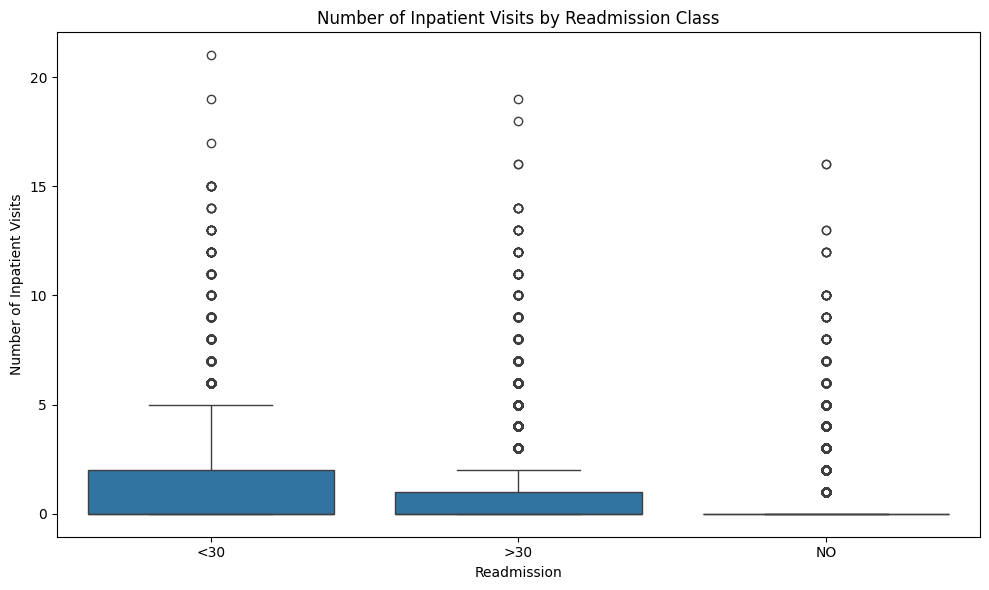

In [28]:
# Plot number_inpatient by readmission class, as it is the most important feature
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.boxplot(data=train_df, x='readmitted', y='number_inpatient', order=['<30', '>30', 'NO'])
plt.title('Number of Inpatient Visits by Readmission Class')
plt.xlabel('Readmission')
plt.ylabel('Number of Inpatient Visits')
plt.tight_layout()
plt.show()

### 2.3. Multicollinearity

In [29]:
#Drop features with correlation >= 0.95. Our one-hot encoding produces collinear features, especially if the class is binary (Male/Female)

X = train_df.drop(columns=["readmitted"])
corr_matrix = X.corr()

threshold = 0.95
to_drop = set()

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) >= threshold:
            # We drop the secnd feature in the pair
            to_drop.add(corr_matrix.columns[j])

print(f"Features to drop (|r| >= {threshold}): {len(to_drop)}")
print(f"\nFeatures being removed:")
for feat in sorted(to_drop):
    print(f"  - {feat}")

train_df_clean = train_df.drop(columns=list(to_drop))

print(f"\nOriginal features: {len(X.columns)}")
print(f"After removing multicollinear features: {len(train_df_clean.columns) - 1}")
print(f"Features removed: {len(to_drop)}")

# We update the dataseet
train_df = train_df_clean


Features to drop (|r| >= 0.95): 16

Features being removed:
  - acarbose_Steady
  - acetohexamide_Steady
  - change_No
  - chlorpropamide_Steady
  - diabetesMed_No
  - gender_Male
  - glipizide-metformin_Steady
  - glyburide-metformin_Steady
  - metformin-pioglitazone_Steady
  - metformin-rosiglitazone_Steady
  - nateglinide_Steady
  - pioglitazone_Steady
  - rosiglitazone_Steady
  - tolazamide_Steady
  - tolbutamide_Steady
  - troglitazone_Steady

Original features: 188
After removing multicollinear features: 172
Features removed: 16


### 2.4. Non-Linear Feature Engineering

In [30]:
# We do non-linear transformations on some of the best (most correlated to target) continuous features to see if they would have relevance.
# Motivation that the difference between 3rd and 4th day in a hospital is probably larger than between 13th and 14th. Similarly, the difference
# between taking 3 or 4 drugs is larger than 13 or 14. That motivates use of sqrt and log methods. Note that polynomial transformations are tried
# in later sections.

In [31]:
selected_features = ["age", 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_emergency', 'number_inpatient', 'number_diagnoses']

In [32]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd


selected_features = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 
                     'num_medications', 'number_emergency', 'number_inpatient', 'number_diagnoses']

train_df_transformed = train_df.copy()


new_features = []
for feat in selected_features:
    train_df_transformed[f'{feat}_log'] = np.log1p(train_df_transformed[feat])
    new_features.append(f'{feat}_log')
    
    train_df_transformed[f'{feat}_sqrt'] = np.sqrt(train_df_transformed[feat])
    new_features.append(f'{feat}_sqrt')

X_all = train_df_transformed.drop(columns=["readmitted", "patient_nbr"])
le = LabelEncoder()
y = le.fit_transform(train_df_transformed["readmitted"])
groups = train_df_transformed['patient_nbr']  # Group by patient_nbr
class_names = {i: label for i, label in enumerate(le.classes_)}


improvements = []

for orig_feat in selected_features:
    # Get max absolute correlation across all classes for original feature
    orig_corrs = []
    for class_label in [0, 1, 2]:
        binary_target = (y == class_label).astype(int)
        corr = train_df_transformed[orig_feat].corr(pd.Series(binary_target, index=train_df_transformed.index))
        orig_corrs.append(abs(corr))
    max_orig_corr = max(orig_corrs)
    
    # check correlation when log and sqrt are used. If it improves correlation, we try an ablation test on that
    transforms = [f'{orig_feat}_log', f'{orig_feat}_sqrt']
    for trans_feat in transforms:
        trans_corrs = []
        for class_label in [0, 1, 2]:
            binary_target = (y == class_label).astype(int)
            corr = train_df_transformed[trans_feat].corr(pd.Series(binary_target, index=train_df_transformed.index))
            trans_corrs.append(abs(corr))
        max_trans_corr = max(trans_corrs)
        
        improvement = max_trans_corr - max_orig_corr
        improvements.append({
            'original': orig_feat,
            'transformed': trans_feat,
            'original_max_corr': max_orig_corr,
            'transformed_max_corr': max_trans_corr,
            'improvement': improvement
        })

improvements_df = pd.DataFrame(improvements).sort_values('improvement', ascending=False)
beneficial_transforms = improvements_df[improvements_df['improvement'] > 0]['transformed'].tolist()


X_baseline = train_df.drop(columns=["readmitted", "patient_nbr"])
groups_baseline = train_df['patient_nbr']

features_to_add = beneficial_transforms[:10]
X_with_transforms = train_df_transformed.drop(columns=["readmitted", "patient_nbr"])[list(X_baseline.columns) + features_to_add]
groups_transforms = train_df_transformed['patient_nbr']

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        C=1.0, 
        max_iter=1000, 
        class_weight='balanced', 
        random_state=42
    ))
])

nn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('nn', MLPClassifier(
        hidden_layer_sizes=(64, 32), 
        max_iter=500, 
        random_state=42, 
        early_stopping=True
    ))
])

stratified_group_kfold = StratifiedGroupKFold(n_splits=10)

# Run a test on both versions of nns and lr (one with added columns, one without for baseline)
print("Running 10-fold STRATIFIED GROUP cross-validation...")
print(f"  - Prevents patient leakage (same patient in one fold only)")
print(f"  - Maintains class balance across folds")
print(f"Unique patients: {train_df['patient_nbr'].nunique()}")
print(f"Total visits: {len(train_df)}")

lr_baseline = cross_val_score(
    lr_pipeline, X_baseline, y, 
    groups=groups_baseline, 
    cv=stratified_group_kfold, 
    scoring='f1_macro'
)

lr_transforms = cross_val_score(
    lr_pipeline, X_with_transforms, y, 
    groups=groups_transforms, 
    cv=stratified_group_kfold, 
    scoring='f1_macro'
)

nn_baseline = cross_val_score(
    nn_pipeline, X_baseline, y, 
    groups=groups_baseline, 
    cv=stratified_group_kfold, 
    scoring='f1_macro'
)

nn_transforms = cross_val_score(
    nn_pipeline, X_with_transforms, y, 
    groups=groups_transforms, 
    cv=stratified_group_kfold, 
    scoring='f1_macro'
)

# Print comprehensive summary
print("\n" + "="*70)
print("FEATURE ENGINEERING SUMMARY: NON-LINEAR TRANSFORMATIONS")
print("="*70)

print("\n1. TRANSFORMATIONS CREATED:")
print(f"   - Selected {len(selected_features)} features for transformation")
print(f"   - Generated {len(new_features)} transformed features (log, sqrt)")
print(f"   - {len(beneficial_transforms)} showed positive correlation improvement")

print("\n2. TOP 10 TRANSFORMATIONS BY CORRELATION IMPROVEMENT:")
print(improvements_df.head(10).to_string(index=False))

print(f"\n3. FEATURES ADDED TO DATASET:")
print(f"   Baseline: {X_baseline.shape[1]} features")
print(f"   Enhanced: {X_with_transforms.shape[1]} features (+{len(features_to_add)})")
print(f"   Added features: {features_to_add}")

print("\n4. ABLATION TEST RESULTS (10-Fold Stratified Group CV, Macro F1):")
print("-" * 70)
print("LOGISTIC REGRESSION (with class_weight='balanced'):")
print(f"   Baseline:        {lr_baseline.mean():.4f} (± {lr_baseline.std():.4f})")
print(f"   With transforms: {lr_transforms.mean():.4f} (± {lr_transforms.std():.4f})")
print(f"   Improvement:     {(lr_transforms.mean() - lr_baseline.mean()):.4f} ({(lr_transforms.mean() - lr_baseline.mean())*100:+.2f}%)")

print("\nNEURAL NETWORK:")
print(f"   Baseline:        {nn_baseline.mean():.4f} (± {nn_baseline.std():.4f})")
print(f"   With transforms: {nn_transforms.mean():.4f} (± {nn_transforms.std():.4f})")
print(f"   Improvement:     {(nn_transforms.mean() - nn_baseline.mean()):.4f} ({(nn_transforms.mean() - nn_baseline.mean())*100:+.2f}%)")

print("\n" + "="*70)

Running 10-fold STRATIFIED GROUP cross-validation...
  - Prevents patient leakage (same patient in one fold only)
  - Maintains class balance across folds
Unique patients: 65932
Total visits: 91589


/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: d


FEATURE ENGINEERING SUMMARY: NON-LINEAR TRANSFORMATIONS

1. TRANSFORMATIONS CREATED:
   - Selected 7 features for transformation
   - Generated 14 transformed features (log, sqrt)
   - 10 showed positive correlation improvement

2. TOP 10 TRANSFORMATIONS BY CORRELATION IMPROVEMENT:
        original           transformed  original_max_corr  transformed_max_corr  improvement
number_emergency  number_emergency_log           0.102315              0.132426     0.030111
number_emergency number_emergency_sqrt           0.102315              0.131681     0.029366
 num_medications   num_medications_log           0.047183              0.071369     0.024185
number_inpatient  number_inpatient_log           0.216847              0.236077     0.019230
number_inpatient number_inpatient_sqrt           0.216847              0.235809     0.018962
 num_medications  num_medications_sqrt           0.047183              0.061415     0.014232
time_in_hospital  time_in_hospital_log           0.052789        

/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [33]:
beneficial_features = ['number_emergency_log', 'number_emergency_sqrt', 'num_medications_log', 
                       'number_inpatient_log', 'number_inpatient_sqrt', 'num_medications_sqrt', 
                       'time_in_hospital_log', 'time_in_hospital_sqrt', 'num_procedures_log', 
                       'num_procedures_sqrt']

# We add the beneficial features in addition to the old ones
for feat in beneficial_features:
    if '_log' in feat:
        orig_feat = feat.replace('_log', '')
        train_df[feat] = np.log1p(train_df[orig_feat])
    elif '_sqrt' in feat:
        orig_feat = feat.replace('_sqrt', '')
        train_df[feat] = np.sqrt(train_df[orig_feat])

In [34]:
train_df

,patient_nbr,age,is_weight_recorded,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,number_emergency_log,number_emergency_sqrt,num_medications_log,number_inpatient_log,number_inpatient_sqrt,num_medications_sqrt,time_in_hospital_log,time_in_hospital_sqrt,num_procedures_log,num_procedures_sqrt
0,55629189,15,0,3,59,0,18,0,0,0,...,0.0,0.0,2.944439,0.000000,0.0,4.242641,1.386294,1.732051,0.000000,0.000000
1,86047875,25,0,2,11,5,13,2,0,1,...,0.0,0.0,2.639057,0.693147,1.0,3.605551,1.098612,1.414214,1.791759,2.236068
2,82442376,35,0,2,44,1,16,0,0,0,...,0.0,0.0,2.833213,0.000000,0.0,4.000000,1.098612,1.414214,0.693147,1.000000
3,42519267,45,0,1,51,0,8,0,0,0,...,0.0,0.0,2.197225,0.000000,0.0,2.828427,0.693147,1.000000,0.000000,0.000000
4,82637451,55,0,3,31,6,16,0,0,0,...,0.0,0.0,2.833213,0.000000,0.0,4.000000,1.386294,1.732051,1.945910,2.449490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91584,100162476,75,0,3,51,0,16,0,0,0,...,0.0,0.0,2.833213,0.000000,0.0,4.000000,1.386294,1.732051,0.000000,0.000000
91585,74694222,85,0,5,33,3,18,0,0,1,...,0.0,0.0,2.944439,0.693147,1.0,4.242641,1.791759,2.236068,1.386294,1.732051
91586,41088789,75,0,1,53,0,9,1,0,0,...,0.0,0.0,2.302585,0.000000,0.0,3.000000,0.693147,1.000000,0.000000,0.000000
91587,31693671,85,0,10,45,2,21,0,0,1,...,0.0,0.0,3.091042,0.693147,1.0,4.582576,2.397895,3.162278,1.098612,1.414214


### 2.5 Looking at which features might have very clear patterns with a specific prediction class (like disposition_id_11 always means NO)

In [35]:
X = train_df.drop(columns=["readmitted", "patient_nbr"])
y_labels = train_df["readmitted"]
le = LabelEncoder()
y = le.fit_transform(y_labels)
class_names = {i: label for i, label in enumerate(le.classes_)}

print("="*70)
print("FINDING 100% DETERMINISTIC PATTERNS ONLY")
print("="*70)

deterministic_patterns = []

for col in X.columns:
    if X[col].dtype in ['int64', 'float64']:
        unique_vals = X[col].unique()
        
        for val in unique_vals:
            mask = (X[col] == val)
            if mask.sum() >= 5:  # At least 10 instances of "specific feature, specific result pair"
                classes_for_val = y_labels[mask].unique()
                
                if len(classes_for_val) == 1:
                    count = mask.sum()
                    deterministic_patterns.append({
                        'feature': col,
                        'value': val,
                        'always_predicts': classes_for_val[0],
                        'count': count,
                        'percentage_of_dataset': count / len(X) * 100
                    })

print(f"\nFound {len(deterministic_patterns)} 100% deterministic patterns:\n")

if deterministic_patterns:
    det_df = pd.DataFrame(deterministic_patterns).sort_values('count', ascending=False)
    print(det_df.to_string(index=False))
    
    print("\n" + "="*70)
    print("SUMMARY")
    print("="*70)
    print(f"Total patterns where feature=value → ALWAYS same class: {len(deterministic_patterns)}")
    print("\nThese are candidates for rule-based overrides if clinically justified.")
else:
    print("No 100% deterministic patterns found.")

FINDING 100% DETERMINISTIC PATTERNS ONLY

Found 6 100% deterministic patterns:

                    feature     value always_predicts  count  percentage_of_dataset
discharge_disposition_id_11  1.000000              NO   1475               1.610455
        admission_type_id_7  1.000000              NO     18               0.019653
           number_inpatient 15.000000             <30      9               0.009827
       number_inpatient_log  2.772589             <30      9               0.009827
      number_inpatient_sqrt  3.872983             <30      9               0.009827
discharge_disposition_id_19  1.000000              NO      7               0.007643

SUMMARY
Total patterns where feature=value → ALWAYS same class: 6

These are candidates for rule-based overrides if clinically justified.


### We know that discharge_disposition_id_11, 19, 20, 21 always corresponds to NO as the patient dies (IDS_mapping). Admission_type_id_7 only has 18 values and means trauma center. 18 samples are not enough to convince us that this certainly means the patient will not return, as they might still have the means to (as opposed to if they are deceased)

In [36]:
def apply_rules(y_pred_probs, X_subset, classes):
    """
    Rule:
    - If patient expired (discharge_disposition_id in {11,19,20,21}),

    X_subset: the feature DataFrame for the same rows as y_pred_probs
              (used to read one-hot discharge columns).
    classes: model.classes_ (order of columns in predict_proba)
    """
    y_pred_probs_adjusted = y_pred_probs.copy()

    # expired one-hot columns (safe if some are missing)
    EXPIRED_OHE_COLS = [
        "discharge_disposition_id_11",
        "discharge_disposition_id_19",
        "discharge_disposition_id_20",
        "discharge_disposition_id_21", 
    ]
    is_expired = (
        X_subset.reindex(columns=EXPIRED_OHE_COLS, fill_value=0)
                .sum(axis=1)
                .to_numpy()
                .astype(bool)
    )

    # find which column corresponds to label "NO"
    classes = np.array(classes)
    no_idx = np.where(classes == "NO")[0][0]

    # force NO prob = 1.0 for expired rows
    y_pred_probs_adjusted[is_expired] = 0.0
    y_pred_probs_adjusted[is_expired, no_idx] = 1.0

    return y_pred_probs_adjusted


def apply_rules_labels(y_pred, X_subset):
    """
    Same rule as apply_rules, but works on predicted labels.
    """
    y_pred = np.array(y_pred, dtype=object).copy()

    EXPIRED_OHE_COLS = [
        "discharge_disposition_id_11",
        "discharge_disposition_id_19",
        "discharge_disposition_id_20",
        "discharge_disposition_id_21",
    ]
    is_expired = (
        X_subset.reindex(columns=EXPIRED_OHE_COLS, fill_value=0)
                .sum(axis=1)
                .to_numpy()
                .astype(bool)
    )
    y_pred[is_expired] = "NO"
    return y_pred

In [37]:
from sklearn.base import clone
from sklearn.metrics import f1_score, balanced_accuracy_score
from sklearn.model_selection import StratifiedGroupKFold


def cross_validate_with_rules(model, X, y_str, groups, scoring, return_train_score=False, n_splits=10, random_state=42):
    """
    Like cross_validate, but applies apply_rules(...) on predict_proba outputs.
    Uses StratifiedGroupKFold to ensure same patient doesn't appear in train and test.
    Works with both regular models and Pipeline objects.
    
    Parameters:
    -----------
    model : estimator or Pipeline
        The model/pipeline to train
    X : DataFrame
        Features (should NOT contain patient_nbr or target column)
    y_str : Series
        Target variable ('readmitted' column)
    groups : array-like
        Patient identifiers (patient_nbr) for grouping
    scoring : dict
        Dictionary of scoring metrics
    return_train_score : bool, default=False
        Whether to compute training scores
    n_splits : int, default=10
        Number of folds for StratifiedGroupKFold
    random_state : int, default=42
        Random state for reproducibility
    """
    # Create StratifiedGroupKFold with 10 folds
    cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    
    results = {f"test_{k}": [] for k in scoring.keys()}
    if return_train_score:
        results.update({f"train_{k}": [] for k in scoring.keys()})

    for train_idx, test_idx in cv.split(X, y_str, groups=groups):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y_str.iloc[train_idx], y_str.iloc[test_idx]

        m = clone(model)
        m.fit(X_train, y_train)

        # ---- TEST ----
        if hasattr(m, "predict_proba"):
            y_pred_probs_test = m.predict_proba(X_test)
            y_pred_probs_test_adj = apply_rules(y_pred_probs_test, X_test, m.classes_)
            y_pred_test = m.classes_[np.argmax(y_pred_probs_test_adj, axis=1)]
        else:
            y_pred_test = m.predict(X_test)
            y_pred_test = apply_rules_labels(y_pred_test, X_test)

        # compute test metrics
        for name, scorer in scoring.items():
            if scorer == "accuracy":
                results[f"test_{name}"].append((y_pred_test == y_test.to_numpy()).mean())
            else:
                if name == "balanced_accuracy":
                    results[f"test_{name}"].append(balanced_accuracy_score(y_test, y_pred_test))
                elif name == "f1_macro":
                    results[f"test_{name}"].append(f1_score(y_test, y_pred_test, average="macro"))
                elif name == "f1_weighted":
                    results[f"test_{name}"].append(f1_score(y_test, y_pred_test, average="weighted"))
                else:
                    raise ValueError(f"Unsupported scoring key: {name}")
        
        if return_train_score:
            if hasattr(m, "predict_proba"):
                y_pred_probs_train = m.predict_proba(X_train)
                y_pred_probs_train_adj = apply_rules(y_pred_probs_train, X_train, m.classes_)
                y_pred_train = m.classes_[np.argmax(y_pred_probs_train_adj, axis=1)]
            else:
                y_pred_train = m.predict(X_train)
                y_pred_train = apply_rules_labels(y_pred_train, X_train)

            for name, scorer in scoring.items():
                if scorer == "accuracy":
                    results[f"train_{name}"].append((y_pred_train == y_train.to_numpy()).mean())
                else:
                    if name == "balanced_accuracy":
                        results[f"train_{name}"].append(balanced_accuracy_score(y_train, y_pred_train))
                    elif name == "f1_macro":
                        results[f"train_{name}"].append(f1_score(y_train, y_pred_train, average="macro"))
                    elif name == "f1_weighted":
                        results[f"train_{name}"].append(f1_score(y_train, y_pred_train, average="weighted"))
                    else:
                        raise ValueError(f"Unsupported scoring key: {name}")

    # convert to numpy arrays
    for k in list(results.keys()):
        results[k] = np.array(results[k], dtype=float)

    return results

### 2.6. Final Feature Selection

In [38]:
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

X = train_df.drop(columns=["readmitted", "patient_nbr"])
y = LabelEncoder().fit_transform(train_df["readmitted"])

print("="*70)
print("ZERO-VARIANCE FEATURES")
print("="*70)
print(f"\nTotal features: {X.shape[1]}")

var_selector = VarianceThreshold(threshold=0)
var_selector.fit(X)

zero_variance_features = X.columns[~var_selector.get_support()]

print(f"\nZero-variance features found: {len(zero_variance_features)}")
print("\nFeatures to remove:")
for feat in zero_variance_features:
    print(f"  - {feat}")

ZERO-VARIANCE FEATURES

Total features: 181

Zero-variance features found: 3

Features to remove:
  - examide_No
  - citoglipton_No
  - glimepiride-pioglitazone_No


In [39]:
final_clean_train_df = train_df.drop(columns=zero_variance_features)

In [40]:
final_clean_train_df

,patient_nbr,age,is_weight_recorded,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,number_emergency_log,number_emergency_sqrt,num_medications_log,number_inpatient_log,number_inpatient_sqrt,num_medications_sqrt,time_in_hospital_log,time_in_hospital_sqrt,num_procedures_log,num_procedures_sqrt
0,55629189,15,0,3,59,0,18,0,0,0,...,0.0,0.0,2.944439,0.000000,0.0,4.242641,1.386294,1.732051,0.000000,0.000000
1,86047875,25,0,2,11,5,13,2,0,1,...,0.0,0.0,2.639057,0.693147,1.0,3.605551,1.098612,1.414214,1.791759,2.236068
2,82442376,35,0,2,44,1,16,0,0,0,...,0.0,0.0,2.833213,0.000000,0.0,4.000000,1.098612,1.414214,0.693147,1.000000
3,42519267,45,0,1,51,0,8,0,0,0,...,0.0,0.0,2.197225,0.000000,0.0,2.828427,0.693147,1.000000,0.000000,0.000000
4,82637451,55,0,3,31,6,16,0,0,0,...,0.0,0.0,2.833213,0.000000,0.0,4.000000,1.386294,1.732051,1.945910,2.449490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91584,100162476,75,0,3,51,0,16,0,0,0,...,0.0,0.0,2.833213,0.000000,0.0,4.000000,1.386294,1.732051,0.000000,0.000000
91585,74694222,85,0,5,33,3,18,0,0,1,...,0.0,0.0,2.944439,0.693147,1.0,4.242641,1.791759,2.236068,1.386294,1.732051
91586,41088789,75,0,1,53,0,9,1,0,0,...,0.0,0.0,2.302585,0.000000,0.0,3.000000,0.693147,1.000000,0.000000,0.000000
91587,31693671,85,0,10,45,2,21,0,0,1,...,0.0,0.0,3.091042,0.693147,1.0,4.582576,2.397895,3.162278,1.098612,1.414214


In [41]:
final_clean_train_df.to_csv("final_clean_train_df.csv", index=False)

## 2.7. Resampling


### A test whether simple resampling to 70% of the majority class improves performace. We expect a higher likelihood of overfitting but potential improvements, especially in neural nets. Same as for abaltion tests, we do this on initial, non-tuned models.

In [39]:
final_clean_train_df = pd.read_csv("final_clean_train_df.csv")

In [40]:
final_clean_train_df

,patient_nbr,age,is_weight_recorded,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,number_emergency_log,number_emergency_sqrt,num_medications_log,number_inpatient_log,number_inpatient_sqrt,num_medications_sqrt,time_in_hospital_log,time_in_hospital_sqrt,num_procedures_log,num_procedures_sqrt
0,55629189,15,0,3,59,0,18,0,0,0,...,0.0,0.0,2.944439,0.000000,0.0,4.242641,1.386294,1.732051,0.000000,0.000000
1,86047875,25,0,2,11,5,13,2,0,1,...,0.0,0.0,2.639057,0.693147,1.0,3.605551,1.098612,1.414214,1.791759,2.236068
2,82442376,35,0,2,44,1,16,0,0,0,...,0.0,0.0,2.833213,0.000000,0.0,4.000000,1.098612,1.414214,0.693147,1.000000
3,42519267,45,0,1,51,0,8,0,0,0,...,0.0,0.0,2.197225,0.000000,0.0,2.828427,0.693147,1.000000,0.000000,0.000000
4,82637451,55,0,3,31,6,16,0,0,0,...,0.0,0.0,2.833213,0.000000,0.0,4.000000,1.386294,1.732051,1.945910,2.449490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91584,100162476,75,0,3,51,0,16,0,0,0,...,0.0,0.0,2.833213,0.000000,0.0,4.000000,1.386294,1.732051,0.000000,0.000000
91585,74694222,85,0,5,33,3,18,0,0,1,...,0.0,0.0,2.944439,0.693147,1.0,4.242641,1.791759,2.236068,1.386294,1.732051
91586,41088789,75,0,1,53,0,9,1,0,0,...,0.0,0.0,2.302585,0.000000,0.0,3.000000,0.693147,1.000000,0.000000,0.000000
91587,31693671,85,0,10,45,2,21,0,0,1,...,0.0,0.0,3.091042,0.693147,1.0,4.582576,2.397895,3.162278,1.098612,1.414214


CLASS DISTRIBUTION
  <30  :  10245 (11.19%)
  >30  :  31989 (34.93%)
  NO   :  49355 (53.89%)

RUNNING EXPERIMENTS...

Logistic Regression:
  Testing none... Done (F1: 0.4471)
  Testing 70... Done (F1: 0.4449)

Neural Network:
  Testing none... Done (F1: 0.4075)
  Testing 70... Done (F1: 0.4110)

CONFUSION MATRICES

Saved confusion matrices to 'resampling_confusion_matrices_expanded.png'

PER-CLASS METRICS COMPARISON

Logistic Regression:
----------------------------------------------------------------------

  Class: <30
Strategy  Precision   Recall  F1-Score
    none   0.202778 0.408980  0.271127
      70   0.200019 0.407028  0.268228

  Class: >30
Strategy  Precision   Recall  F1-Score
    none   0.468505 0.398981  0.430957
      70   0.466101 0.399950  0.430499

  Class: NO
Strategy  Precision   Recall  F1-Score
    none   0.680707 0.602492  0.639216
      70   0.680472 0.596880  0.635941

Neural Network:
----------------------------------------------------------------------

  Cla

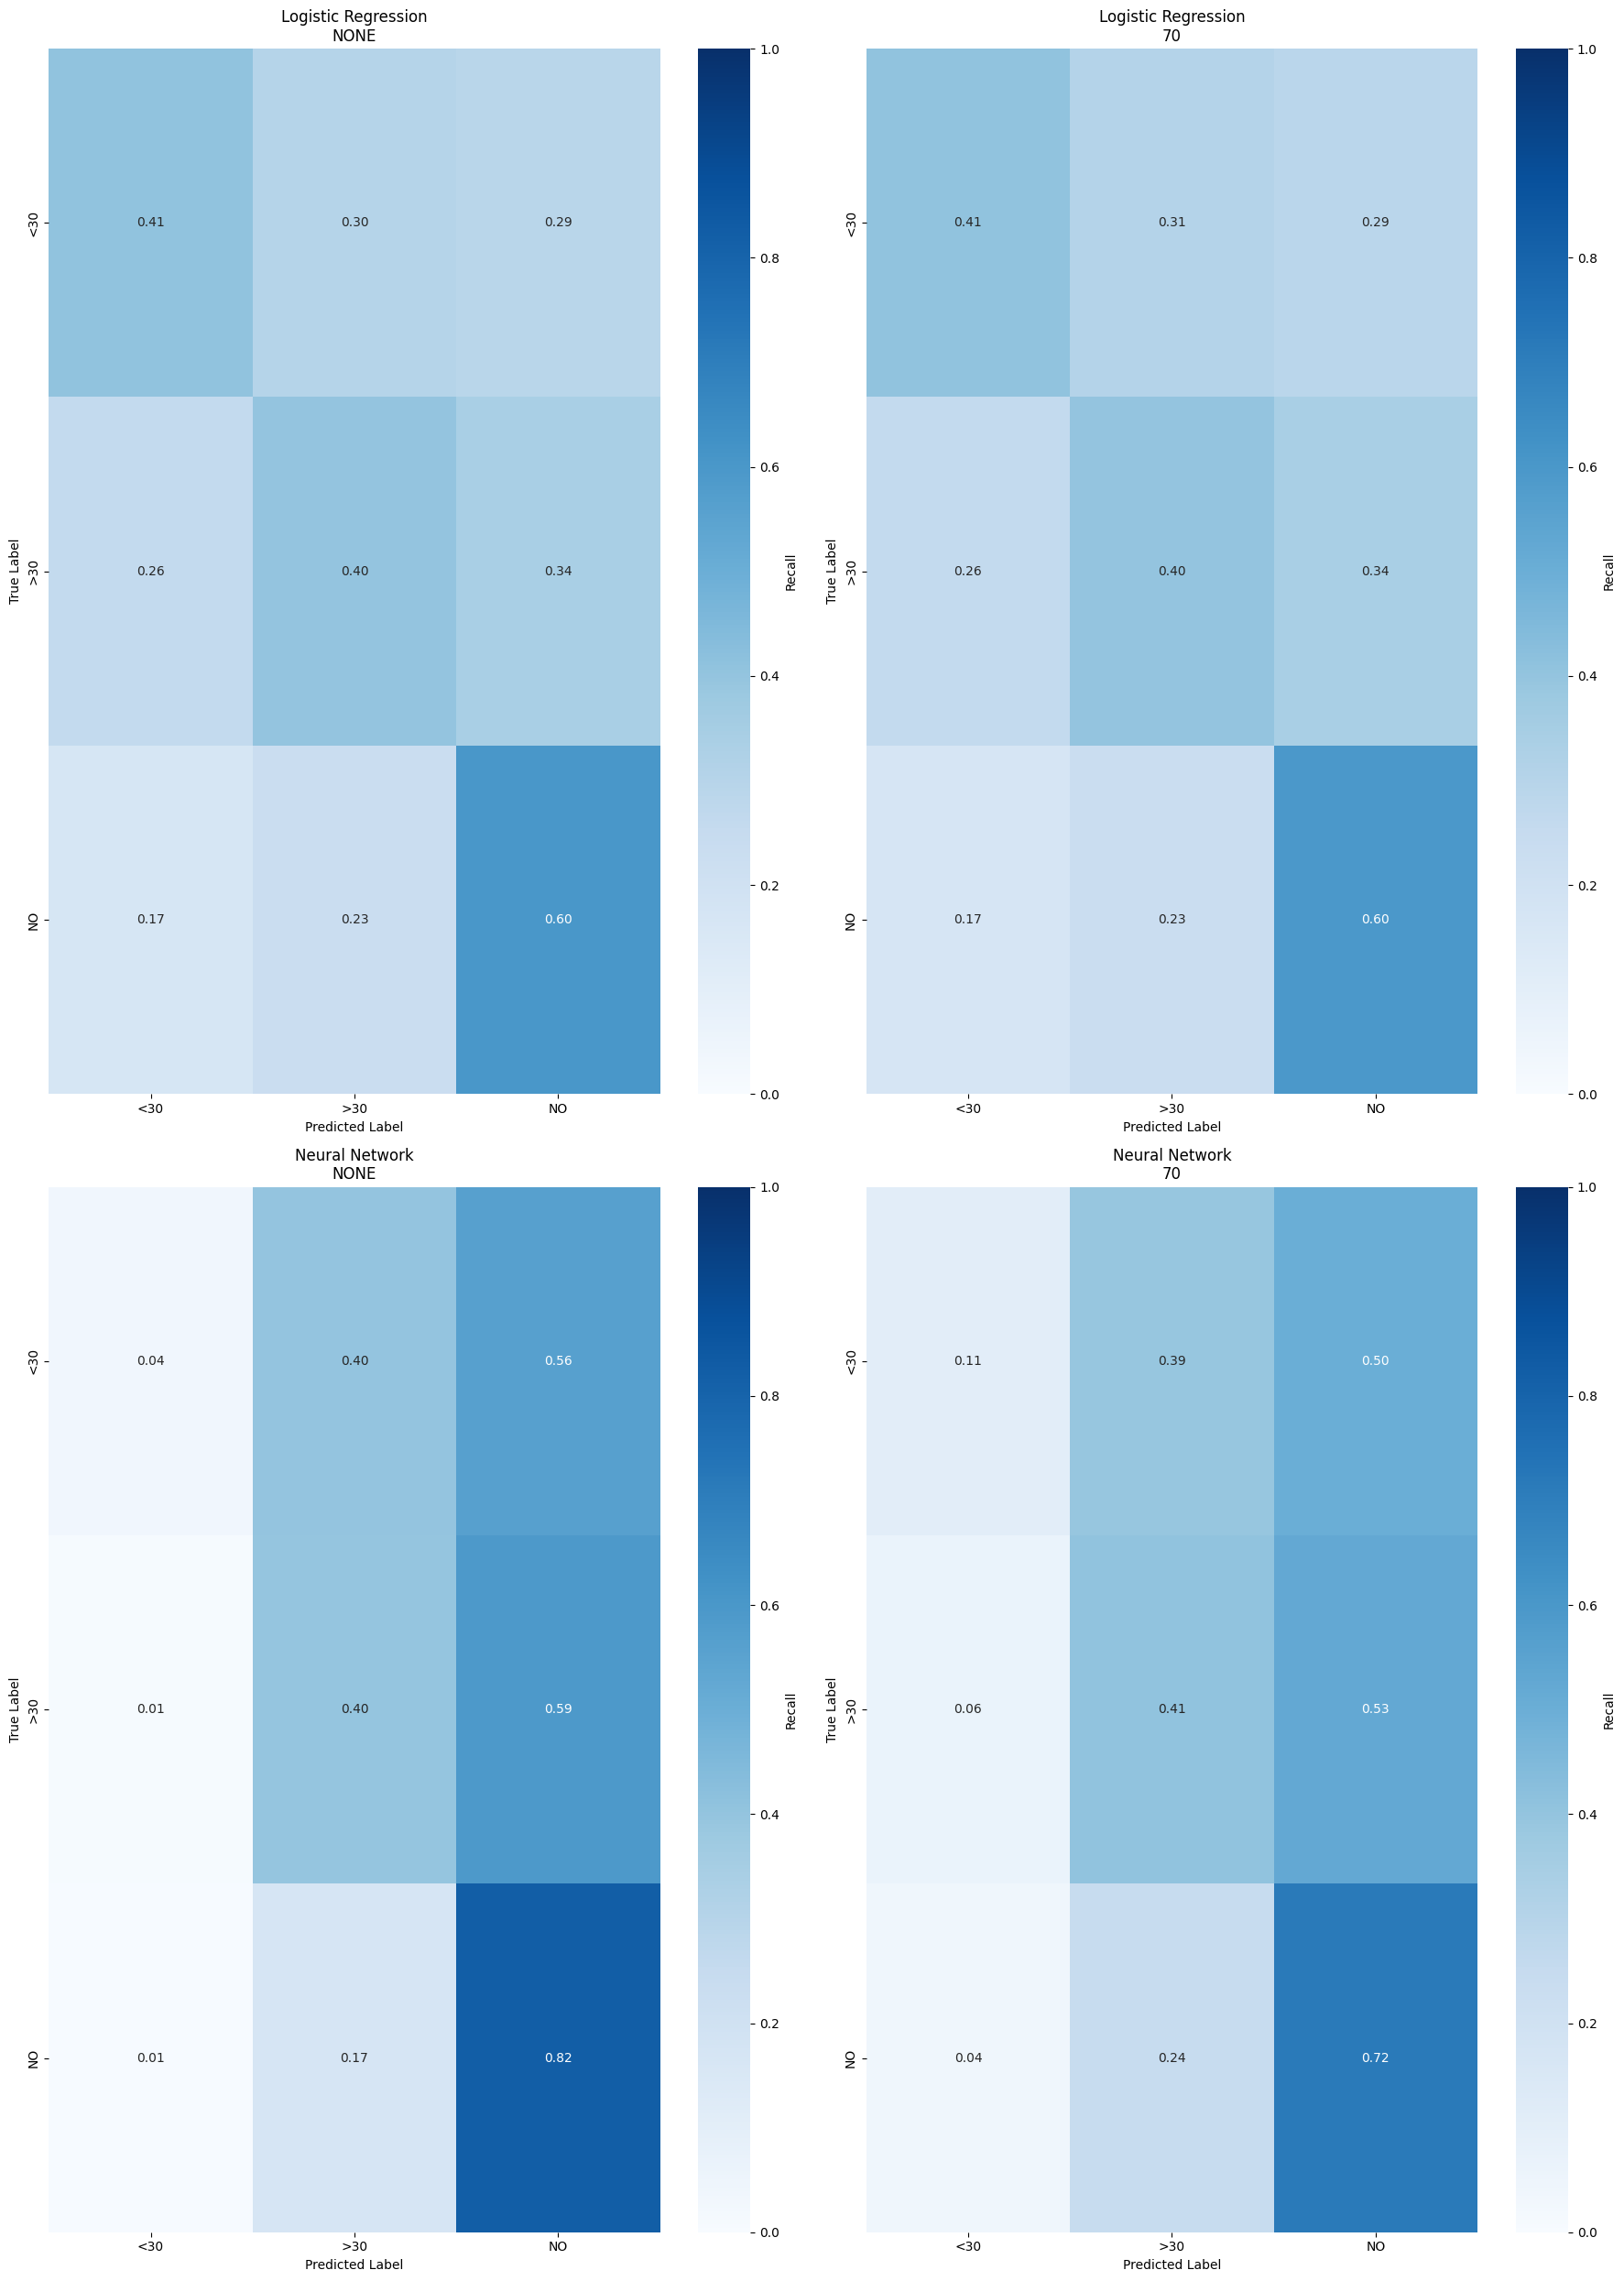

In [42]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC, SVC
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils import resample
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Prepare data
X = final_clean_train_df.drop(columns=["readmitted", "patient_nbr"])
y = LabelEncoder().fit_transform(final_clean_train_df["readmitted"])
groups = final_clean_train_df['patient_nbr']

le = LabelEncoder().fit(final_clean_train_df["readmitted"])
class_names = {i: label for i, label in enumerate(le.classes_)}

print("="*70)
print("CLASS DISTRIBUTION")
print("="*70)
for i, name in class_names.items():
    count = (y == i).sum()
    pct = count / len(y) * 100
    print(f"  {name:5s}: {count:6d} ({pct:5.2f}%)")

# Function to cross-validate and collect confusion matrices
def cross_val_with_metrics(model, X, y, groups, resampling_strategy='none', n_splits=10):
    skf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)
    all_y_true = []
    all_y_pred = []
    
    for train_idx, val_idx in skf.split(X, y, groups):
        X_train_fold = X.iloc[train_idx].copy()
        y_train_fold = y[train_idx].copy()
        X_val_fold = X.iloc[val_idx]
        y_val_fold = y[val_idx]
        
        # Apply resampling
        if resampling_strategy != 'none':
            train_data = X_train_fold.copy()
            train_data['target'] = y_train_fold
            
            class_0 = train_data[train_data['target'] == 0]
            class_1 = train_data[train_data['target'] == 1]
            class_2 = train_data[train_data['target'] == 2]
            
            max_size = max(len(class_0), len(class_1), len(class_2))
            
            target_size = int(max_size * 0.7)
            
            class_0_resampled = resample(class_0, n_samples=min(target_size, len(class_0)) if len(class_0) < max_size else len(class_0), 
                                         random_state=42, replace=True)
            class_1_resampled = resample(class_1, n_samples=min(target_size, len(class_1)) if len(class_1) < max_size else len(class_1), 
                                         random_state=42, replace=True)
            class_2_resampled = resample(class_2, n_samples=min(target_size, len(class_2)) if len(class_2) < max_size else len(class_2), 
                                         random_state=42, replace=True)
            
            train_resampled = pd.concat([class_0_resampled, class_1_resampled, class_2_resampled])
            X_train_fold = train_resampled.drop(columns=['target'])
            y_train_fold = train_resampled['target'].values
        
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_fold)
        X_val_scaled = scaler.transform(X_val_fold)
        
        model_clone = model.__class__(**model.get_params())
        model_clone.fit(X_train_scaled, y_train_fold)
        y_pred = model_clone.predict(X_val_scaled)
        
        all_y_true.extend(y_val_fold)
        all_y_pred.extend(y_pred)
    
    return np.array(all_y_true), np.array(all_y_pred)

models = [
    ('Logistic Regression', LogisticRegression(C=1.0, max_iter=1000,class_weight="balanced", random_state=42)),
    
    ('Neural Network', MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42, early_stopping=True))
]

strategies = ['none', '70']

print("\n" + "="*70)
print("RUNNING EXPERIMENTS...")
print("="*70)

# Store results
all_results = {}

for model_name, model in models:
    print(f"\n{model_name}:")
    all_results[model_name] = {}
    
    for strategy in strategies:
        print(f"  Testing {strategy}...", end=" ")
        y_true, y_pred = cross_val_with_metrics(model, X, y, groups, strategy)
        
        cm = confusion_matrix(y_true, y_pred)
        report = classification_report(y_true, y_pred, target_names=[class_names[i] for i in range(3)], 
                                       output_dict=True, zero_division=0)
        macro_f1 = f1_score(y_true, y_pred, average='macro')
        
        all_results[model_name][strategy] = {
            'cm': cm,
            'report': report,
            'macro_f1': macro_f1
        }
        print(f"Done (F1: {macro_f1:.4f})")

# Visualize confusion matrices
print("\n" + "="*70)
print("CONFUSION MATRICES")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(18, 25))

for model_idx, (model_name, _) in enumerate(models):
    for strat_idx, strategy in enumerate(strategies):
        ax = axes[model_idx, strat_idx]
        cm = all_results[model_name][strategy]['cm']
        
        # Normalize by true labels (row-wise) to get recall
        cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
        sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=ax,
                   xticklabels=[class_names[i] for i in range(3)],
                   yticklabels=[class_names[i] for i in range(3)],
                   vmin=0, vmax=1, cbar_kws={'label': 'Recall'})
        
        ax.set_title(f'{model_name}\n{strategy.upper()}')
        ax.set_ylabel('True Label')
        ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('resampling_confusion_matrices_expanded.png', dpi=300, bbox_inches='tight')
print("\nSaved confusion matrices to 'resampling_confusion_matrices_expanded.png'")

# Print detailed per-class metrics
print("\n" + "="*70)
print("PER-CLASS METRICS COMPARISON")
print("="*70)

for model_name, _ in models:
    print(f"\n{model_name}:")
    print("-" * 70)
    
    # Create comparison table
    comparison = []
    for strategy in strategies:
        report = all_results[model_name][strategy]['report']
        for class_idx in range(3):
            class_label = class_names[class_idx]
            comparison.append({
                'Strategy': strategy,
                'Class': class_label,
                'Precision': report[class_label]['precision'],
                'Recall': report[class_label]['recall'],
                'F1-Score': report[class_label]['f1-score'],
                'Support': int(report[class_label]['support'])
            })
    
    comp_df = pd.DataFrame(comparison)
    
    # Show side-by-side for each class
    for class_label in ['<30', '>30', 'NO']:
        print(f"\n  Class: {class_label}")
        class_data = comp_df[comp_df['Class'] == class_label][['Strategy', 'Precision', 'Recall', 'F1-Score']]
        print(class_data.to_string(index=False))


# 3. Logistic Regression

In [4]:
import pandas as pd

In [43]:
df = pd.read_csv("final_clean_train_df.csv")

### Experiment 1  - Logistic with Scaling and L2
### Experiment 2  - Remove low variance features (in pipeline)
### Experiment 3 - PCA


### Note: To run a specific experiment, the correct lines in the Pipeline have to be commented out

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


y = df['readmitted']
patient_groups = df['patient_nbr']
X = df.drop(columns=['readmitted', 'patient_nbr'])

# Create Logistic Regression model
model = Pipeline(steps=[           # pipeline chains preprocessing + model into one object.
    # ("low_var", VarianceThreshold(0.01)) # to remove low-variance features  - CAN BE COMMENTED OUT FOR EXPERIMENT 1
    ("scaler", StandardScaler()),  # step 1: standardises each feature to mean 0, std 1.
    #("pca", PCA(n_components=0.95)),
    ("clf", LogisticRegression(    # step 2: train logistic regression (the classifier) on the scaled data
            solver="lbfgs",              # optimisation method (default) to find best coefficients for multinomial + L2 regularisation
            max_iter=500,                # enough iterations for convergence in a high-dimensional dataset
            class_weight="balanced",     # increases the penalty for misclassifying minority classes (reweights classes inversely proportional to their frequency)
            n_jobs=None                  # lbfgs ignores n_jobs; OK to leave
            )
    )
])

scoring = {
    'accuracy': 'accuracy',
    'balanced_accuracy': 'balanced_accuracy',
    'f1_macro': 'f1_macro',
    'f1_weighted': 'f1_weighted'
}

# Run cross-validation with our rules for filtering out dead patients
print("Running 10-Fold Stratified Group Cross-Validation with Rules...")
results = cross_validate_with_rules(
    model=model,
    X=X,
    y_str=y,
    groups=patient_groups,
    scoring=scoring,
    return_train_score=True,
    n_splits=10,
    random_state=42
)

# Display results
print("\n" + "="*60)
print("LOGISTIC REGRESSION - CROSS-VALIDATION RESULTS")
print("="*60)

for metric in scoring.keys():
    test_scores = results[f'test_{metric}']
    train_scores = results[f'train_{metric}']
    
    print(f"\n{metric.upper().replace('_', ' ')}:")
    print(f"  Test:  {test_scores.mean():.4f} ± {test_scores.std():.4f}")
    print(f"  Train: {train_scores.mean():.4f} ± {train_scores.std():.4f}")
    print(f"  Fold scores (test): {test_scores}")

print("\n" + "="*60)



# Confusion Matrix
cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)
all_y_true = []
all_y_pred = []

for train_idx, test_idx in cv.split(X, y, groups=patient_groups):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    m = clone(model)
    m.fit(X_train, y_train)
    
    y_pred_probs = m.predict_proba(X_test)
    y_pred_probs_adj = apply_rules(y_pred_probs, X_test, m.classes_)
    y_pred = m.classes_[np.argmax(y_pred_probs_adj, axis=1)]
    
    all_y_true.extend(y_test.to_numpy())
    all_y_pred.extend(y_pred)

print("\nConfusion Matrix:")
print(confusion_matrix(np.array(all_y_true), np.array(all_y_pred)))
print("\nClassification Report:")
print(classification_report(np.array(all_y_true), np.array(all_y_pred)))

Running 10-Fold Stratified Group Cross-Validation with Rules...


/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: d


LOGISTIC REGRESSION - CROSS-VALIDATION RESULTS

ACCURACY:
  Test:  0.5098 ± 0.0038
  Train: 0.5129 ± 0.0008
  Fold scores (test): [0.50630385 0.50871905 0.50499946 0.5104178  0.51684665 0.51698197
 0.5091922  0.50731762 0.50864745 0.50838112]

BALANCED ACCURACY:
  Test:  0.4701 ± 0.0047
  Train: 0.4746 ± 0.0004
  Fold scores (test): [0.47180497 0.4678239  0.47105315 0.47889503 0.47543963 0.47376812
 0.46334038 0.46562133 0.46558176 0.46775821]

F1 MACRO:
  Test:  0.4470 ± 0.0038
  Train: 0.4508 ± 0.0005
  Fold scores (test): [0.44684581 0.44516323 0.44691718 0.44995163 0.4540852  0.45202655
 0.44208291 0.44222186 0.44418727 0.44683746]

F1 WEIGHTED:
  Test:  0.5253 ± 0.0037
  Train: 0.5283 ± 0.0006
  Fold scores (test): [0.52207039 0.52572297 0.52075411 0.52614369 0.53240851 0.53103091
 0.52561874 0.52134729 0.52399133 0.5238484 ]



/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: d


Confusion Matrix:
[[ 4190  3085  2970]
 [ 8248 12763 10978]
 [ 8225 11394 29736]]

Classification Report:
              precision    recall  f1-score   support

         <30       0.20      0.41      0.27     10245
         >30       0.47      0.40      0.43     31989
          NO       0.68      0.60      0.64     49355

    accuracy                           0.51     91589
   macro avg       0.45      0.47      0.45     91589
weighted avg       0.55      0.51      0.53     91589



/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


# 3. Logistic Regression with Polynomial Features

In [ ]:
df = pd.read_csv("final_clean_train_df.csv")

In [ ]:
# Same code as for logistic, just with an additional preprocessor step to add polynomial features. We will try degree 2 and degree 3 on all 
# continuous features. Larger degrees lead to feature explosion.

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import VarianceThreshold

y = df['readmitted']
patient_groups = df['patient_nbr']
X = df.drop(columns=['readmitted', 'patient_nbr'])

var_threshold = VarianceThreshold(threshold=0.01)
X_high_var = var_threshold.fit_transform(X)

high_var_columns = X.columns[var_threshold.get_support()].tolist()
X_filtered = X[high_var_columns] 

### Testing Which Features are not one-hot encoded
unique_counts = X_filtered.nunique()
not_one_hot = unique_counts[unique_counts >= 3]
not_one_hot_columns = not_one_hot.index.tolist()
one_hot_columns = [col for col in X_filtered.columns if col not in not_one_hot_columns]

print(f"Total features: {len(X_filtered.columns)}")
print(f"Non-one-hot features: {len(not_one_hot_columns)}")
print(f"One-hot features: {len(one_hot_columns)}")

# Create preprocessing that fits certain degree polynomials
preprocessor = ColumnTransformer(
    transformers=[
        ('poly', PolynomialFeatures(degree=3, include_bias=False), not_one_hot_columns),  
        ('passthrough', 'passthrough', one_hot_columns)
    ],
    remainder='drop'
)


model = Pipeline(steps=[
    ("poly_features", preprocessor),
    ("scaler", StandardScaler()),
    #("pca", PCA(n_components=0.95)),
    ("clf", LogisticRegression(
            solver="lbfgs",
            max_iter=500,
            class_weight="balanced",
            n_jobs=None
            )
    )
])


scoring = {
    'accuracy': 'accuracy',
    'balanced_accuracy': 'balanced_accuracy',
    'f1_macro': 'f1_macro',
    'f1_weighted': 'f1_weighted'
}

# Run cross-validation with rour deceased patient rules
print("Running 10-Fold Stratified Group Cross-Validation with Polynomial Features...")
results = cross_validate_with_rules(
    model=model,
    X=X_filtered,  
    y_str=y,
    groups=patient_groups,
    scoring=scoring,
    return_train_score=True,
    n_splits=10,
    random_state=42
)

# Display results
print("\n" + "="*60)
print("LOGISTIC REGRESSION WITH POLYNOMIAL FEATURES - CROSS-VALIDATION RESULTS")
print("="*60)

for metric in scoring.keys():
    test_scores = results[f'test_{metric}']
    train_scores = results[f'train_{metric}']
    
    print(f"\n{metric.upper().replace('_', ' ')}:")
    print(f"  Test:  {test_scores.mean():.4f} ± {test_scores.std():.4f}")
    print(f"  Train: {train_scores.mean():.4f} ± {train_scores.std():.4f}")
    print(f"  Fold scores (test): {test_scores}")

print("\n" + "="*60)

# Confusion Matrix
cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)
all_y_true = []
all_y_pred = []

for train_idx, test_idx in cv.split(X_filtered, y, groups=patient_groups):  
    X_train, X_test = X_filtered.iloc[train_idx], X_filtered.iloc[test_idx]  
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    m = clone(model)
    m.fit(X_train, y_train)
    
    y_pred_probs = m.predict_proba(X_test)
    y_pred_probs_adj = apply_rules(y_pred_probs, X_test, m.classes_)
    y_pred = m.classes_[np.argmax(y_pred_probs_adj, axis=1)]
    
    all_y_true.extend(y_test.to_numpy())
    all_y_pred.extend(y_pred)

print("\nConfusion Matrix:")
print(confusion_matrix(np.array(all_y_true), np.array(all_y_pred)))
print("\nClassification Report:")
print(classification_report(np.array(all_y_true), np.array(all_y_pred)))

Total features: 108
Non-one-hot features: 21
One-hot features: 87
Running 10-Fold Stratified Group Cross-Validation with Polynomial Features...


/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: d


LOGISTIC REGRESSION WITH POLYNOMIAL FEATURES - CROSS-VALIDATION RESULTS

ACCURACY:
  Test:  0.5010 ± 0.0031
  Train: 0.5142 ± 0.0008
  Fold scores (test): [0.4959025  0.50721206 0.49973121 0.50070907 0.50345572 0.50359553
 0.4978273  0.50061446 0.50232816 0.49878694]

BALANCED ACCURACY:
  Test:  0.4656 ± 0.0042
  Train: 0.4875 ± 0.0007
  Fold scores (test): [0.46579684 0.47227258 0.46622146 0.47296808 0.46111574 0.46163859
 0.46041657 0.46394294 0.46815187 0.46304176]

F1 MACRO:
  Test:  0.4415 ± 0.0026
  Train: 0.4584 ± 0.0007
  Fold scores (test): [0.43974813 0.44674454 0.44270897 0.44317241 0.44187752 0.44035493
 0.43657951 0.43955549 0.44328334 0.44081199]

F1 WEIGHTED:
  Test:  0.5203 ± 0.0030
  Train: 0.5325 ± 0.0007
  Fold scores (test): [0.51638335 0.52739437 0.5187352  0.51895752 0.52287339 0.5221106
 0.51925021 0.51921708 0.52089117 0.51712761]



/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: d


Confusion Matrix:
[[ 4183  3252  2810]
 [ 8695 13034 10260]
 [ 9080 11605 28670]]

Classification Report:
              precision    recall  f1-score   support

         <30       0.19      0.41      0.26     10245
         >30       0.47      0.41      0.44     31989
          NO       0.69      0.58      0.63     49355

    accuracy                           0.50     91589
   macro avg       0.45      0.47      0.44     91589
weighted avg       0.55      0.50      0.52     91589



# Kernel Methods

In [ ]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC, LinearSVC
from sklearn.kernel_approximation import Nystroem
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.base import clone

# Load clean data
df = pd.read_csv("final_clean_train_df.csv")

y = df["readmitted"]
patient_groups = df["patient_nbr"]
X = df.drop(columns=["readmitted", "patient_nbr"])

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted",
}

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

PCA_KEEP = 0.8  # keep 80% variance

svm_variants = [
    ("SVM_Linear_PCA", Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=20, random_state=42)),
        ("clf", LinearSVC(class_weight="balanced", max_iter=5000))
    ])),
    ("SVM_RBF_Approx", Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=20, random_state=42)),   # increase a bit; 20 is very tight
        ("rbf_feat", Nystroem(kernel="rbf", gamma=0.05, n_components=500, random_state=42)),
        ("clf", LinearSVC(class_weight="balanced", C=1.0, max_iter=10000))
    ])),
]

for name, model in svm_variants:
    print("\n" + "="*70)
    print(f"{name} - 5-Fold Stratified Group CV with Rules")
    print("="*70)

    results = cross_validate_with_rules(
        model=model,
        X=X,
        y_str=y,
        groups=patient_groups,
        scoring=scoring,
        return_train_score=True,
        n_splits=5,
        random_state=42
    )

    log_result(
        model_name=name,
        params=model.get_params(),
        mean_score=float(results["test_f1_macro"].mean()),
        std_score=float(results["test_f1_macro"].std()),
        notes=f"5-fold StratifiedGroupKFold + apply_rules; scaler -> PCA({PCA_KEEP}) -> SVC(probability=True)"
    )

    for metric in scoring.keys():
        test_scores = results[f"test_{metric}"]
        train_scores = results[f"train_{metric}"]
        print(f"\n{metric.upper().replace('_', ' ')}:")
        print(f"  Test:  {test_scores.mean():.4f} ± {test_scores.std():.4f}")
        print(f"  Train: {train_scores.mean():.4f} ± {train_scores.std():.4f}")

    # Confusion matrix + report 
    all_y_true, all_y_pred = [], []
    for train_idx, test_idx in cv.split(X, y, groups=patient_groups):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        m = clone(model)
        m.fit(X_train, y_train)

        if hasattr(m, "predict_proba"):
            y_pred_probs = m.predict_proba(X_test)
            y_pred_probs_adj = apply_rules(y_pred_probs, X_test, m.classes_)
            y_pred = m.classes_[np.argmax(y_pred_probs_adj, axis=1)]
        else:
            y_pred = apply_rules_labels(m.predict(X_test), X_test)

        all_y_true.extend(y_test.to_numpy())
        all_y_pred.extend(y_pred)

    print("\nConfusion Matrix:")
    print(confusion_matrix(np.array(all_y_true), np.array(all_y_pred)))

    print("\nClassification Report:")
    print(classification_report(np.array(all_y_true), np.array(all_y_pred)))


SVM_Linear_PCA - 10-Fold Stratified Group CV with Rules
✔ Logged result for SVM_Linear_PCA

ACCURACY:
  Test:  0.5633 ± 0.0063
  Train: 0.5636 ± 0.0016

BALANCED ACCURACY:
  Test:  0.4140 ± 0.0058
  Train: 0.4145 ± 0.0011

F1 MACRO:
  Test:  0.4093 ± 0.0066
  Train: 0.4100 ± 0.0012

F1 WEIGHTED:
  Test:  0.5267 ± 0.0063
  Train: 0.5269 ± 0.0016

Confusion Matrix:
[[ 1154  3344  5747]
 [ 2190  9773 20026]
 [ 1886  6805 40664]]

Classification Report:
              precision    recall  f1-score   support

         <30       0.22      0.11      0.15     10245
         >30       0.49      0.31      0.38     31989
          NO       0.61      0.82      0.70     49355

    accuracy                           0.56     91589
   macro avg       0.44      0.41      0.41     91589
weighted avg       0.53      0.56      0.53     91589


SVM_RBF_Approx - 10-Fold Stratified Group CV with Rules
✔ Logged result for SVM_RBF_Approx

ACCURACY:
  Test:  0.5590 ± 0.0037
  Train: 0.5701 ± 0.0011

BALANCED A

# Neural Nets

In [47]:
df = pd.read_csv("final_clean_train_df.csv")

### Final Neural Net Code (with optimized hyperparameters). The code for exploring and optimizing hyperpaprameters of the neural networks are in the appendix A of this notebook as it is quite long. The appendix also consists of several versions of neural networks with increasing capacity and changing optimization algorithms. Note: First, an implementation without the adamw optimizer was conducted in sklearn. We then implemented a version in tensorflow which led to much better results. As such, the final version uses tensorflow and is presented here. The hyperpramaters used were found with a grid search.

In [48]:
# The final hyperparameters used
final_config = {
    "hidden_units": (256, 128),
    "activation": "relu",
    "dropout": 0.3,
    "batchnorm": True,
    "l2": 1e-4,
    
    "optimizer": "adamw",
    "lr": 0.0003,
    "weight_decay": 1e-4,
    
    "batch_size": 256,
    "max_epochs": 150,
    "patience": 12,
    "init": "he_normal"
}

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import f1_score, accuracy_score, balanced_accuracy_score, confusion_matrix, classification_report

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

y_str = df['readmitted']
patient_groups = df['patient_nbr']
X = df.drop(columns=['readmitted', 'patient_nbr'])

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_str)
y = pd.Series(y_encoded, index=y_str.index)

n_classes = len(label_encoder.classes_)
y_onehot = tf.keras.utils.to_categorical(y_encoded, num_classes=n_classes)

print(f"Classes: {label_encoder.classes_}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of classes: {n_classes}")

# ========================
# FINAL CONFIGURATION
# ========================

final_config = {
    "hidden_units": (256, 128), #Overfitting was not too harsh (less than 0.04 difference) so bottlenecks were not added
    "activation": "relu",
    "dropout": 0.3,
    "batchnorm": True,
    "l2": 1e-4,
    
    "optimizer": "adamw",
    "lr": 0.0003,
    "weight_decay": 1e-4,
    
    "batch_size": 256,
    "max_epochs": 150,
    "patience": 12,
    "init": "he_normal"
}

print("\n" + "="*70)
print("FINAL CONFIGURATION (TensorFlow/Keras)")
print("="*70)
for key, value in final_config.items():
    print(f"  {key}: {value}")
print("="*70)

# ========================
# MODEL BUILDING FUNCTION
# ========================

def build_model(input_dim, n_classes, config):
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    
    for i, units in enumerate(config['hidden_units']):
        model.add(layers.Dense(
            units, 
            kernel_regularizer=regularizers.l2(config['l2']),
            kernel_initializer=config['init']
        ))
        
        if config['batchnorm']:
            model.add(layers.BatchNormalization())
        
        if config['activation'] == 'relu':
            model.add(layers.Activation('relu'))
        elif config['activation'] == 'leaky_relu':
            model.add(layers.LeakyReLU(alpha=0.01))
        
        if config['dropout'] > 0:
            model.add(layers.Dropout(config['dropout'])) # neurons randomly turn off so the model doesn't overfit. 
    
    model.add(layers.Dense(n_classes, activation='softmax'))
    
    if config['optimizer'] == 'adamw':
        optimizer = tf.keras.optimizers.AdamW(
            learning_rate=config['lr'],
            weight_decay=config['weight_decay']
        )
    elif config['optimizer'] == 'adam':
        optimizer = tf.keras.optimizers.Adam(learning_rate=config['lr'])
    else:
        raise ValueError(f"Unknown optimizer: {config['optimizer']}")
    
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

def apply_rules_with_encoding(y_pred_probs, X_test, label_encoder):
    classes_str = label_encoder.classes_
    y_pred_probs_adj = apply_rules(y_pred_probs, X_test, classes_str)
    return y_pred_probs_adj

# ========================
# RUN K-FOLD CROSS-VALIDATION
# ========================

print("\n" + "="*70)
print("RUNNING 10-FOLD STRATIFIED GROUP CROSS-VALIDATION")
print("="*70)

cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)

results = {
    'train_f1_macro': [],
    'test_f1_macro': [],
    'train_f1_weighted': [],
    'test_f1_weighted': [],
    'train_accuracy': [],
    'test_accuracy': [],
    'train_balanced_accuracy': [],
    'test_balanced_accuracy': [],
}

scaler = StandardScaler()

for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y, groups=patient_groups)):
    print(f"\nFold {fold_idx + 1}/10")
    print("-" * 50)
    
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    y_train_onehot = y_onehot[train_idx]
    y_test_onehot = y_onehot[test_idx]
    
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    model = build_model(
        input_dim=X_train_scaled.shape[1],
        n_classes=n_classes,
        config=final_config
    )
    
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=final_config['patience'],
        restore_best_weights=True,
        verbose=0
    )
    
    history = model.fit(
        X_train_scaled, y_train_onehot,
        batch_size=final_config['batch_size'],
        epochs=final_config['max_epochs'],
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=0
    )
    
    y_train_pred_probs = model.predict(X_train_scaled, verbose=0)
    y_train_pred_probs_adj = apply_rules_with_encoding(y_train_pred_probs, X_train, label_encoder)
    y_train_pred = np.argmax(y_train_pred_probs_adj, axis=1)
    
    train_f1_macro = f1_score(y_train, y_train_pred, average='macro')
    train_f1_weighted = f1_score(y_train, y_train_pred, average='weighted')
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_balanced_accuracy = balanced_accuracy_score(y_train, y_train_pred)
    
    results['train_f1_macro'].append(train_f1_macro)
    results['train_f1_weighted'].append(train_f1_weighted)
    results['train_accuracy'].append(train_accuracy)
    results['train_balanced_accuracy'].append(train_balanced_accuracy)
    
    y_test_pred_probs = model.predict(X_test_scaled, verbose=0)
    y_test_pred_probs_adj = apply_rules_with_encoding(y_test_pred_probs, X_test, label_encoder)
    y_test_pred = np.argmax(y_test_pred_probs_adj, axis=1)
    
    test_f1_macro = f1_score(y_test, y_test_pred, average='macro')
    test_f1_weighted = f1_score(y_test, y_test_pred, average='weighted')
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_balanced_accuracy = balanced_accuracy_score(y_test, y_test_pred)
    
    results['test_f1_macro'].append(test_f1_macro)
    results['test_f1_weighted'].append(test_f1_weighted)
    results['test_accuracy'].append(test_accuracy)
    results['test_balanced_accuracy'].append(test_balanced_accuracy)
    
    print(f"  Epochs trained: {len(history.history['loss'])}")
    print(f"  Train F1 (macro):    {train_f1_macro:.4f}")
    print(f"  Test F1 (macro):     {test_f1_macro:.4f}")
    print(f"  Overfitting gap:     {train_f1_macro - test_f1_macro:.4f}")
    
    keras.backend.clear_session()

for key in results:
    results[key] = np.array(results[key])

# ========================
# DISPLAY RESULTS
# ========================

print("\n" + "="*70)
print("MULTI-LAYER PERCEPTRON (TensorFlow) - FINAL RESULTS")
print("="*70)

print("\nF1 MACRO:")
print(f"  Test:  {results['test_f1_macro'].mean():.4f} ± {results['test_f1_macro'].std():.4f}")
print(f"  Train: {results['train_f1_macro'].mean():.4f} ± {results['train_f1_macro'].std():.4f}")
print(f"  Overfitting gap: {results['train_f1_macro'].mean() - results['test_f1_macro'].mean():.4f}")

print("\nF1 WEIGHTED:")
print(f"  Test:  {results['test_f1_weighted'].mean():.4f} ± {results['test_f1_weighted'].std():.4f}")
print(f"  Train: {results['train_f1_weighted'].mean():.4f} ± {results['train_f1_weighted'].std():.4f}")
print(f"  Overfitting gap: {results['train_f1_weighted'].mean() - results['test_f1_weighted'].mean():.4f}")

print("\nACCURACY:")
print(f"  Test:  {results['test_accuracy'].mean():.4f} ± {results['test_accuracy'].std():.4f}")
print(f"  Train: {results['train_accuracy'].mean():.4f} ± {results['train_accuracy'].std():.4f}")
print(f"  Overfitting gap: {results['train_accuracy'].mean() - results['test_accuracy'].mean():.4f}")

print("\nBALANCED ACCURACY:")
print(f"  Test:  {results['test_balanced_accuracy'].mean():.4f} ± {results['test_balanced_accuracy'].std():.4f}")
print(f"  Train: {results['train_balanced_accuracy'].mean():.4f} ± {results['train_balanced_accuracy'].std():.4f}")
print(f"  Overfitting gap: {results['train_balanced_accuracy'].mean() - results['test_balanced_accuracy'].mean():.4f}")

# ========================
# DETAILED F1 SCORES PER FOLD
# ========================

print("\n" + "="*70)
print("DETAILED F1 SCORES PER FOLD")
print("="*70)
print(f"{'Fold':<6} {'Train F1 (macro)':<18} {'Test F1 (macro)':<18} {'Gap':<10}")
print("-" * 70)

for i in range(10):
    train_f1 = results['train_f1_macro'][i]
    test_f1 = results['test_f1_macro'][i]
    gap = train_f1 - test_f1
    print(f"{i+1:<6} {train_f1:<18.4f} {test_f1:<18.4f} {gap:<10.4f}")

print("-" * 70)
print(f"{'MEAN':<6} {results['train_f1_macro'].mean():<18.4f} {results['test_f1_macro'].mean():<18.4f} {results['train_f1_macro'].mean() - results['test_f1_macro'].mean():<10.4f}")

# ========================
# CONFUSION MATRIX
# ========================

print("\n" + "="*70)
print("CONFUSION MATRIX & CLASSIFICATION REPORT")
print("="*70)

cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)
all_y_true = []
all_y_pred = []

for train_idx, test_idx in cv.split(X, y, groups=patient_groups):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    y_train_onehot = y_onehot[train_idx]
    
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    model = build_model(X_train_scaled.shape[1], n_classes, final_config)
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=final_config['patience'],
        restore_best_weights=True,
        verbose=0
    )
    
    model.fit(
        X_train_scaled, y_train_onehot,
        batch_size=final_config['batch_size'],
        epochs=final_config['max_epochs'],
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=0
    )
    
    y_pred_probs = model.predict(X_test_scaled, verbose=0)
    y_pred_probs_adj = apply_rules_with_encoding(y_pred_probs, X_test, label_encoder)
    y_pred = np.argmax(y_pred_probs_adj, axis=1)
    
    all_y_true.extend(y_test.to_numpy())
    all_y_pred.extend(y_pred)
    
    keras.backend.clear_session()

all_y_true_str = label_encoder.inverse_transform(all_y_true)
all_y_pred_str = label_encoder.inverse_transform(all_y_pred)

print("\nConfusion Matrix:")
cm = confusion_matrix(all_y_true_str, all_y_pred_str, labels=label_encoder.classes_)
print(cm)
print(f"\nLabels: {label_encoder.classes_}")

print("\nClassification Report:")
print(classification_report(all_y_true_str, all_y_pred_str, labels=label_encoder.classes_))

print("\n" + "="*70)
print("OVERFITTING ANALYSIS")
print("="*70)
gap = results['train_f1_macro'].mean() - results['test_f1_macro'].mean()
print(f"Overfitting Gap: {gap:.4f}")
if gap < 0.05:
    print("✓ Good generalization - minimal overfitting")
elif gap < 0.10:
    print("⚠ Moderate overfitting - consider more regularization")
else:
    print("✗ Significant overfitting - model is memorizing training data")
print("="*70)

Classes: ['<30' '>30' 'NO']
Number of features: 178
Number of samples: 91589
Number of classes: 3

FINAL CONFIGURATION (TensorFlow/Keras)
  hidden_units: (256, 128)
  activation: relu
  dropout: 0.3
  batchnorm: True
  l2: 0.0001
  optimizer: adamw
  lr: 0.0003
  weight_decay: 0.0001
  batch_size: 256
  max_epochs: 150
  patience: 12
  init: he_normal

RUNNING 10-FOLD STRATIFIED GROUP CROSS-VALIDATION

Fold 1/10
--------------------------------------------------
  Epochs trained: 41
  Train F1 (macro):    0.4527
  Test F1 (macro):     0.4266
  Overfitting gap:     0.0262

Fold 2/10
--------------------------------------------------
  Epochs trained: 53
  Train F1 (macro):    0.4752
  Test F1 (macro):     0.4306
  Overfitting gap:     0.0446

Fold 3/10
--------------------------------------------------
  Epochs trained: 46
  Train F1 (macro):    0.4644
  Test F1 (macro):     0.4281
  Overfitting gap:     0.0364

Fold 4/10
--------------------------------------------------
  Epochs train

# Hybrid Strategies Comparison

### Motivated by the fact that the confusion matrices of LR and NNs were very different (NN has very poor performance on the <30 class, logistic has a more balanced performance), we decided to test a model that would take the softmax probabilities outputted by the models and compute a weighted sum, as to 

### Grid Search for Best weights

In [55]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (f1_score, accuracy_score, balanced_accuracy_score, 
                             confusion_matrix, classification_report, 
                             precision_score, recall_score)
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Set random seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Prepare data
y_str = df['readmitted']
patient_groups = df['patient_nbr']
X = df.drop(columns=['readmitted', 'patient_nbr'])

# Encode target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_str)
y = pd.Series(y_encoded, index=y_str.index)

# One-hot encode for neural network
n_classes = len(label_encoder.classes_)
y_onehot = tf.keras.utils.to_categorical(y_encoded, num_classes=n_classes)

print(f"Classes: {label_encoder.classes_}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of classes: {n_classes}")

# ========================
# NEURAL NETWORK CONFIG
# ========================

nn_config = {
    "hidden_units": (256, 128),
    "activation": "relu",
    "dropout": 0.3,
    "batchnorm": True,
    "l2": 1e-4,
    "optimizer": "adamw",
    "lr": 0.0003,
    "weight_decay": 1e-4,
    "batch_size": 256,
    "max_epochs": 150,
    "patience": 12,
    "init": "he_normal"
}

# ========================
# BUILD NEURAL NETWORK
# ========================

def build_model(input_dim, n_classes, config):
    """Build a neural network with the specified configuration."""
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    
    for i, units in enumerate(config['hidden_units']):
        model.add(layers.Dense(
            units, 
            kernel_regularizer=regularizers.l2(config['l2']),
            kernel_initializer=config['init']
        ))
        if config['batchnorm']:
            model.add(layers.BatchNormalization())
        if config['activation'] == 'relu':
            model.add(layers.Activation('relu'))
        if config['dropout'] > 0:
            model.add(layers.Dropout(config['dropout']))
    
    model.add(layers.Dense(n_classes, activation='softmax'))
    
    optimizer = tf.keras.optimizers.AdamW(
        learning_rate=config['lr'],
        weight_decay=config['weight_decay']
    )
    
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# ========================
# BUILD LOGISTIC REGRESSION
# ========================

def build_logistic_regression():
    """Build logistic regression model."""
    return Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            solver="lbfgs",
            max_iter=500,
            class_weight="balanced",
            random_state=RANDOM_SEED
        ))
    ])

# ========================
# APPLY RULES WRAPPER
# ========================

def apply_rules_with_encoding(y_pred_probs, X_test, label_encoder):
    """Wrapper to apply business rules with string labels."""
    classes_str = label_encoder.classes_
    y_pred_probs_adj = apply_rules(y_pred_probs, X_test, classes_str)
    return y_pred_probs_adj

# ========================
# CLASS-SPECIFIC ENSEMBLE COMBINATION
# ========================

def combine_predictions_class_specific(lr_probs, nn_probs, class_weights, label_encoder):
    """
    Combine predictions using class-specific weights.
    
    Parameters:
    -----------
    lr_probs : np.ndarray
        Logistic regression probabilities (n_samples, n_classes)
    nn_probs : np.ndarray
        Neural network probabilities (n_samples, n_classes)
    class_weights : dict
        Dictionary mapping class names to (lr_weight, nn_weight) tuples
        Example: {'<30': (0.95, 0.05), '>30': (0.5, 0.5), 'NO': (0.3, 0.7)}
    label_encoder : LabelEncoder
        Fitted label encoder
    
    Returns:
    --------
    combined_probs : np.ndarray
        Combined probabilities (n_samples, n_classes)
    """
    combined = np.zeros_like(lr_probs)
    
    for class_name, (lr_w, nn_w) in class_weights.items():
        class_idx = np.where(label_encoder.classes_ == class_name)[0][0]
        combined[:, class_idx] = lr_w * lr_probs[:, class_idx] + nn_w * nn_probs[:, class_idx]
    
    # Renormalize to ensure probabilities sum to 1
    combined = combined / combined.sum(axis=1, keepdims=True)
    
    return combined

# ========================
# RUN ENSEMBLE CROSS-VALIDATION WITH CONFIG
# ========================

def run_ensemble_cv(class_weights, label_encoder, X, y, y_str, y_onehot, patient_groups, 
                    nn_config, verbose=True):
    """
    Run 10-fold cross-validation with specified class weights.
    
    Parameters:
    -----------
    class_weights : dict
        Class-specific weights, e.g., {'<30': (0.95, 0.05), '>30': (0.5, 0.5), 'NO': (0.3, 0.7)}
    
    Returns:
    --------
    results : dict
        Dictionary containing all metrics
    """
    
    if verbose:
        print("\n" + "="*70)
        print("RUNNING CLASS-SPECIFIC ENSEMBLE 10-FOLD CROSS-VALIDATION")
        print("="*70)
        print("Class Weights Configuration:")
        for class_name, (lr_w, nn_w) in class_weights.items():
            print(f"  {class_name}: LR={lr_w:.2f}, NN={nn_w:.2f}")
        print("="*70)
    
    cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)
    
    results = {
        'train_f1_macro': [],
        'test_f1_macro': [],
        'train_f1_weighted': [],
        'test_f1_weighted': [],
        'train_accuracy': [],
        'test_accuracy': [],
        'train_balanced_accuracy': [],
        'test_balanced_accuracy': [],
        'train_precision_macro': [],
        'test_precision_macro': [],
        'train_recall_macro': [],
        'test_recall_macro': [],
        'test_f1_per_class': {class_name: [] for class_name in class_weights.keys()},
        'test_precision_per_class': {class_name: [] for class_name in class_weights.keys()},
        'test_recall_per_class': {class_name: [] for class_name in class_weights.keys()}
    }
    
    # Also track individual models for comparison
    lr_results = {'test_f1_macro': []}
    nn_results = {'test_f1_macro': []}
    
    scaler_nn = StandardScaler()
    
    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y, groups=patient_groups)):
        if verbose:
            print(f"\n{'='*70}")
            print(f"Fold {fold_idx + 1}/10")
            print(f"{'='*70}")
        
        # Split data
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        y_train_str = y_str.iloc[train_idx]
        y_train_onehot = y_onehot[train_idx]
        
        # ===== TRAIN LOGISTIC REGRESSION =====
        lr_model = build_logistic_regression()
        lr_model.fit(X_train, y_train_str)
        
        # Get LR probabilities
        lr_train_probs = lr_model.predict_proba(X_train)
        lr_test_probs = lr_model.predict_proba(X_test)
        
        # ===== TRAIN NEURAL NETWORK =====
        X_train_scaled = scaler_nn.fit_transform(X_train)
        X_test_scaled = scaler_nn.transform(X_test)
        
        nn_model = build_model(X_train_scaled.shape[1], n_classes, nn_config)
        early_stop = keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=nn_config['patience'],
            restore_best_weights=True,
            verbose=0
        )
        
        nn_model.fit(
            X_train_scaled, y_train_onehot,
            batch_size=nn_config['batch_size'],
            epochs=nn_config['max_epochs'],
            validation_split=0.1,
            callbacks=[early_stop],
            verbose=0
        )
        
        # Get NN probabilities
        nn_train_probs = nn_model.predict(X_train_scaled, verbose=0)
        nn_test_probs = nn_model.predict(X_test_scaled, verbose=0)
        
        # ===== COMBINE PREDICTIONS WITH CLASS-SPECIFIC WEIGHTS =====
        train_combined_probs = combine_predictions_class_specific(
            lr_train_probs, nn_train_probs, class_weights, label_encoder
        )
        test_combined_probs = combine_predictions_class_specific(
            lr_test_probs, nn_test_probs, class_weights, label_encoder
        )
        
        # Apply business rules
        train_combined_probs_adj = apply_rules_with_encoding(
            train_combined_probs, X_train, label_encoder
        )
        test_combined_probs_adj = apply_rules_with_encoding(
            test_combined_probs, X_test, label_encoder
        )
        
        # Get predictions
        train_pred = np.argmax(train_combined_probs_adj, axis=1)
        test_pred = np.argmax(test_combined_probs_adj, axis=1)
        
        # Calculate metrics
        train_f1_macro = f1_score(y_train, train_pred, average='macro')
        test_f1_macro = f1_score(y_test, test_pred, average='macro')
        train_precision_macro = precision_score(y_train, train_pred, average='macro')
        test_precision_macro = precision_score(y_test, test_pred, average='macro')
        train_recall_macro = recall_score(y_train, train_pred, average='macro')
        test_recall_macro = recall_score(y_test, test_pred, average='macro')
        
        results['train_f1_macro'].append(train_f1_macro)
        results['test_f1_macro'].append(test_f1_macro)
        results['train_f1_weighted'].append(f1_score(y_train, train_pred, average='weighted'))
        results['test_f1_weighted'].append(f1_score(y_test, test_pred, average='weighted'))
        results['train_accuracy'].append(accuracy_score(y_train, train_pred))
        results['test_accuracy'].append(accuracy_score(y_test, test_pred))
        results['train_balanced_accuracy'].append(balanced_accuracy_score(y_train, train_pred))
        results['test_balanced_accuracy'].append(balanced_accuracy_score(y_test, test_pred))
        results['train_precision_macro'].append(train_precision_macro)
        results['test_precision_macro'].append(test_precision_macro)
        results['train_recall_macro'].append(train_recall_macro)
        results['test_recall_macro'].append(test_recall_macro)
        
        # Per-class F1, Precision, Recall scores
        test_f1_per_class = f1_score(y_test, test_pred, average=None)
        test_precision_per_class = precision_score(y_test, test_pred, average=None)
        test_recall_per_class = recall_score(y_test, test_pred, average=None)
        
        for idx, class_name in enumerate(label_encoder.classes_):
            results['test_f1_per_class'][class_name].append(test_f1_per_class[idx])
            results['test_precision_per_class'][class_name].append(test_precision_per_class[idx])
            results['test_recall_per_class'][class_name].append(test_recall_per_class[idx])
        
        # Track individual models for comparison
        lr_test_probs_adj = apply_rules_with_encoding(lr_test_probs, X_test, label_encoder)
        nn_test_probs_adj = apply_rules_with_encoding(nn_test_probs, X_test, label_encoder)
        lr_test_pred = np.argmax(lr_test_probs_adj, axis=1)
        nn_test_pred = np.argmax(nn_test_probs_adj, axis=1)
        
        lr_f1 = f1_score(y_test, lr_test_pred, average='macro')
        nn_f1 = f1_score(y_test, nn_test_pred, average='macro')
        
        lr_results['test_f1_macro'].append(lr_f1)
        nn_results['test_f1_macro'].append(nn_f1)
        
        if verbose:
            print(f"\nModel Comparison:")
            print(f"  LR only F1 (macro):       {lr_f1:.4f}")
            print(f"  NN only F1 (macro):       {nn_f1:.4f}")
            print(f"  Ensemble F1 (macro):      {test_f1_macro:.4f}")
            print(f"  Improvement over LR:      {test_f1_macro - lr_f1:+.4f}")
            print(f"  Improvement over NN:      {test_f1_macro - nn_f1:+.4f}")
            
            print(f"\nEnsemble Performance:")
            print(f"  Test F1 (macro):          {test_f1_macro:.4f}")
            print(f"  Test Precision (macro):   {test_precision_macro:.4f}")
            print(f"  Test Recall (macro):      {test_recall_macro:.4f}")
            print(f"  Train F1 (macro):         {train_f1_macro:.4f}")
            print(f"  Overfitting Gap:          {train_f1_macro - test_f1_macro:.4f}")
            
            print(f"\nPer-Class Metrics:")
            print(f"{'Class':<10} {'F1':<10} {'Precision':<12} {'Recall':<10}")
            print("-" * 45)
            for idx, class_name in enumerate(label_encoder.classes_):
                print(f"{class_name:<10} {test_f1_per_class[idx]:.4f}     "
                      f"{test_precision_per_class[idx]:.4f}       "
                      f"{test_recall_per_class[idx]:.4f}")
        
        keras.backend.clear_session()
    
    # Convert to numpy arrays
    for key in results:
        if key not in ['test_f1_per_class', 'test_precision_per_class', 'test_recall_per_class']:
            results[key] = np.array(results[key])
    
    for class_name in results['test_f1_per_class']:
        results['test_f1_per_class'][class_name] = np.array(results['test_f1_per_class'][class_name])
        results['test_precision_per_class'][class_name] = np.array(results['test_precision_per_class'][class_name])
        results['test_recall_per_class'][class_name] = np.array(results['test_recall_per_class'][class_name])
    
    results['lr_baseline'] = np.array(lr_results['test_f1_macro'])
    results['nn_baseline'] = np.array(nn_results['test_f1_macro'])
    
    return results

# ========================
# DISPLAY RESULTS
# ========================

def display_results(results, config_name, class_weights):
    """Display detailed results for a configuration."""
    
    print("\n" + "="*70)
    print(f"RESULTS: {config_name}")
    print("="*70)
    
    print("\nClass Weights:")
    for class_name, (lr_w, nn_w) in class_weights.items():
        print(f"  {class_name}: LR={lr_w:.2f} ({lr_w*100:.0f}%), NN={nn_w:.2f} ({nn_w*100:.0f}%)")
    
    print("\n" + "-" * 70)
    print("COMPARISON: ENSEMBLE vs INDIVIDUAL MODELS")
    print("-" * 70)
    print(f"{'Model':<30} {'Test F1 (macro)':<25}")
    print("-" * 70)
    print(f"{'Logistic Regression':<30} {results['lr_baseline'].mean():.4f} ± {results['lr_baseline'].std():.4f} (baseline)")
    print(f"{'Neural Network':<30} {results['nn_baseline'].mean():.4f} ± {results['nn_baseline'].std():.4f} "
          f"({results['nn_baseline'].mean() - results['lr_baseline'].mean():+.4f})")
    print(f"{'Class-Specific Ensemble':<30} {results['test_f1_macro'].mean():.4f} ± {results['test_f1_macro'].std():.4f} "
          f"({results['test_f1_macro'].mean() - results['lr_baseline'].mean():+.4f})")
    print("-" * 70)
    
    print("\n" + "="*70)
    print("OVERALL METRICS SUMMARY")
    print("="*70)
    
    print(f"\n{'Metric':<25} {'Test':<20} {'Train':<20} {'Gap':<10}")
    print("-" * 70)
    
    # F1 Macro
    test_f1 = results['test_f1_macro'].mean()
    train_f1 = results['train_f1_macro'].mean()
    gap_f1 = train_f1 - test_f1
    print(f"{'F1 Macro':<25} {test_f1:.4f} ± {results['test_f1_macro'].std():.4f}    "
          f"{train_f1:.4f} ± {results['train_f1_macro'].std():.4f}    {gap_f1:.4f}")
    
    # Precision Macro
    test_prec = results['test_precision_macro'].mean()
    train_prec = results['train_precision_macro'].mean()
    gap_prec = train_prec - test_prec
    print(f"{'Precision Macro':<25} {test_prec:.4f} ± {results['test_precision_macro'].std():.4f}    "
          f"{train_prec:.4f} ± {results['train_precision_macro'].std():.4f}    {gap_prec:.4f}")
    
    # Recall Macro
    test_rec = results['test_recall_macro'].mean()
    train_rec = results['train_recall_macro'].mean()
    gap_rec = train_rec - test_rec
    print(f"{'Recall Macro':<25} {test_rec:.4f} ± {results['test_recall_macro'].std():.4f}    "
          f"{train_rec:.4f} ± {results['train_recall_macro'].std():.4f}    {gap_rec:.4f}")
    
    # F1 Weighted
    test_f1w = results['test_f1_weighted'].mean()
    train_f1w = results['train_f1_weighted'].mean()
    gap_f1w = train_f1w - test_f1w
    print(f"{'F1 Weighted':<25} {test_f1w:.4f} ± {results['test_f1_weighted'].std():.4f}    "
          f"{train_f1w:.4f} ± {results['train_f1_weighted'].std():.4f}    {gap_f1w:.4f}")
    
    # Accuracy
    test_acc = results['test_accuracy'].mean()
    train_acc = results['train_accuracy'].mean()
    gap_acc = train_acc - test_acc
    print(f"{'Accuracy':<25} {test_acc:.4f} ± {results['test_accuracy'].std():.4f}    "
          f"{train_acc:.4f} ± {results['train_accuracy'].std():.4f}    {gap_acc:.4f}")
    
    # Balanced Accuracy
    test_bacc = results['test_balanced_accuracy'].mean()
    train_bacc = results['train_balanced_accuracy'].mean()
    gap_bacc = train_bacc - test_bacc
    print(f"{'Balanced Accuracy':<25} {test_bacc:.4f} ± {results['test_balanced_accuracy'].std():.4f}    "
          f"{train_bacc:.4f} ± {results['train_balanced_accuracy'].std():.4f}    {gap_bacc:.4f}")
    
    print("-" * 70)
    
    print("\n" + "="*70)
    print("PER-CLASS PERFORMANCE")
    print("="*70)
    print(f"{'Class':<10} {'F1':<15} {'Precision':<15} {'Recall':<15}")
    print("-" * 70)
    for class_name in class_weights.keys():
        mean_f1 = results['test_f1_per_class'][class_name].mean()
        std_f1 = results['test_f1_per_class'][class_name].std()
        mean_prec = results['test_precision_per_class'][class_name].mean()
        std_prec = results['test_precision_per_class'][class_name].std()
        mean_rec = results['test_recall_per_class'][class_name].mean()
        std_rec = results['test_recall_per_class'][class_name].std()
        
        print(f"{class_name:<10} {mean_f1:.4f}±{std_f1:.3f}    "
              f"{mean_prec:.4f}±{std_prec:.3f}    "
              f"{mean_rec:.4f}±{std_rec:.3f}")
    print("-" * 70)
    
    # Overfitting analysis
    print("\n" + "="*70)
    print("OVERFITTING ANALYSIS")
    print("="*70)
    gap = results['train_f1_macro'].mean() - results['test_f1_macro'].mean()
    print(f"F1 Macro Overfitting Gap: {gap:.4f}")
    if gap < 0.05:
        print("✓ Good generalization - minimal overfitting")
    elif gap < 0.10:
        print("⚠ Moderate overfitting - consider more regularization")
    else:
        print("✗ Significant overfitting - model is memorizing training data")
    print("="*70)

Classes: ['<30' '>30' 'NO']
Number of features: 178
Number of samples: 91589
Number of classes: 3


In [58]:
# ========================
# DEFINE WEIGHT CONFIGURATIONS TO TEST
# ========================

WEIGHT_CONFIGS = {
    'Baseline (70-30)': {
        '<30': (0.70, 0.30),
        '>30': (0.70, 0.30),
        'NO':  (0.70, 0.30)
    },
    'Baseline (75-25)': {
        '<30': (0.75, 0.25),
        '>30': (0.75, 0.25),
        'NO':  (0.75, 0.25)
    },
    'Baseline (80-20)': {
        '<30': (0.80, 0.20),
        '>30': (0.80, 0.20),
        'NO':  (0.80, 0.20)
    },
    'Baseline (65-35)': {
        '<30': (0.65, 0.35),
        '>30': (0.65, 0.35),
        'NO':  (0.65, 0.35)
    }
    
    
}

# ========================
# RUN ALL CONFIGURATIONS
# ========================

all_results = {}

print("\n" + "="*70)
print("TESTING MULTIPLE CLASS-SPECIFIC WEIGHT CONFIGURATIONS")
print("="*70)

for config_name, class_weights in WEIGHT_CONFIGS.items():
    print(f"\n{'='*70}")
    print(f"Testing: {config_name}")
    print(f"{'='*70}")
    
    results = run_ensemble_cv(
        class_weights=class_weights,
        label_encoder=label_encoder,
        X=X,
        y=y,
        y_str=y_str,
        y_onehot=y_onehot,
        patient_groups=patient_groups,
        nn_config=nn_config,
        verbose=False  # Set to True if you want fold-by-fold output
    )
    
    all_results[config_name] = results
    display_results(results, config_name, class_weights)

# ========================
# COMPARE ALL CONFIGURATIONS
# ========================

print("\n" + "="*70)
print("FINAL COMPARISON: ALL CONFIGURATIONS")
print("="*70)

comparison_data = []
for config_name, results in all_results.items():
    comparison_data.append({
        'Configuration': config_name,
        'F1 Macro': results['test_f1_macro'].mean(),
        'F1 Std': results['test_f1_macro'].std(),
        '<30 F1': results['test_f1_per_class']['<30'].mean(),
        '>30 F1': results['test_f1_per_class']['>30'].mean(),
        'NO F1': results['test_f1_per_class']['NO'].mean(),
        'vs LR': results['test_f1_macro'].mean() - results['lr_baseline'].mean(),
        'vs NN': results['test_f1_macro'].mean() - results['nn_baseline'].mean(),
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('F1 Macro', ascending=False)

print("\n" + "-" * 100)
print(f"{'Config':<25} {'F1 Macro':<12} {'<30 F1':<10} {'>30 F1':<10} {'NO F1':<10} {'vs LR':<10} {'vs NN':<10}")
print("-" * 100)

for _, row in comparison_df.iterrows():
    print(f"{row['Configuration']:<25} "
          f"{row['F1 Macro']:.4f}±{row['F1 Std']:.3f}  "
          f"{row['<30 F1']:.4f}   "
          f"{row['>30 F1']:.4f}   "
          f"{row['NO F1']:.4f}   "
          f"{row['vs LR']:+.4f}    "
          f"{row['vs NN']:+.4f}")

print("-" * 100)

# Find best configuration
best_config = comparison_df.iloc[0]['Configuration']
best_f1 = comparison_df.iloc[0]['F1 Macro']

print(f"\n🏆 BEST CONFIGURATION: {best_config}")
print(f"   F1 Macro: {best_f1:.4f}")
print(f"   Weights: {WEIGHT_CONFIGS[best_config]}")


TESTING MULTIPLE CLASS-SPECIFIC WEIGHT CONFIGURATIONS

Testing: Baseline (70-30)

RESULTS: Baseline (70-30)

Class Weights:
  <30: LR=0.70 (70%), NN=0.30 (30%)
  >30: LR=0.70 (70%), NN=0.30 (30%)
  NO: LR=0.70 (70%), NN=0.30 (30%)

----------------------------------------------------------------------
COMPARISON: ENSEMBLE vs INDIVIDUAL MODELS
----------------------------------------------------------------------
Model                          Test F1 (macro)          
----------------------------------------------------------------------
Logistic Regression            0.4470 ± 0.0038 (baseline)
Neural Network                 0.4317 ± 0.0070 (-0.0153)
Class-Specific Ensemble        0.4678 ± 0.0036 (+0.0207)
----------------------------------------------------------------------

OVERALL METRICS SUMMARY

Metric                    Test                 Train                Gap       
----------------------------------------------------------------------
F1 Macro                  0.4678 ± 0

### Hierarchical Rules

In [ ]:
### Hierarchical Rules
def combine_predictions_hierarchical_rules(lr_probs, nn_probs, rules, label_encoder, default_weights=(0.7, 0.3)):
    """
    Apply hierarchical rules based on what each model predicts.
    
    Rules are checked in order. First matching rule wins.
    
    rules: list of (condition, lr_weight, nn_weight) tuples
    condition: dict with 'model' ('lr' or 'nn'), 'predicts' (class name), optional 'confidence' (min threshold)
    
    Example rules:
    [
        ({'model': 'lr', 'predicts': '<30'}, 0.80, 0.20),  # If LR predicts <30, use 80/20
        ({'model': 'nn', 'predicts': 'NO'}, 0.45, 0.55),   # If NN predicts NO, use 45/55
        ({'model': 'lr', 'predicts': '<30', 'confidence': 0.6}, 0.90, 0.10),  # If LR predicts <30 with >60% confidence
    ]
    """
    n_samples = lr_probs.shape[0]
    combined = np.zeros_like(lr_probs)
    
    # Get predictions
    lr_preds = np.argmax(lr_probs, axis=1)
    nn_preds = np.argmax(nn_probs, axis=1)
    lr_confidence = lr_probs.max(axis=1)
    nn_confidence = nn_probs.max(axis=1)
    
    for i in range(n_samples):
        lr_pred_class = label_encoder.classes_[lr_preds[i]]
        nn_pred_class = label_encoder.classes_[nn_preds[i]]
        
        # Default weights
        lr_w, nn_w = default_weights
        
        # Check rules in order
        for condition, rule_lr_w, rule_nn_w in rules:
            model = condition['model']
            target_class = condition['predicts']
            min_confidence = condition.get('confidence', 0.0)
            
            matched = False
            
            if model == 'lr':
                if lr_pred_class == target_class and lr_confidence[i] >= min_confidence:
                    matched = True
            elif model == 'nn':
                if nn_pred_class == target_class and nn_confidence[i] >= min_confidence:
                    matched = True
            elif model == 'both':
                # Both models must agree
                if lr_pred_class == target_class and nn_pred_class == target_class:
                    matched = True
            
            if matched:
                lr_w, nn_w = rule_lr_w, rule_nn_w
                break  # First matching rule wins
        
        # Apply weights
        combined[i] = lr_w * lr_probs[i] + nn_w * nn_probs[i]
    
    return combined


# ========================
# DEFINE HIERARCHICAL RULE CONFIGURATIONS
# ========================

HIERARCHICAL_CONFIGS = {
        'F1-Based Rules': {
    'rules': [
        # <30: LR has better F1 (0.27 vs 0.10) → trust LR when <30 predicted
        ({'model': 'lr', 'predicts': '<30'}, 0.80, 0.20),  # Trust LR!
        ({'model': 'nn', 'predicts': '<30'}, 0.75, 0.25),  # Still trust LR more
        
        # NO: NN has better F1 (0.70 vs 0.64) → trust NN when NO predicted  
        ({'model': 'nn', 'predicts': 'NO'}, 0.40, 0.60),   # Trust NN
        ({'model': 'lr', 'predicts': 'NO'}, 0.45, 0.55),   # Still trust NN more
        
        # >30: NN has better F1 (0.48 vs 0.43) → trust NN when >30 predicted
        ({'model': 'nn', 'predicts': '>30'}, 0.50, 0.50),
        ({'model': 'lr', 'predicts': '>30'}, 0.55, 0.45),
    ],
    'default': (0.70, 0.30)
}
}

In [72]:
def run_ensemble_cv_hierarchical(config, label_encoder, X, y, y_str, y_onehot, patient_groups, 
                                  nn_config, verbose=True):
    """
    Run CV with hierarchical rule-based ensemble.
    
    config: dict with 'rules' (list) and 'default' (tuple)
    """
    
    rules = config['rules']
    default_weights = config['default']
    
    if verbose:
        print("\n" + "="*70)
        print("RUNNING HIERARCHICAL RULE-BASED ENSEMBLE")
        print("="*70)
        print("Rules (in priority order):")
        for i, (condition, lr_w, nn_w) in enumerate(rules, 1):
            conf_str = f", conf≥{condition['confidence']}" if 'confidence' in condition else ""
            print(f"  {i}. If {condition['model']} predicts '{condition['predicts']}'{conf_str} → LR={lr_w:.2f}, NN={nn_w:.2f}")
        print(f"  Default: LR={default_weights[0]:.2f}, NN={default_weights[1]:.2f}")
        print("="*70)
    
    cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)
    
    results = {
        'train_f1_macro': [],
        'test_f1_macro': [],
        'train_f1_weighted': [],
        'test_f1_weighted': [],
        'train_accuracy': [],
        'test_accuracy': [],
        'train_balanced_accuracy': [],
        'test_balanced_accuracy': [],
        'train_precision_macro': [],
        'test_precision_macro': [],
        'train_recall_macro': [],
        'test_recall_macro': [],
        'test_f1_per_class': {class_name: [] for class_name in label_encoder.classes_},
        'test_precision_per_class': {class_name: [] for class_name in label_encoder.classes_},
        'test_recall_per_class': {class_name: [] for class_name in label_encoder.classes_}
    }
    
    lr_results = {'test_f1_macro': []}
    nn_results = {'test_f1_macro': []}
    
    scaler_nn = StandardScaler()
    
    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y, groups=patient_groups)):
        if verbose:
            print(f"\nFold {fold_idx + 1}/10", end=" ")
        
        # Split data
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        y_train_str = y_str.iloc[train_idx]
        y_train_onehot = y_onehot[train_idx]
        
        # Train LR
        lr_model = build_logistic_regression()
        lr_model.fit(X_train, y_train_str)
        lr_train_probs = lr_model.predict_proba(X_train)
        lr_test_probs = lr_model.predict_proba(X_test)
        
        # Train NN
        X_train_scaled = scaler_nn.fit_transform(X_train)
        X_test_scaled = scaler_nn.transform(X_test)
        
        nn_model = build_model(X_train_scaled.shape[1], n_classes, nn_config)
        early_stop = keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=nn_config['patience'],
            restore_best_weights=True,
            verbose=0
        )
        
        nn_model.fit(
            X_train_scaled, y_train_onehot,
            batch_size=nn_config['batch_size'],
            epochs=nn_config['max_epochs'],
            validation_split=0.1,
            callbacks=[early_stop],
            verbose=0
        )
        
        nn_train_probs = nn_model.predict(X_train_scaled, verbose=0)
        nn_test_probs = nn_model.predict(X_test_scaled, verbose=0)
        
        # ===== COMBINE WITH HIERARCHICAL RULES =====
        train_combined_probs = combine_predictions_hierarchical_rules(
            lr_train_probs, nn_train_probs, rules, label_encoder, default_weights
        )
        test_combined_probs = combine_predictions_hierarchical_rules(
            lr_test_probs, nn_test_probs, rules, label_encoder, default_weights
        )
        
        # Apply business rules
        train_combined_probs_adj = apply_rules_with_encoding(
            train_combined_probs, X_train, label_encoder
        )
        test_combined_probs_adj = apply_rules_with_encoding(
            test_combined_probs, X_test, label_encoder
        )
        
        # Get predictions
        train_pred = np.argmax(train_combined_probs_adj, axis=1)
        test_pred = np.argmax(test_combined_probs_adj, axis=1)
        
        # Calculate metrics
        train_f1_macro = f1_score(y_train, train_pred, average='macro')
        test_f1_macro = f1_score(y_test, test_pred, average='macro')
        
        results['train_f1_macro'].append(train_f1_macro)
        results['test_f1_macro'].append(test_f1_macro)
        results['train_f1_weighted'].append(f1_score(y_train, train_pred, average='weighted'))
        results['test_f1_weighted'].append(f1_score(y_test, test_pred, average='weighted'))
        results['train_accuracy'].append(accuracy_score(y_train, train_pred))
        results['test_accuracy'].append(accuracy_score(y_test, test_pred))
        results['train_balanced_accuracy'].append(balanced_accuracy_score(y_train, train_pred))
        results['test_balanced_accuracy'].append(balanced_accuracy_score(y_test, test_pred))
        results['train_precision_macro'].append(precision_score(y_train, train_pred, average='macro'))
        results['test_precision_macro'].append(precision_score(y_test, test_pred, average='macro'))
        results['train_recall_macro'].append(recall_score(y_train, train_pred, average='macro'))
        results['test_recall_macro'].append(recall_score(y_test, test_pred, average='macro'))
        
        # Per-class metrics
        test_f1_per_class = f1_score(y_test, test_pred, average=None)
        test_precision_per_class = precision_score(y_test, test_pred, average=None)
        test_recall_per_class = recall_score(y_test, test_pred, average=None)
        
        for idx, class_name in enumerate(label_encoder.classes_):
            results['test_f1_per_class'][class_name].append(test_f1_per_class[idx])
            results['test_precision_per_class'][class_name].append(test_precision_per_class[idx])
            results['test_recall_per_class'][class_name].append(test_recall_per_class[idx])
        
        # Track baselines
        lr_test_probs_adj = apply_rules_with_encoding(lr_test_probs, X_test, label_encoder)
        nn_test_probs_adj = apply_rules_with_encoding(nn_test_probs, X_test, label_encoder)
        lr_test_pred = np.argmax(lr_test_probs_adj, axis=1)
        nn_test_pred = np.argmax(nn_test_probs_adj, axis=1)
        
        lr_f1 = f1_score(y_test, lr_test_pred, average='macro')
        nn_f1 = f1_score(y_test, nn_test_pred, average='macro')
        
        lr_results['test_f1_macro'].append(lr_f1)
        nn_results['test_f1_macro'].append(nn_f1)
        
        if verbose:
            print(f"F1: {test_f1_macro:.4f} (LR: {lr_f1:.4f}, NN: {nn_f1:.4f})")
        
        keras.backend.clear_session()
    
    # Convert to numpy
    for key in results:
        if key not in ['test_f1_per_class', 'test_precision_per_class', 'test_recall_per_class']:
            results[key] = np.array(results[key])
    
    for class_name in results['test_f1_per_class']:
        results['test_f1_per_class'][class_name] = np.array(results['test_f1_per_class'][class_name])
        results['test_precision_per_class'][class_name] = np.array(results['test_precision_per_class'][class_name])
        results['test_recall_per_class'][class_name] = np.array(results['test_recall_per_class'][class_name])
    
    results['lr_baseline'] = np.array(lr_results['test_f1_macro'])
    results['nn_baseline'] = np.array(nn_results['test_f1_macro'])
    
    return results

In [ ]:
# ========================
# TEST HIERARCHICAL RULES
# ========================

hierarchical_results = {}

for config_name, config in HIERARCHICAL_CONFIGS.items():
    print(f"\n{'='*70}")
    print(f"Testing: {config_name}")
    print(f"{'='*70}")
    
    results = run_ensemble_cv_hierarchical(
        config=config,
        label_encoder=label_encoder,
        X=X,
        y=y,
        y_str=y_str,
        y_onehot=y_onehot,
        patient_groups=patient_groups,
        nn_config=nn_config,
        verbose=True
    )
    
    hierarchical_results[config_name] = results
    
    # Quick summary
    print(f"\nRESULTS: {config_name}")
    print(f"  Test F1 Macro: {results['test_f1_macro'].mean():.4f} ± {results['test_f1_macro'].std():.4f}")
    print(f"  vs LR baseline: {results['test_f1_macro'].mean() - results['lr_baseline'].mean():+.4f}")
    print(f"  Overfitting gap: {results['train_f1_macro'].mean() - results['test_f1_macro'].mean():.4f}")


Testing: F1-Based Rules (The Right Way)

RUNNING HIERARCHICAL RULE-BASED ENSEMBLE
Rules (in priority order):
  1. If lr predicts '<30' → LR=0.80, NN=0.20
  2. If nn predicts '<30' → LR=0.75, NN=0.25
  3. If nn predicts 'NO' → LR=0.40, NN=0.60
  4. If lr predicts 'NO' → LR=0.45, NN=0.55
  5. If nn predicts '>30' → LR=0.50, NN=0.50
  6. If lr predicts '>30' → LR=0.55, NN=0.45
  Default: LR=0.70, NN=0.30


In [ ]:
### We will use the hybrid model in our final predictions.


<h1 style="font-size: 6em; text-align: center; font-weight: bold;">
APPENDIX A
</h1>

### This code explores different neural networks hyperparameters. It compares a baseline simple network structures in sklearn to the more complex ones implementations found in tensorflow. It was conducted before the other code which is why the masking functions for deceased patients is not coded properly. It serves as motivation for using more complex neural network architectures and gives us insight in which hyperparameters and network structure from the following search grid perform best:

- Hidden units: [(128,64), (256,128), (128,64,32)]
- Learning rate: [0.001, 0.0003]
- Dropout: [0.1, 0.3]

### The following are found to perform best and are used in the above experiments in the final model.
- Hidden units: (256, 128)
- Dropout: 0.3
- lr: 0.0003


# DISCLAIMER: This code takes long to run.

In [46]:
train_df = pd.read_csv("final_clean_train_df.csv")

# Neural Networks 
In this model, two training methods are explored:
1. Baseline Training with SGD 
2. Optimised Training with Adam Optimiser

Upon the training, parameter tunning is then performed to optimise the performance. 

# Section 0: Load the Training Data + Initialisation

## 0.1 Data Loading 

In [ ]:
# Load the training data.
Data_path="final_clean_train_df.csv"
target_column="readmitted"
train_df = pd.read_csv(Data_path)
print("Data loaded successfully.")
print("Training data shape:", train_df.shape)
print("Target column:", target_column)
print("columns:", list(train_df.columns))
train_df.head()

Data loaded successfully.
Training data shape: (91589, 180)
Target column: readmitted
columns: ['patient_nbr', 'age', 'is_weight_recorded', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'A1Cresult_not_recorded', 'max_glu_serum_not_recorded', 'A1Cresult_recorded', 'max_glu_serum_recorded', 'race_Caucasian', 'race_AfricanAmerican', 'race_Other', 'race_Hispanic', 'race_Asian', 'gender_Female', 'gender_Unknown/Invalid', 'admission_type_id_1', 'admission_type_id_2', 'admission_type_id_3', 'admission_type_id_6', 'admission_type_id_4', 'admission_type_id_5', 'admission_type_id_8', 'admission_type_id_7', 'discharge_disposition_id_1', 'discharge_disposition_id_3', 'discharge_disposition_id_6', 'discharge_disposition_id_2', 'discharge_disposition_id_5', 'discharge_disposition_id_11', 'discharge_disposition_id_7', 'discharge_disposition_id_25', 'discharge_disposition_id_10', 'discharg

,patient_nbr,age,is_weight_recorded,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,number_emergency_log,number_emergency_sqrt,num_medications_log,number_inpatient_log,number_inpatient_sqrt,num_medications_sqrt,time_in_hospital_log,time_in_hospital_sqrt,num_procedures_log,num_procedures_sqrt
0,55629189,15,0,3,59,0,18,0,0,0,...,0.0,0.0,2.944439,0.000000,0.0,4.242641,1.386294,1.732051,0.000000,0.000000
1,86047875,25,0,2,11,5,13,2,0,1,...,0.0,0.0,2.639057,0.693147,1.0,3.605551,1.098612,1.414214,1.791759,2.236068
2,82442376,35,0,2,44,1,16,0,0,0,...,0.0,0.0,2.833213,0.000000,0.0,4.000000,1.098612,1.414214,0.693147,1.000000
3,42519267,45,0,1,51,0,8,0,0,0,...,0.0,0.0,2.197225,0.000000,0.0,2.828427,0.693147,1.000000,0.000000,0.000000
4,82637451,55,0,3,31,6,16,0,0,0,...,0.0,0.0,2.833213,0.000000,0.0,4.000000,1.386294,1.732051,1.945910,2.449490


In [ ]:
# drop the patient_nbr column  and keep it only for grouping, not as a feature
# separate features (X), target (y), and groups (patient-level)
target_column = "readmitted"

# Keep patient_nbr ONLY for grouping (NOT as a feature)
assert "patient_nbr" in train_df.columns, "patient_nbr missing from train_df"
groups = train_df["patient_nbr"].to_numpy()

# Drop target + patient_nbr from features
X_df = train_df.drop(columns=[target_column, "patient_nbr"])
y = train_df[target_column]

# Convert to numpy
X = X_df.to_numpy(dtype=np.float32)
y = y.to_numpy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("groups shape:", groups.shape)

X shape: (91589, 178)
y shape: (91589,)
groups shape: (91589,)


In [ ]:
# encode labels to class indices
label_map = {'<30': 0, '>30': 1, 'NO': 2}
# apply the label map to the target array
y_idx = np.vectorize(label_map.get)(y)
print("y_idx shape:", y_idx.shape)
print("unique classes:", np.unique(y_idx))
# convert to categorical one-hot encoding
num_classes = 3
y_onehot= keras.utils.to_categorical(y_idx, num_classes=num_classes).astype(np.float32)
print("y_onehot shape:", y_onehot.shape)
print("First 5 rows of y_onehot:\n", y_onehot[:5])



y_idx shape: (91589,)
unique classes: [0 1 2]
y_onehot shape: (91589, 3)
First 5 rows of y_onehot:
 [[0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]]


## 0.2 Set K value for Cross Validation. 

K-1 folds for training and 1 fold for validation. Final performance will be the average over K runs. K=10 is used here, as, according to the lecture note, it is a standard default associated with low bias of validation error and acceptable computational cost.


In [ ]:
from sklearn.model_selection import StratifiedGroupKFold
# 42 is a random seed for reproducibility
skf = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42) 
folds=[]

# Determine grouping column robustly: use patient_nbr if present, otherwise fall back to

if 'patient_nbr' in train_df.columns:
    groups = train_df['patient_nbr'].to_numpy()
    print("Using train_df['patient_nbr'] as groups for StratifiedGroupKFold.")
for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X, y_idx, groups=groups)):
    folds.append((train_idx, val_idx))
    print(f"Fold {fold_idx}: Train size = {len(train_idx)}, validation size = {len(val_idx)}")

Using train_df['patient_nbr'] as groups for StratifiedGroupKFold.
Fold 0: Train size = 82071, validation size = 9518
Fold 1: Train size = 82299, validation size = 9290
Fold 2: Train size = 82288, validation size = 9301
Fold 3: Train size = 82422, validation size = 9167
Fold 4: Train size = 82329, validation size = 9260
Fold 5: Train size = 82550, validation size = 9039
Fold 6: Train size = 82614, validation size = 8975
Fold 7: Train size = 82638, validation size = 8951
Fold 8: Train size = 82569, validation size = 9020
Fold 9: Train size = 82521, validation size = 9068


# Section 1: Building the Model

## Activation functions + derivatives

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))
def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)
def relu(x):
    return np.maximum(0, x)
def relu_derivative(x):
    return np.where(x > 0, 1, 0)
def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)
def leaky_relu_derivative(x, alpha=0.01):
    return np.where(x > 0, 1, alpha)
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

## Define the loss functions - multiclass cross-entropy 

### 1. Create Multiclass Cross-Entropy
For the 3-class classification task (<30, >30, NO), we use multiclass cross-entropy with one-hot encoded labels.  
Given logits $\mathbf{z}_i \in \mathbb{R}^C$, softmax probabilities are computed as:
$$
p_{i,c} = \frac{\exp(z_{i,c})}{\sum_{k=1}^{C} \exp(z_{i,k})}
$$

The standard cross-entropy loss over a batch of $N$ samples is:

$$
\mathcal{L}_{\text{CE}} =
-\frac{1}{N}
\sum_{i=1}^{N}
\sum_{c=1}^{C}
y_{i,c}\,\log(p_{i,c})
$$

where probabilities are clipped by a small $\varepsilon$ to ensure numerical stability.

In [ ]:
def cross_entropy_loss(y_true, y_pred, eps=1e-15):
    # parameters: Y_true: true labels in one-hot encoding, shape (m, num_classes)
    #             Y_pred: predicted logits (before softmax), shape (m, num_classes)
    #             eps: small value to avoid log(0)
    # m being the number of samples in one batch.
    m = y_true.shape[0]
    # apply softmax to convert logits to probabilities
    p = softmax(y_pred)
    # clip probabilities to avoid log(0)
    p = np.clip(p, eps, 1.0)
    log_likelihood = -np.log(p[range(m), np.argmax(y_true, axis=1)])
    # compute the average cross-entropy loss
    loss = np.sum(log_likelihood) / m
    return loss

### 2. Define the class weights to improve the F1 Macro Score
To mitigate class imbalance and improve macro-F1 performance, class weights are introduced.  
Class weights are computed as:
$$
w_c = \frac{N}{C \cdot N_c},
$$
where $N_c$ is the number of samples in class $c$.

The weighted loss is defined as:
$$
\mathcal{L}_{\text{WCE}} =
\frac{1}{\sum_i w_{y_i}}
\sum_{i=1}^{N}
w_{y_i}
\left(
- \sum_{c=1}^{C} y_{i,c}\,\log(p_{i,c})
\right).
$$

In [ ]:
# define class weights
def compute_class_weights_from_onehot(Y_onehot):
    y=np.argmax(Y_onehot, axis=1)
    C=Y_onehot.shape[1]
    counts =np.bincount(y, minlength=C).astype(np.float32)
    w=counts.sum()/(C*counts+1e-15).astype(np.float32)
    return w.astype(np.float32)
def weighted_cross_entropy_from_onehot(Y_onehot, probs, class_weights=None):
    # Y_onehot: (m, C), probs: (m, C)
    if class_weights is None:
        return -np.mean(np.sum(Y_onehot * np.log(probs + 1e-15), axis=1))
    y_idx = np.argmax(Y_onehot, axis=1)          # (m,)
    w = class_weights[y_idx]                     # (m,)
    per_sample = -np.sum(Y_onehot * np.log(probs + 1e-15), axis=1)  # (m,)
    return np.sum(w * per_sample) / (np.sum(w) + 1e-15)

## Forward Propagation

In [ ]:
def forward_propagation(X, weights, biases, activation_funcs):
    # X: input data, shape (m, n_features)
    # weights: list of weight matrices for each layer
    # biases: list of bias vectors for each layer
    # activation_funcs: list of activation functions for each layer
    a = X # a is the current activation and is needed for weight gradient calculation during backpropagation
    activations = [a]  # store activations for each layer
    zs = []  # store linear combinations (z) for each layer
    for W, b, activation in zip(weights, biases, activation_funcs): # the activation function is chosen based on the layer.
        z = np.dot(a, W) + b  # linear combination
        zs.append(z) # z is needed for derivative calculation during backpropagation
        # apply activation function
        if activation == 'sigmoid':
            a = sigmoid(z)
        elif activation == 'relu':
            a = relu(z)
        elif activation == 'leaky_relu':
            a = leaky_relu(z)
        elif activation == 'softmax':
            a = softmax(z)
        else:
            raise ValueError("Unsupported activation function")
        activations.append(a)
    return activations, zs

## Metrics 

Define how predictions will be interpretd using accuracy, precision, recall, F1 and confusion matrix.

In [ ]:
# add prediction to class helpers
def probs_to_labels(Y_probs): # convert predicted probabilities to class labels
    return np.argmax(Y_probs, axis=1)
def onehot_to_labels(Y_onehot): # convert one-hot encoded labels to class labels
    return np.argmax(Y_onehot, axis=1)

# add multiclass metrics (accuracy, precision, recall, F1-score)
def confusion_matrix_np(y_true, y_pred, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm
def precision_recall_f1_from_cm(cm):
    tp=np.diag(cm).astype(np.float32)
    fp=np.sum(cm, axis=0).astype(np.float32)-tp
    fn=np.sum(cm, axis=1).astype(np.float32)-tp
    support=np.sum(cm, axis=1).astype(np.float32)
    precision = np.divide(tp, tp + fp + 1e-15)
    recall = np.divide(tp, tp + fn + 1e-15)
    f1 = 2 * np.divide(precision * recall, precision + recall + 1e-15)
    return precision, recall, f1, support
def macro_weighted_avg(metric, support):
    macro = np.mean(metric)
    weighted = np.sum(metric * support) / (np.sum(support) + 1e-15)
    return macro, weighted
def multiclass_metrics(Y_true_onehot, Y_probs):
    y_true = onehot_to_labels(Y_true_onehot)
    y_pred = probs_to_labels(Y_probs)
    C = Y_true_onehot.shape[1]  # number of classes
    cm = confusion_matrix_np(y_true, y_pred, C)
    acc=float(np.mean(y_true == y_pred))
    precision_c, recall_c, f1_c, support_c = precision_recall_f1_from_cm(cm)
    precision_macro, precision_weighted = macro_weighted_avg(precision_c, support_c)
    recall_macro, recall_weighted = macro_weighted_avg(recall_c, support_c)
    f1_macro, f1_weighted = macro_weighted_avg(f1_c, support_c)
    return {
        "accuracy": acc,
        "precision_macro": precision_macro,
        "precision_weighted": precision_weighted,
        "recall_macro": recall_macro,
        "recall_weighted": recall_weighted,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "cm": cm,
        # NEW: per-class metrics (aligned with your one-hot class order)
        "precision_per_class": precision_c,
        "recall_per_class": recall_c,
        "f1_per_class": f1_c,
        "support_per_class": support_c
    }


## Dimensionality Check

The purpose is to:
- make sure the forward propagation works for both single samples and batches
- the batch dimension is preserved correctly across all layers.
- matrix multiplications and bias additions are consistent.
- the model is fully vectorised.

To do so, we need to test the forward propagation on:
1. A single input sample.
2. A batch of multiple samples.

He init is used for ReLu/Leaky ReLu to standardise the weight initialisation, preventing the associated exploding gradient issue.


In [ ]:
# --- Case 1: Single input sample forward propagation test ---
print ("Single sample forward propagation test:")
weights = [np.random.randn(X.shape[1], 64)*np.sqrt(2/X.shape[1]),  # Input to hidden layer 1. Here, He initialization is used.
           np.random.randn(64, 32)*np.sqrt(2/64),                # Hidden layer 1 to hidden layer 2
           np.random.randn(32, num_classes)*np.sqrt(2/32)]       # Hidden layer 2 to output layer
biases = [np.zeros((1, 64)),    # Bias for hidden layer 1
          np.zeros((1, 32)),    # Bias for hidden layer 2
          np.zeros((1, num_classes))]  # Bias for output layer
activation_funcs = ['relu', 'relu', 'softmax']  # Activation functions for each layer
a_test_single,_ = forward_propagation(X[0:1], weights, biases, activation_funcs) #_ is the returned z values (zs) which are not used here.
for i, a in enumerate(a_test_single):
    print(f"Layer {i} activation shape: {a.shape}")
print("\n" +"-"*50 + "\n")

# --- Case 2: Batch input samples forward propagation test ---
print ("Batch samples forward propagation test:")
a_test_batch,_ = forward_propagation(X[0:10], weights, biases, activation_funcs)
for i, a in enumerate(a_test_batch):
    print(f"Layer {i} activation shape: {a.shape}")

Single sample forward propagation test:
Layer 0 activation shape: (1, 178)
Layer 1 activation shape: (1, 64)
Layer 2 activation shape: (1, 32)
Layer 3 activation shape: (1, 3)

--------------------------------------------------

Batch samples forward propagation test:
Layer 0 activation shape: (10, 178)
Layer 1 activation shape: (10, 64)
Layer 2 activation shape: (10, 32)
Layer 3 activation shape: (10, 3)


## Create a derivative "lookup" helper.

In [ ]:

def sigmoid_derivative(z):
    return sigmoid(z) * (1 - sigmoid(z))  

def relu_derivative(z):
    return np.where(z > 0, 1, 0)

def softmax_derivative(z):
    s = softmax(z)
    return s * (1 - s)
def leaky_relu_derivative(z, alpha=0.01):
    return np.where(z > 0, 1, alpha)

derivative_funcs = {
    'sigmoid': sigmoid_derivative,
    'relu': relu_derivative,
    'softmax': softmax_derivative,
    'leaky_relu': leaky_relu_derivative
}
# if we use softmax at output layer with cross-entropy loss, the derivative simplifies during backpropagation, so we don't need to compute it explicitly here.

# Backpropagation Function

The aim of this section is to compute the gradient of the loss with respect to every trainable parameter (weights & biases) in the network.

Step 1: forward pass for all activations at every layer.

Step 2: initialise gradient containers.

Step 3: backprop at the output layer. 

Step 4: backprop through hidden layers using chain rule, divide by batch size to obtian the mean gradient.

In [ ]:
def backpropagation(X, Y, weights, biases, activation_funcs, class_weights=None):
    m = X.shape[0]

    # Step 1: forward pass to get activations and zs
    activations, zs = forward_propagation(X, weights, biases, activation_funcs)

    # Step 2: initialize gradients
    weight_grads = [np.zeros_like(W) for W in weights]
    bias_grads = [np.zeros_like(b) for b in biases]

    # Step 3: backpropagation at output layer
    delta = activations[-1] - Y  # derivative of loss w.r.t. output logits when using softmax + cross-entropy
    if class_weights is not None:
        y_idx = np.argmax(Y, axis=1)
        w = class_weights[y_idx]
        delta = delta * w[:, None]

    # Compute output layer gradients
    weight_grads[-1] = np.dot(activations[-2].T, delta) / m
    bias_grads[-1] = np.sum(delta, axis=0, keepdims=True) / m

    # Step 4: backpropagation through hidden layers
    for l in range(len(weights)-2, -1, -1):
        z = zs[l]
        act_f = activation_funcs[l]
        delta = np.dot(delta, weights[l+1].T) * derivative_funcs[act_f](z)
        weight_grads[l] = np.dot(activations[l].T, delta) / m
        bias_grads[l] = np.sum(delta, axis=0, keepdims=True) / m

    return weight_grads, bias_grads

## Sense Check (dimensionality check for gradients)

In [ ]:
print("Backpropagation gradient shape check:")
# single sample backpropagation test
w_grads_single, b_grads_single = backpropagation(X[0:1], y_onehot[0:1], weights, biases, activation_funcs)
for i, (w_grad, b_grad) in enumerate(zip(w_grads_single, b_grads_single)):
    print(f"Layer {i} weight gradient shape: {w_grad.shape}, bias gradient shape: {b_grad.shape}")
print("\n" +"-"*50 + "\n")

# batch sample backpropagation test
w_grads_batch, b_grads_batch = backpropagation(X[0:10], y_onehot[0:10], weights, biases, activation_funcs)
for i, (w_grad, b_grad) in enumerate(zip(w_grads_batch, b_grads_batch)):
    print(f"Layer {i} weight gradient shape: {w_grad.shape}, bias gradient shape: {b_grad.shape}")

Backpropagation gradient shape check:
Layer 0 weight gradient shape: (178, 64), bias gradient shape: (1, 64)
Layer 1 weight gradient shape: (64, 32), bias gradient shape: (1, 32)
Layer 2 weight gradient shape: (32, 3), bias gradient shape: (1, 3)

--------------------------------------------------

Layer 0 weight gradient shape: (178, 64), bias gradient shape: (1, 64)
Layer 1 weight gradient shape: (64, 32), bias gradient shape: (1, 32)
Layer 2 weight gradient shape: (32, 3), bias gradient shape: (1, 3)


# 1. Baseline Training with SGD

In [ ]:
# Compute class weights once per traning fold
def compute_class_weights_from_onehot(Y_onehot):
    y=np.argmax(Y_onehot, axis=1)
    C=Y_onehot.shape[1]
    counts =np.bincount(y, minlength=C).astype(np.float32)
    w=counts.sum()/(C*counts+1e-15).astype(np.float32)
    return w.astype(np.float32)

In [ ]:
# the default seeting is He initialisation for ReLU and Leaky ReLU activations.
def init_params (layer_sizes, seed=0,he_for_relu=True):
    rng=np.random.default_rng(seed) # create a local random number generator.
    weights=[] # shape (fan_in, fan_out)
    biases=[] # shape (1, fan_out)
    # iterate over consecutive layer sizes to create weight matrices and bias vectors.
    # fan_in: number of neurons feeding into the layer; fan_out: number of neurons in the next layer.
    for fan_in, fan_out in zip(layer_sizes[:-1], layer_sizes[1:]): 
        if he_for_relu:
            W = rng.normal(0, np.sqrt(2/fan_in), size=(fan_in, fan_out))
        else:
            W = rng.normal(0, np.sqrt(1/fan_in), size=(fan_in, fan_out))
        b = np.zeros((1, fan_out))
        weights.append(W.astype(np.float32))
        biases.append(b.astype(np.float32))
    return weights, biases

### Mini-Batch Generator (SGD)


In [ ]:
# generator for mini-batches Stochastic Gradient Descent (SGD), optionally shuffles the data at each epoch.
def iterate_minibatches (X, Y, batch_size=256, shuffle = True, seed=0, epoch=0): 
    # X: input data, shape (num_samples, n_features)
    # Y: true labels in one-hot encoding, shape (num_samples, num_classes)
    num_samples = X.shape[0]
    indices = np.arange(num_samples) # shuffle indices instead of data to avoid modifying the original data.
    # randomly permute the order of samples to ensure each epoch sees data in different order.
    if shuffle:
        rng = np.random.default_rng(seed + epoch)
        rng.shuffle(indices)
    # mini-batch loop
    for start_idx in range(0, num_samples, batch_size):
        end_idx = min(start_idx + batch_size, num_samples) # prevents index overflow and ensure all samples are used.
        batch_indices = indices[start_idx:end_idx]
        yield X[batch_indices], Y[batch_indices] # yield turns the function into a generator, it produces one batch at a time to make it memory efficient.

# Prediction + Accuracy Monitoring
def predict_probabilities(X, weights, biases, activation_funcs):
    activations, _ = forward_propagation(X, weights, biases, activation_funcs)
    return activations[-1]  # return output layer activations (probabilities)

def accuracy_from_onehot(Y_true_onehot, Y_pred_probs):
    Y_pred = np.argmax(Y_pred_probs, axis=1)
    Y_true = np.argmax(Y_true_onehot, axis=1)
    return np.mean(Y_pred == Y_true)

### one training run on ONE fold (epochs + SGD + Eearly Stopping + weight decay)

In [ ]:
def train_one_run(X_train, Y_train, X_val, Y_val, layer_sizes, activation_funcs,
                  learning_rate=0.01, learning_rate_decay=0.001, weight_decay=0.0001, # L2 regularization coefficient
                  batch_size=256, max_epochs=50, 
                  early_stopping_patience=5, seed=0, verbose=False, he_for_relu=True, class_weights=None, class_weights_mode="train"):
    # initialize weights and biases
    weights, biases = init_params(layer_sizes, seed=seed, he_for_relu=he_for_relu)
    
    # compute class weights once from training labels only
    if class_weights is None and class_weights_mode == "train":
        class_weights = compute_class_weights_from_onehot(Y_train)
    else:
        class_weights = None
    
    best_val_loss = float('inf')
    best_weights = None
    best_biases = None
    epochs_without_improvement = 0
    history = []
    
    for epoch in range(1, max_epochs+1):
        lr_epoch = learning_rate / (1 + learning_rate_decay * epoch)  # decayed learning rate
        
        for Xb, Yb in iterate_minibatches(X_train, Y_train, batch_size=batch_size, shuffle=True, seed=seed+epoch):
            dW, db = backpropagation(Xb, Yb, weights, biases, activation_funcs, class_weights=class_weights)
            
            # weight decay (L2 regularization)
            if weight_decay > 0:
                for i in range(len(dW)):
                    dW[i] += weight_decay * weights[i]
            
            weights = [W - lr_epoch * dW_i for W, dW_i in zip(weights, dW)]
            biases = [b - lr_epoch * db_i for b, db_i in zip(biases, db)]
        # end of one epoch

        # evaluate on train and validation after this epoch
        train_probs = predict_probabilities(X_train, weights, biases, activation_funcs)
        val_probs = predict_probabilities(X_val, weights, biases, activation_funcs)
        
        # Use weighted loss for training monitoring, unweighted for validation (better for early stopping)
        train_loss = weighted_cross_entropy_from_onehot(Y_train, train_probs, class_weights=class_weights)
        val_loss = weighted_cross_entropy_from_onehot(Y_val, val_probs, class_weights=None)  # Unweighted for early stopping
        
        train_acc = accuracy_from_onehot(Y_train, train_probs)
        val_acc = accuracy_from_onehot(Y_val, val_probs)
        
        history.append((train_loss, val_loss, train_acc, val_acc))

        if verbose:
            print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")

        # early stopping check (inside the epoch loop)
        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_weights = [W.copy() for W in weights]
            best_biases = [b.copy() for b in biases]
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= early_stopping_patience:
                if verbose:
                    print(f"Epoch {epoch}")
                break

    # if no improvement was ever recorded, fall back to final weights
    if best_weights is None or best_biases is None:
        best_weights = weights
        best_biases = biases

    return best_weights, best_biases, history

### Construction of the two outer loops: folds + random restarts

In [ ]:
# fixed architecture for "before tuning" demonstration
d_in = X.shape[1]
n_classes = y_onehot.shape[1]
layer_sizes = [d_in, 64, 32, n_classes]
activation_funcs = ['relu', 'relu', 'softmax']  # using ReLU for hidden layers and softmax for output layer
fold_results = []  # to store results from each fold

# outer loop over folds for K-Fold Cross Validation (CV),
# each fold uses a different split: train on K-1 folds, validate on 1 fold.
for fold_idx, (train_idx, val_idx) in enumerate(folds):
    X_train, Y_train = X[train_idx], y_onehot[train_idx]
    X_val, Y_val = X[val_idx], y_onehot[val_idx]
    
    # Normalize using training data statistics only
    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0) + 1e-8
    X_train_norm = (X_train - mean) / std
    X_val_norm = (X_val - mean) / std
    
    class_weights = compute_class_weights_from_onehot(Y_train)

    # Train with fixed seed
    W, B, history = train_one_run(
        X_train_norm, Y_train, X_val_norm, Y_val,
        layer_sizes, activation_funcs,
        learning_rate=0.01,
        learning_rate_decay=0.001,
        weight_decay=0.0001,
        batch_size=256,
        max_epochs=20,
        early_stopping_patience=5,
        class_weights=class_weights,
        seed=42,
        verbose=False,
        he_for_relu=True
    )
    
    # Get the best validation loss achieved during training
    best_val_loss = min([h[1] for h in history])
    
    # Store results with normalization params
    fold_results.append((best_val_loss, W, B, history, mean, std))
    print(f"Fold {fold_idx:02d}: best_val_loss={best_val_loss:.4f}")

# compute cross-validation mean and std of validation loss across folds
cv_mean_loss = np.mean([result[0] for result in fold_results])
cv_std_loss = np.std([result[0] for result in fold_results])
print(f"10-Fold CV Mean Val Loss: {cv_mean_loss:.4f}, Std: {cv_std_loss:.4f}")

# store fold-level metrics for later averaging 
fold_metrics = []
for fold_idx, (best_val_loss, bestW, bestB, best_history, mean, std) in enumerate(fold_results):
    # evaluate on this fold's val set using the best weights/biases with proper normalization
    train_idx, val_idx = folds[fold_idx]
    X_val_raw = X[val_idx]
    X_val_norm = (X_val_raw - mean) / std  # Apply normalization
    Y_val = y_onehot[val_idx]
    
    val_probs_best = predict_probabilities(X_val_norm, bestW, bestB, activation_funcs)
    m_val = multiclass_metrics(Y_val, val_probs_best)

    fold_metrics.append({"fold": fold_idx,
                         "val_loss": best_val_loss,
                         "val_accuracy": m_val['accuracy'],
                         "val_f1_macro": m_val['f1_macro'],
                         "val_f1_weighted": m_val['f1_weighted']})

val_losses = np.array([d["val_loss"] for d in fold_metrics], dtype=float)
val_accuracies = np.array([d["val_accuracy"] for d in fold_metrics], dtype=float)
val_f1_macros = np.array([d["val_f1_macro"] for d in fold_metrics], dtype=float)
val_f1_weighteds = np.array([d["val_f1_weighted"] for d in fold_metrics], dtype=float)

print("\n=== 10-fold CV Summary ===")
print(f"Val Loss: Mean={np.mean(val_losses):.4f}, Std={np.std(val_losses):.4f}")
print(f"Val Accuracy: Mean={np.mean(val_accuracies):.4f}, Std={np.std(val_accuracies):.4f}")
print(f"Val F1 Macro: Mean={np.mean(val_f1_macros):.4f}, Std={np.std(val_f1_macros):.4f}")
print(f"Val F1 Weighted: Mean={np.mean(val_f1_weighteds):.4f}, Std={np.std(val_f1_weighteds):.4f}")

Fold 00: best_val_loss=0.8846
Fold 01: best_val_loss=0.8865
Fold 02: best_val_loss=0.8874
Fold 03: best_val_loss=0.8698
Fold 04: best_val_loss=0.8858
Fold 05: best_val_loss=0.8826
Fold 06: best_val_loss=0.8920
Fold 07: best_val_loss=0.8798
Fold 08: best_val_loss=0.8842
Fold 09: best_val_loss=0.8856
10-Fold CV Mean Val Loss: 0.8838, Std: 0.0056

=== 10-fold CV Summary ===
Val Loss: Mean=0.8838, Std=0.0056
Val Accuracy: Mean=0.5810, Std=0.0048
Val F1 Macro: Mean=0.3897, Std=0.0059
Val F1 Weighted: Mean=0.5331, Std=0.0056


### Per-class Evaluation and Cross-Validation Metrics 

In [ ]:
#create a fold evaluator 
def evaluate_fold(X_val, Y_val, weights, biases, activation_funcs):
    val_probs = predict_probabilities(X_val, weights, biases, activation_funcs)
    m_val = multiclass_metrics(Y_val, val_probs) # returns accuracy, precision, recall, f1-score, confusion matrix
    return m_val
def score_metrix(m):
    return m["f1_macro"]# return the macro F1-score as the primary metric

#quick summary of per-class metrics over folds
def summarise_per_class_over_folds(fold_metrics, class_names):
    """
    fold_metrics: list of dicts (each dict is output of multiclass_metrics for a fold)
    class_names: list of class labels in the SAME order as one-hot encoding
    """
    C = len(class_names)

    P = np.array([m["precision_per_class"] for m in fold_metrics])  # (K, C)
    R = np.array([m["recall_per_class"]    for m in fold_metrics])  # (K, C)
    F = np.array([m["f1_per_class"]        for m in fold_metrics])  # (K, C)
    S = np.array([m["support_per_class"]   for m in fold_metrics])  # (K, C)

    summary = []
    for c in range(C):
        summary.append({
            "class": class_names[c],
            "precision_mean": float(np.mean(P[:, c])),
            "precision_std":  float(np.std(P[:, c], ddof=1)),
            "recall_mean":    float(np.mean(R[:, c])),
            "recall_std":     float(np.std(R[:, c], ddof=1)),
            "f1_mean":        float(np.mean(F[:, c])),
            "f1_std":         float(np.std(F[:, c], ddof=1)),
            "support":   float(np.mean(S[:, c]))
        })
    return summary


import pandas as pd

def print_per_class_summary(per_class_summary, title="Per-class mean ± std over folds"):
    rows = []
    for r in per_class_summary:
        rows.append({
            "Class": r["class"],
            "Precision (mean ± std)": f"{r['precision_mean']:.4f} ± {r['precision_std']:.4f}",
            "Recall (mean ± std)":    f"{r['recall_mean']:.4f} ± {r['recall_std']:.4f}",
            "F1 (mean ± std)":        f"{r['f1_mean']:.4f} ± {r['f1_std']:.4f}",
            "Support":                f"{r['support']:.1f}"
        })

    df = pd.DataFrame(rows)
    print(f"\n=== {title} ===")
    display(df)

In [ ]:
def per_class_table_from_fold_results(fold_results, folds, X, y_onehot, activation_funcs, class_names, title=None):
    """
    fold_results: list of tuples (best_val_loss, W, B, history, mean, std)
    """
    fold_metrics_detailed = []

    for fold_idx, fr in enumerate(fold_results):
        # Unpack fold results (now includes normalization params)
        if isinstance(fr, dict):
            bestW, bestB = fr["weights"], fr["biases"]
            mean, std = fr["mean"], fr["std"]
        else:
            # (best_val_loss, W, B, history, mean, std)
            bestW, bestB = fr[1], fr[2]
            mean, std = fr[4], fr[5]

        _, val_idx = folds[fold_idx]
        X_val_raw = X[val_idx]
        X_val_norm = (X_val_raw - mean) / std  # Apply normalization
        Y_val = y_onehot[val_idx]

        m_val = evaluate_fold(X_val_norm, Y_val, bestW, bestB, activation_funcs)
        fold_metrics_detailed.append(m_val)

    # Fixed: call summarise_per_class_over_folds, not itself!
    per_class_summary = summarise_per_class_over_folds(fold_metrics_detailed, class_names)
    
    if title:
        print_per_class_summary(per_class_summary, title=title)
    
    return per_class_summary


# compute per-class metrics over folds
class_names = ['<30', '>30', 'NO']  # ensure this matches the one-hot encoding order

# Use the function instead of duplicating logic
per_class_summary_untuned = per_class_table_from_fold_results(
    fold_results, folds, X, y_onehot, activation_funcs, class_names,
    title="Per-class mean ± std over folds (Untuned)"
)


=== Per-class mean ± std over folds (Untuned) ===


,Class,Precision (mean ± std),Recall (mean ± std),F1 (mean ± std),Support
0,<30,0.4489 ± 0.0892,0.0207 ± 0.0090,0.0394 ± 0.0166,1024.5
1,>30,0.4927 ± 0.0081,0.3705 ± 0.0145,0.4228 ± 0.0106,3198.9
2,NO,0.6136 ± 0.0071,0.8337 ± 0.0082,0.7069 ± 0.0048,4935.5


### Tuning 

In [ ]:
# Hyperparameter tuning: use first fold only for tuning, then evaluate on all folds
print("=== Hyperparameter Tuning (Fold 0 only) ===\n")

# Get fold 0 data
train_idx, val_idx = folds[0]
X_train, Y_train = X[train_idx], y_onehot[train_idx]
X_val, Y_val = X[val_idx], y_onehot[val_idx]

# Normalize
mean = X_train.mean(axis=0)
std = X_train.std(axis=0) + 1e-8
X_train_norm = (X_train - mean) / std
X_val_norm = (X_val - mean) / std

class_weights = compute_class_weights_from_onehot(Y_train)

# Hyperparameter grid
lrs = [0.01, 0.005]
weight_decays = [0, 0.0001, 0.001]
batch_sizes = [128, 256]

results = []
for lr in lrs:
    for wd in weight_decays:
        for bs in batch_sizes:
            # Fixed seed 42 - NO seed selection
            W, B, history = train_one_run(
                X_train_norm, Y_train, X_val_norm, Y_val,
                layer_sizes, activation_funcs,
                learning_rate=lr,
                learning_rate_decay=0.001,
                weight_decay=wd,
                batch_size=bs,
                max_epochs=50,
                class_weights=class_weights,   
                early_stopping_patience=5,
                seed=42,  # Fixed seed
                verbose=False,
                he_for_relu=True
            )
            
            m_val = evaluate_fold(X_val_norm, Y_val, W, B, activation_funcs)
            metric_score = score_metrix(m_val)  
            
            results.append({
                "lr": lr, 
                "weight_decay": wd, 
                "batch_size": bs,
                "metric_score": metric_score,
                "val_metrics": m_val,
                "weights": W, 
                "biases": B,
                "history": history
            })
            
            print(f"lr={lr}, wd={wd}, bs={bs} | "
                  f"F1_macro={m_val['f1_macro']:.3f} | "
                  f"F1_w={m_val['f1_weighted']:.3f} | "
                  f"acc={m_val['accuracy']:.3f}")

# Sort by metric score and get top 2
results_sorted = sorted(results, key=lambda x: x['metric_score'], reverse=True)
top_2_configs = results_sorted[:2]

print("\n=== Top 2 Hyperparameter Configurations ===")
for i, config in enumerate(top_2_configs, 1):
    print(f"\nRank {i}:")
    print(f"  LR={config['lr']}, WD={config['weight_decay']}, BS={config['batch_size']}")
    print(f"  F1_macro={config['val_metrics']['f1_macro']:.4f}")
    print(f"  F1_weighted={config['val_metrics']['f1_weighted']:.4f}")
    print(f"  Accuracy={config['val_metrics']['accuracy']:.4f}")

=== Hyperparameter Tuning (Fold 0 only) ===

lr=0.01, wd=0, bs=128 | F1_macro=0.410 | F1_w=0.547 | acc=0.587
lr=0.01, wd=0, bs=256 | F1_macro=0.399 | F1_w=0.539 | acc=0.583
lr=0.01, wd=0.0001, bs=128 | F1_macro=0.407 | F1_w=0.545 | acc=0.586
lr=0.01, wd=0.0001, bs=256 | F1_macro=0.398 | F1_w=0.539 | acc=0.583
lr=0.01, wd=0.001, bs=128 | F1_macro=0.408 | F1_w=0.547 | acc=0.590
lr=0.01, wd=0.001, bs=256 | F1_macro=0.397 | F1_w=0.538 | acc=0.584
lr=0.005, wd=0, bs=128 | F1_macro=0.399 | F1_w=0.539 | acc=0.583
lr=0.005, wd=0, bs=256 | F1_macro=0.389 | F1_w=0.530 | acc=0.579
lr=0.005, wd=0.0001, bs=128 | F1_macro=0.399 | F1_w=0.539 | acc=0.583
lr=0.005, wd=0.0001, bs=256 | F1_macro=0.389 | F1_w=0.530 | acc=0.579
lr=0.005, wd=0.001, bs=128 | F1_macro=0.396 | F1_w=0.538 | acc=0.584
lr=0.005, wd=0.001, bs=256 | F1_macro=0.389 | F1_w=0.531 | acc=0.580

=== Top 2 Hyperparameter Configurations ===

Rank 1:
  LR=0.01, WD=0, BS=128
  F1_macro=0.4100
  F1_weighted=0.5474
  Accuracy=0.5867

Rank 2:
 

In [ ]:
# =========================
# Full 10-fold CV on TOP-2 tuned configs
# Report both configs - don't select "best" based on validation performance!
# =========================

# Pick top-2 configs from previous tuning stage
results_sorted = sorted(results, key=lambda x: x["metric_score"], reverse=True)
top_results = results_sorted[:2]

all_top2_summaries = []
all_top2_fold_results = []

for cfg_idx, res in enumerate(top_results, start=1):
    print(f"\n=== Full 10-Fold CV for Top Config {cfg_idx} ===")

    lr = res["lr"]
    wd = res["weight_decay"]
    bs = res["batch_size"]

    fold_metrics = []
    fold_results_this_config = []

    for fold_idx, (train_idx, val_idx) in enumerate(folds):
        X_train, Y_train = X[train_idx], y_onehot[train_idx]  # Use raw X
        X_val, Y_val = X[val_idx], y_onehot[val_idx]
        
        # Normalize using training data only
        mean = X_train.mean(axis=0)
        std = X_train.std(axis=0) + 1e-8
        X_train_norm = (X_train - mean) / std
        X_val_norm = (X_val - mean) / std

        # Recompute class weights per fold using training split only
        class_weights = compute_class_weights_from_onehot(Y_train)

        # Fixed seed 42 - NO seed selection
        W, B, history = train_one_run(
            X_train_norm, Y_train, X_val_norm, Y_val,
            layer_sizes, activation_funcs,
            learning_rate=lr,
            learning_rate_decay=0.001,
            weight_decay=wd,
            batch_size=bs,
            max_epochs=50,
            early_stopping_patience=5,
            class_weights=class_weights,
            seed=42,  # Fixed seed
            verbose=False,
            he_for_relu=True
        )

        m_val = evaluate_fold(X_val_norm, Y_val, W, B, activation_funcs)
        metric_score = score_metrix(m_val)  

        # Store fold-level metrics
        fold_metrics.append(m_val)

        # Store fold-level model with normalization params
        fold_results_this_config.append((
            metric_score,
            W,
            B,
            history,
            mean,
            std
        ))

        print(f"Fold {fold_idx:02d}: "
              f"F1_macro={m_val['f1_macro']:.4f}, "
              f"F1_weighted={m_val['f1_weighted']:.4f}, "
              f"Accuracy={m_val['accuracy']:.4f}")

    # Summarize across folds for this config
    f1_macros = np.array([m["f1_macro"] for m in fold_metrics], dtype=float)
    f1_weighteds = np.array([m["f1_weighted"] for m in fold_metrics], dtype=float)
    accuracies = np.array([m["accuracy"] for m in fold_metrics], dtype=float)

    summary = {
        "config_rank": cfg_idx,
        "lr": lr,
        "weight_decay": wd,
        "batch_size": bs,
        "f1_macro_mean": float(np.mean(f1_macros)),
        "f1_macro_std": float(np.std(f1_macros, ddof=1)),
        "f1_weighted_mean": float(np.mean(f1_weighteds)),
        "f1_weighted_std": float(np.std(f1_weighteds, ddof=1)),
        "acc_mean": float(np.mean(accuracies)),
        "acc_std": float(np.std(accuracies, ddof=1)),
    }
    all_top2_summaries.append(summary)
    all_top2_fold_results.append(fold_results_this_config)

    print(f"\nConfig {cfg_idx} Summary: "
          f"F1_macro Mean={summary['f1_macro_mean']:.4f}, Std={summary['f1_macro_std']:.4f}; "
          f"F1_weighted Mean={summary['f1_weighted_mean']:.4f}, Std={summary['f1_weighted_std']:.4f}; "
          f"Accuracy Mean={summary['acc_mean']:.4f}, Std={summary['acc_std']:.4f}")

# IMPORTANT: Report BOTH configs, don't select "best" based on validation
print("\n=== Both Top-2 Configs Evaluated ===")
print("Config 1:", all_top2_summaries[0])
print("Config 2:", all_top2_summaries[1])

# For downstream analysis, you can use Config 1 (arbitrarily chosen, or based on other criteria like simplicity)
# But document that BOTH configs performed similarly
fold_results_tuned = all_top2_fold_results[0]  # Use first config

print(f"\nUsing Config 1 for downstream per-class reporting (arbitrary choice from top-2)")
print("fold_results_tuned length:", len(fold_results_tuned))
assert len(fold_results_tuned) == len(folds)


=== Full 10-Fold CV for Top Config 1 ===
Fold 00: F1_macro=0.4100, F1_weighted=0.5474, Accuracy=0.5867
Fold 01: F1_macro=0.4005, F1_weighted=0.5429, Accuracy=0.5863
Fold 02: F1_macro=0.4121, F1_weighted=0.5404, Accuracy=0.5794
Fold 03: F1_macro=0.4124, F1_weighted=0.5516, Accuracy=0.5916
Fold 04: F1_macro=0.4135, F1_weighted=0.5467, Accuracy=0.5870
Fold 05: F1_macro=0.3947, F1_weighted=0.5370, Accuracy=0.5821
Fold 06: F1_macro=0.4151, F1_weighted=0.5552, Accuracy=0.5945
Fold 07: F1_macro=0.4029, F1_weighted=0.5442, Accuracy=0.5863
Fold 08: F1_macro=0.4067, F1_weighted=0.5454, Accuracy=0.5860
Fold 09: F1_macro=0.4056, F1_weighted=0.5409, Accuracy=0.5836

Config 1 Summary: F1_macro Mean=0.4074, Std=0.0065; F1_weighted Mean=0.5452, Std=0.0054; Accuracy Mean=0.5864, Std=0.0043

=== Full 10-Fold CV for Top Config 2 ===
Fold 00: F1_macro=0.4081, F1_weighted=0.5472, Accuracy=0.5905
Fold 01: F1_macro=0.4029, F1_weighted=0.5453, Accuracy=0.5868
Fold 02: F1_macro=0.4153, F1_weighted=0.5438, Acc

In [ ]:
# fix training hyperparameters to the best configuration based on tuning results
# pick the best hyperparameters from tuning results
results_sorted = sorted(results, key=lambda x: x['metric_score'], reverse=True)
best_hyperparams = results_sorted[0]
best_lr = best_hyperparams['lr']
best_wd = best_hyperparams['weight_decay']
best_bs = best_hyperparams['batch_size']
print(f"\nBest Hyperparameters from Tuning: lr={best_lr}, weight_decay={best_wd}, batch_size={best_bs}")
# freeze them into one "fixed" dictionary for future reference
fixed_hyperparams = {
    "learning_rate": best_lr,
    "weight_decay": best_wd,
    "batch_size": best_bs
}
print("Fixed Hyperparameters for Future Runs:", fixed_hyperparams)


Best Hyperparameters from Tuning: lr=0.01, weight_decay=0, batch_size=128
Fixed Hyperparameters for Future Runs: {'learning_rate': 0.01, 'weight_decay': 0, 'batch_size': 128}


In [ ]:
def per_class_table_from_fold_results(fold_results_tuned, folds, X, y_onehot, activation_funcs, class_names, title=None):
    """
    fold_results_tuned: list of tuples (metric_score, W, B, history, mean, std)
    """
    fold_metrics_detailed = []

    for fold_idx, fr in enumerate(fold_results_tuned):  
        # Unpack: (metric_score, W, B, history, mean, std)
        if isinstance(fr, dict):
            bestW, bestB = fr["weights"], fr["biases"]
            mean, std = fr["mean"], fr["std"]
        else:
            bestW, bestB = fr[1], fr[2]
            mean, std = fr[4], fr[5]

        _, val_idx = folds[fold_idx]
        X_val_raw = X[val_idx]
        X_val_norm = (X_val_raw - mean) / std  # Apply normalization
        Y_val = y_onehot[val_idx]

        # Evaluate
        val_probs = predict_probabilities(X_val_norm, bestW, bestB, activation_funcs)
        m_val = multiclass_metrics(Y_val, val_probs)
        fold_metrics_detailed.append(m_val)

    # Fixed: call summarise_per_class_over_folds, not itself!
    per_class_summary = summarise_per_class_over_folds(fold_metrics_detailed, class_names)
    
    if title:
        print_per_class_summary(per_class_summary, title=title)
    
    return per_class_summary


# Use the function instead of duplicating code
class_names = ['<30', '>30', 'NO']

per_class_summary_tuned = per_class_table_from_fold_results(
    fold_results_tuned, folds, X, y_onehot, activation_funcs, class_names,
    title="Per-class mean ± std over folds (Tuned Model Stage-1)"
)


=== Per-class mean ± std over folds (Tuned Model Stage-1) ===


,Class,Precision (mean ± std),Recall (mean ± std),F1 (mean ± std),Support
0,<30,0.4562 ± 0.0467,0.0359 ± 0.0073,0.0663 ± 0.0126,1024.5
1,>30,0.4986 ± 0.0073,0.4084 ± 0.0163,0.4489 ± 0.0126,3198.9
2,NO,0.6235 ± 0.0055,0.8158 ± 0.0069,0.7068 ± 0.0046,4935.5


### Architecture-Level Tuning 

In [ ]:
# define the architecture configurations to be tested
d_in = X.shape[1]  # Use raw X
n_classes = y_onehot.shape[1]

ARCH_CONFIGS = [
    # Baseline (your current)
    dict(name="baseline_64_32_relu", layer_sizes=[d_in, 64, 32, n_classes], activation_funcs=["relu","relu","softmax"]),

    # 1) Hidden width: [64,32] -> [128,64]
    dict(name="wider_128_64_relu", layer_sizes=[d_in, 128, 64, n_classes], activation_funcs=["relu","relu","softmax"]),

    # 2) Depth: add one more hidden layer (e.g. 64 -> 32 -> 16)
    dict(name="deeper_64_32_16_relu", layer_sizes=[d_in, 64, 32, 16, n_classes], activation_funcs=["relu","relu","relu","softmax"]),

    # 3) Activation: swap ReLU -> Leaky ReLU (keep sizes same)
    dict(name="baseline_64_32_leakyrelu", layer_sizes=[d_in, 64, 32, n_classes], activation_funcs=["leaky_relu","leaky_relu","softmax"]),
]

In [ ]:
# fix the hyperparameters to align with baseline_64_32_relu architecture
FIXED = {
    "lr": best_lr,
    "learning_rate_decay": 0.001,
    "weight_decay": best_wd,
    "batch_size": best_bs,
    "max_epochs": 50,
    "early_stopping_patience": 5
}

In [ ]:
# train + evaluate one fold with FIXED seed (no random restarts)
def run_one_fold(X_train, Y_train, X_val, Y_val, arch, fixed_hyperparams):
    """
    Train on one fold with fixed seed 42 - NO seed selection
    """
    # Compute weights from TRAIN only
    class_weights = compute_class_weights_from_onehot(Y_train)

    # Train with FIXED seed 42
    W, B, history = train_one_run(
        X_train, Y_train, X_val, Y_val,
        layer_sizes=arch["layer_sizes"],
        activation_funcs=arch["activation_funcs"],
        learning_rate=fixed_hyperparams["lr"],
        learning_rate_decay=fixed_hyperparams["learning_rate_decay"],
        weight_decay=fixed_hyperparams["weight_decay"],
        batch_size=fixed_hyperparams["batch_size"],
        max_epochs=fixed_hyperparams["max_epochs"],
        early_stopping_patience=fixed_hyperparams["early_stopping_patience"],
        class_weights=class_weights,
        seed=42,  # FIXED seed
        verbose=False,
        he_for_relu=True
    )

    m_val = evaluate_fold(X_val, Y_val, W, B, arch["activation_funcs"])
    metric_score = score_metrix(m_val)  # Fixed typo

    return {
        "metric_score": metric_score,
        "val_metrics": m_val,
        "weights": [w.copy() for w in W],
        "biases": [b.copy() for b in B],
        "history": history
    }

In [ ]:
# quick sanity check by running architectures on the first fold only + shortlist the candidates for full CV later
fold_idx = 0
train_idx, val_idx = folds[fold_idx]
X_train, Y_train = X[train_idx], y_onehot[train_idx]  # Use raw X
X_val, Y_val = X[val_idx], y_onehot[val_idx]

# Normalize using training data only
mean = X_train.mean(axis=0)
std = X_train.std(axis=0) + 1e-8
X_train_norm = (X_train - mean) / std
X_val_norm = (X_val - mean) / std

arch_results = []  # store results for each architecture

for arch in ARCH_CONFIGS:
    # Use run_one_fold with FIXED seed (no seed selection!)
    best = run_one_fold(X_train_norm, Y_train, X_val_norm, Y_val, arch, FIXED)
    print(
        f"{arch['name']}: "
        f"F1_macro={best['val_metrics']['f1_macro']:.3f} | "
        f"F1_w={best['val_metrics']['f1_weighted']:.3f} | "
        f"acc={best['val_metrics']['accuracy']:.3f}"
    )
    arch_results.append((arch['name'], best))

baseline_64_32_relu: F1_macro=0.410 | F1_w=0.547 | acc=0.587
wider_128_64_relu: F1_macro=0.406 | F1_w=0.540 | acc=0.580
deeper_64_32_16_relu: F1_macro=0.395 | F1_w=0.537 | acc=0.582
baseline_64_32_leakyrelu: F1_macro=0.408 | F1_w=0.546 | acc=0.587


In [ ]:
# define the shortlisted architectures based on the sanity check
ARCH_CONFIGS = [
    {"name": "baseline_64_32_relu", "layer_sizes": [d_in, 64, 32, n_classes], 
     "activation_funcs": ["relu", "relu", "softmax"]},
    {"name": "wider_128_64_relu", "layer_sizes": [d_in, 128, 64, n_classes], 
     "activation_funcs": ["relu", "relu", "softmax"]},
]

# full 10-fold CV for shortlisted architectures
def cross_validate_architecture(X, y_onehot, folds, arch, FIXED):
    """
    Run 10-fold CV for a given architecture with fixed seed 42
    """
    fold_summaries = []
    fold_metrics_detailed_arch = []   # per-fold dicts from evaluate_fold
    fold_results_arch = []  # Store models with normalization params

    for fold_idx, (train_idx, val_idx) in enumerate(folds):
        X_train, Y_train = X[train_idx], y_onehot[train_idx]  # Use raw X
        X_val, Y_val = X[val_idx], y_onehot[val_idx]
        
        # Normalize using training data only
        mean = X_train.mean(axis=0)
        std = X_train.std(axis=0) + 1e-8
        X_train_norm = (X_train - mean) / std
        X_val_norm = (X_val - mean) / std
        
        best = run_one_fold(X_train_norm, Y_train, X_val_norm, Y_val, arch, FIXED)

        m_val = best["val_metrics"]
        fold_metrics_detailed_arch.append(m_val)
        
        # Store fold results with normalization params
        fold_results_arch.append((
            best["metric_score"],
            best["weights"],
            best["biases"],
            best["history"],
            mean,
            std
        ))

        fold_summaries.append({
            "fold": fold_idx,
            "val_accuracy": m_val["accuracy"],
            "val_f1_macro": m_val["f1_macro"],
            "val_f1_weighted": m_val["f1_weighted"],
        })

        print(
            f"Arch {arch['name']} | Fold {fold_idx:02d}: "
            f"F1_macro={m_val['f1_macro']:.3f} | "
            f"F1_w={m_val['f1_weighted']:.3f} | "
            f"acc={m_val['accuracy']:.3f}"
        )

    # Return fold summaries, detailed metrics, and models
    return fold_summaries, fold_metrics_detailed_arch, fold_results_arch

In [ ]:
# run 10-fold CV for each shortlisted architecture and compare
all_cv_results = []
all_cv_metrics = []
all_cv_fold_results = []  # Store models for later use

for arch in ARCH_CONFIGS:
    print(f"=== Starting 10-fold CV for Architecture: {arch['name']} ===")
    
    # Fixed: use X (not X_norm), removed seeds parameter, unpack 3 values
    summaries, detailed, fold_results = cross_validate_architecture(X, y_onehot, folds, arch, FIXED)
    
    all_cv_results.append((arch["name"], summaries))
    all_cv_metrics.append((arch["name"], detailed))
    all_cv_fold_results.append((arch["name"], fold_results))
    
    print("\n" + "="*60 + "\n")

# final summary across architectures
print("=== Final 10-Fold CV Summary Across Architectures ===")

for r in all_cv_results:
    f1_macros = [d['val_f1_macro'] for d in r[1]]
    f1_weighteds = [d['val_f1_weighted'] for d in r[1]]
    accuracies = [d['val_accuracy'] for d in r[1]]
    
    print(
        f"{r[0]}: "
        f"F1_macro={np.mean(f1_macros):.4f}±{np.std(f1_macros):.4f}, "
        f"F1_weighted={np.mean(f1_weighteds):.4f}±{np.std(f1_weighteds):.4f}, "
        f"Accuracy={np.mean(accuracies):.4f}±{np.std(accuracies):.4f}"
    )

=== Starting 10-fold CV for Architecture: baseline_64_32_relu ===
Arch baseline_64_32_relu | Fold 00: F1_macro=0.410 | F1_w=0.547 | acc=0.587
Arch baseline_64_32_relu | Fold 01: F1_macro=0.401 | F1_w=0.543 | acc=0.586
Arch baseline_64_32_relu | Fold 02: F1_macro=0.412 | F1_w=0.540 | acc=0.579
Arch baseline_64_32_relu | Fold 03: F1_macro=0.412 | F1_w=0.552 | acc=0.592
Arch baseline_64_32_relu | Fold 04: F1_macro=0.413 | F1_w=0.547 | acc=0.587
Arch baseline_64_32_relu | Fold 05: F1_macro=0.395 | F1_w=0.537 | acc=0.582
Arch baseline_64_32_relu | Fold 06: F1_macro=0.415 | F1_w=0.555 | acc=0.595
Arch baseline_64_32_relu | Fold 07: F1_macro=0.403 | F1_w=0.544 | acc=0.586
Arch baseline_64_32_relu | Fold 08: F1_macro=0.407 | F1_w=0.545 | acc=0.586
Arch baseline_64_32_relu | Fold 09: F1_macro=0.406 | F1_w=0.541 | acc=0.584


=== Starting 10-fold CV for Architecture: wider_128_64_relu ===
Arch wider_128_64_relu | Fold 00: F1_macro=0.406 | F1_w=0.540 | acc=0.580
Arch wider_128_64_relu | Fold 01: 

In [ ]:
# fix the hyperparameters to align with baseline_64_32_relu architecture
FIXED = {
    "lr": best_lr,
    "learning_rate_decay": 0.001,
    "weight_decay": best_wd,
    "batch_size": best_bs,
    "max_epochs": 50,
    "early_stopping_patience": 5
}

In [ ]:
class_names = ['<30', '>30', 'NO']   # must match one-hot order

# First, select best architecture based on mean F1 macro
best_arch_idx = np.argmax([np.mean([d['val_f1_macro'] for d in r[1]]) for r in all_cv_results])
best_arch_name = all_cv_results[best_arch_idx][0]
best_arch_fold_results = all_cv_fold_results[best_arch_idx][1]  # Get the fold results for best arch

print(f"\n=== Best Architecture Selected: {best_arch_name} ===\n")

# Get architecture config
arch_lookup = {a["name"]: a for a in ARCH_CONFIGS}
best_arch_cfg = arch_lookup[best_arch_name]

fold_metrics_detailed = []

# Iterate over the stored per-fold models for the selected architecture
# Format: (metric_score, W, B, history, mean, std)
for fold_idx, (score, bestW, bestB, hist, mean, std) in enumerate(best_arch_fold_results):
    _, val_idx = folds[fold_idx]
    X_val_raw = X[val_idx]  # Use raw X
    X_val_norm = (X_val_raw - mean) / std  # Apply stored normalization
    Y_val = y_onehot[val_idx]

    act_funcs = best_arch_cfg["activation_funcs"]
    
    # Evaluate
    val_probs = predict_probabilities(X_val_norm, bestW, bestB, act_funcs)
    m_val = multiclass_metrics(Y_val, val_probs)
    fold_metrics_detailed.append(m_val)

per_class_summary = summarise_per_class_over_folds(fold_metrics_detailed, class_names)
print_per_class_summary(per_class_summary, title=f"Per-class mean ± std over folds ({best_arch_name}), architecture-tuned (stage-2)")


=== Best Architecture Selected: baseline_64_32_relu ===


=== Per-class mean ± std over folds (baseline_64_32_relu), architecture-tuned (stage-2) ===


,Class,Precision (mean ± std),Recall (mean ± std),F1 (mean ± std),Support
0,<30,0.4562 ± 0.0467,0.0359 ± 0.0073,0.0663 ± 0.0126,1024.5
1,>30,0.4986 ± 0.0073,0.4084 ± 0.0163,0.4489 ± 0.0126,3198.9
2,NO,0.6235 ± 0.0055,0.8158 ± 0.0069,0.7068 ± 0.0046,4935.5


# 2. Optimised Training With Tunning

In this section, Adam-based optimiser is applied, which, due to their ability to adapt learning rates, which can improve convergence robustness under noisy-batch gradients compared with standard SGD 

In [ ]:
def compute_class_weights_from_onehot(Y_onehot):
    """Compute class weights from one-hot encoded labels"""
    y = np.argmax(Y_onehot, axis=1)
    C = Y_onehot.shape[1]
    counts = np.bincount(y, minlength=C).astype(np.float32)
    w = counts.sum() / (C * counts + 1e-15)
    return w.astype(np.float32)

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import f1_score

# -----------------------------
# 0) Reproducibility utilities
# -----------------------------
def set_seed(seed: int):
    np.random.seed(seed)
    tf.random.set_seed(seed)

# ----------------------------------------------------
# 1) Model builder
# ----------------------------------------------------
def build_mlp_keras(
    input_dim: int,
    num_classes: int = 3,
    hidden_units=(128, 64),
    activation="relu",              # "relu" or "leaky_relu"
    dropout_rate=0.2,
    use_batchnorm=True,
    l2_strength=1e-4,
    init="he_normal"
):
    reg = keras.regularizers.l2(l2_strength) if (l2_strength and l2_strength > 0) else None

    inputs = keras.Input(shape=(input_dim,))
    x = inputs
    for u in hidden_units:
        x = layers.Dense(u, kernel_initializer=init, kernel_regularizer=reg)(x)
        if use_batchnorm:
            x = layers.BatchNormalization()(x)
        if activation == "leaky_relu":
            x = layers.LeakyReLU(0.01)(x)
        else:
            x = layers.Activation(activation)(x)
        if dropout_rate and dropout_rate > 0:
            x = layers.Dropout(dropout_rate)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs)

# ----------------------------------------------------
# 2) Compile
# ----------------------------------------------------
def compile_model(model, lr=1e-3, optimizer_name="adamw", weight_decay=1e-4):
    if optimizer_name.lower() == "adamw":
        opt = keras.optimizers.AdamW(learning_rate=lr, weight_decay=weight_decay)
    elif optimizer_name.lower() == "adam":
        opt = keras.optimizers.Adam(learning_rate=lr)
    elif optimizer_name.lower() == "rmsprop":
        opt = keras.optimizers.RMSprop(learning_rate=lr, momentum=0.9)
    else:
        raise ValueError("Unsupported optimizer_name")

    model.compile(
        optimizer=opt,
        loss="categorical_crossentropy",  # y_onehot
        metrics=["accuracy"]
    )
    return model

# ----------------------------------------------------
# 3) Class weights helper
# ----------------------------------------------------
def class_weights_dict_from_onehot(Y_onehot):
    w = compute_class_weights_from_onehot(Y_onehot)  # from earlier code
    return {i: float(wi) for i, wi in enumerate(w)}

# ----------------------------------------------------
# 4) Train ONE fold - FIXED SEED 42, NO SEED SELECTION
# ----------------------------------------------------
def train_one_fold_keras(
    X_train, Y_train,
    X_val, Y_val,
    config,
    seed=42,  # Fixed seed
    verbose=0
):
    set_seed(seed)

    model = build_mlp_keras(
        input_dim=X_train.shape[1],
        num_classes=Y_train.shape[1],
        hidden_units=config["hidden_units"],
        activation=config["activation"],
        dropout_rate=config["dropout"],
        use_batchnorm=config["batchnorm"],
        l2_strength=config["l2"],
        init=config.get("init", "he_normal")
    )
    model = compile_model(
        model,
        lr=config["lr"],
        optimizer_name=config["optimizer"],
        weight_decay=config.get("weight_decay", 0.0)
    )

    cw = class_weights_dict_from_onehot(Y_train)

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=config["patience"], restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=max(2, config["patience"]//3), min_lr=1e-6
        ),
    ]

    history = model.fit(
        X_train, Y_train,
        validation_data=(X_val, Y_val),
        epochs=config["max_epochs"],
        batch_size=config["batch_size"],
        class_weight=cw,
        callbacks=callbacks,
        verbose=verbose
    )

    # ---- train vs val metrics (macro-F1 + accuracy) ----
    y_train_int = np.argmax(Y_train, axis=1)
    y_val_int = np.argmax(Y_val, axis=1)

    yhat_train = np.argmax(model.predict(X_train, verbose=0), axis=1)
    yhat_val = np.argmax(model.predict(X_val, verbose=0), axis=1)

    train_macro_f1 = f1_score(y_train_int, yhat_train, average="macro")
    val_macro_f1 = f1_score(y_val_int, yhat_val, average="macro")

    train_acc = float((yhat_train == y_train_int).mean())
    val_acc = float((yhat_val == y_val_int).mean())

    # final epoch losses (history)
    final_train_loss = float(history.history["loss"][-1])
    final_val_loss = float(history.history["val_loss"][-1])

    metrics = {
        "train_macro_f1": float(train_macro_f1),
        "val_macro_f1": float(val_macro_f1),
        "gap_macro_f1": float(val_macro_f1 - train_macro_f1),

        "train_acc": train_acc,
        "val_acc": val_acc,
        "gap_acc": float(val_acc - train_acc),

        "final_train_loss": final_train_loss,
        "final_val_loss": final_val_loss,
        "gap_loss": float(final_val_loss - final_train_loss),
    }

    return model, history, metrics

# ----------------------------------------------------
# 5) Full K-fold CV with PROPER per-fold normalization
# ----------------------------------------------------
def run_kfold_cv_keras(X, y_onehot, folds, config, verbose=0):
    """
    FIXED: Uses raw X and normalizes per-fold using training data only
    """
    fold_rows = []
    fold_models = []
    fold_histories = []
    fold_normalizations = []  # Store mean/std for each fold

    for fold_id, (train_idx, val_idx) in enumerate(folds):
        # Get raw data
        X_train, Y_train = X[train_idx], y_onehot[train_idx]
        X_val, Y_val = X[val_idx], y_onehot[val_idx]
        
        # Normalize using TRAINING data only
        mean = X_train.mean(axis=0)
        std = X_train.std(axis=0) + 1e-8
        X_train_norm = (X_train - mean) / std
        X_val_norm = (X_val - mean) / std
        
        # Train with FIXED seed 42 (no seed selection!)
        model, hist, metrics = train_one_fold_keras(
            X_train_norm, Y_train, X_val_norm, Y_val,
            config, seed=42, verbose=verbose
        )
        
        metrics["fold"] = fold_id
        fold_rows.append(metrics)
        fold_models.append(model)
        fold_histories.append(hist)
        fold_normalizations.append((mean, std))

        print(f"Fold {fold_id}: "
              f"TrainF1={metrics['train_macro_f1']:.3f}  ValF1={metrics['val_macro_f1']:.3f}  Gap={metrics['gap_macro_f1']:.3f} | "
              f"TrainLoss={metrics['final_train_loss']:.3f}  ValLoss={metrics['final_val_loss']:.3f}")

    df_gap = pd.DataFrame(fold_rows)

    print("\n=== Gap summary (mean ± std) ===")
    print(df_gap[["train_macro_f1","val_macro_f1","gap_macro_f1",
                  "final_train_loss","final_val_loss","gap_loss",
                  "train_acc","val_acc","gap_acc"]].agg(["mean","std"]))

    return df_gap, fold_models, fold_histories, fold_normalizations

In [ ]:
config = {
    "hidden_units": (128, 64),
    "activation": "relu",      # or "leaky_relu"
    "dropout": 0.2,
    "batchnorm": True,
    "l2": 1e-4,

    "optimizer": "adamw",
    "lr": 1e-3,
    "weight_decay": 1e-4,

    "batch_size": 256,
    "max_epochs": 150,
    "patience": 12,
    "init": "he_normal"
}

# NOW run the cross-validation
df_gap, fold_models, fold_histories, fold_normalizations = run_kfold_cv_keras(
    X, y_onehot, folds, config, verbose=0
)

Fold 0: TrainF1=0.511  ValF1=0.442  Gap=-0.069 | TrainLoss=0.949  ValLoss=1.012
Fold 1: TrainF1=0.490  ValF1=0.444  Gap=-0.047 | TrainLoss=0.990  ValLoss=1.019
Fold 2: TrainF1=0.516  ValF1=0.446  Gap=-0.070 | TrainLoss=0.953  ValLoss=1.005
Fold 3: TrainF1=0.487  ValF1=0.441  Gap=-0.046 | TrainLoss=0.988  ValLoss=1.012
Fold 4: TrainF1=0.499  ValF1=0.449  Gap=-0.050 | TrainLoss=0.967  ValLoss=1.001
Fold 5: TrainF1=0.504  ValF1=0.445  Gap=-0.059 | TrainLoss=0.954  ValLoss=1.008
Fold 6: TrainF1=0.487  ValF1=0.443  Gap=-0.043 | TrainLoss=0.973  ValLoss=1.008
Fold 7: TrainF1=0.523  ValF1=0.453  Gap=-0.070 | TrainLoss=0.948  ValLoss=0.997
Fold 8: TrainF1=0.510  ValF1=0.446  Gap=-0.063 | TrainLoss=0.963  ValLoss=1.006
Fold 9: TrainF1=0.487  ValF1=0.453  Gap=-0.034 | TrainLoss=0.980  ValLoss=1.011

=== Gap summary (mean ± std) ===
      train_macro_f1  val_macro_f1  gap_macro_f1  final_train_loss  \
mean        0.501375      0.446154     -0.055221          0.966658   
std         0.013250      

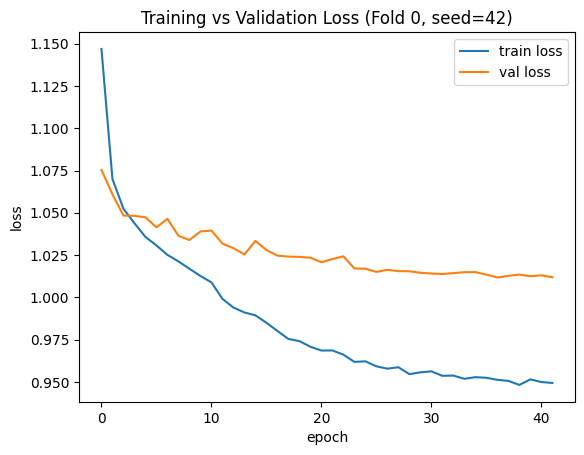

In [ ]:
import matplotlib.pyplot as plt

hist0 = fold_histories[0].history  # Fixed variable name
plt.figure()
plt.plot(hist0["loss"], label="train loss")
plt.plot(hist0["val_loss"], label="val loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("Training vs Validation Loss (Fold 0, seed=42)")  # Fixed title
plt.show()

# Section 3: Tuning Hyper-parameters 
In this section, parameters including learning rate, weight decay and batch size will be tuned to explore their impacts on the model's performance. 

Stage 1: “big wins” search (capacity + LR + dropout)

Stage 2: fine tuning (regularisation / optimiser)

In [ ]:
import itertools
import pandas as pd

def config_grid(base):
    """Generate grid of configurations to try"""
    hidden_list = [(128, 64), (256, 128), (128, 64, 32)]
    lr_list = [1e-3, 3e-4]
    dropout_list = [0.1, 0.3]

    for hu, lr, dr in itertools.product(hidden_list, lr_list, dropout_list):
        cfg = dict(base)
        cfg["hidden_units"] = hu
        cfg["lr"] = lr
        cfg["dropout"] = dr
        yield cfg

# Base configuration
base_config = {
    "hidden_units": (128, 64),
    "activation": "relu",
    "dropout": 0.2,
    "batchnorm": True,
    "l2": 1e-4,
    "init": "he_normal",

    "optimizer": "adamw",
    "lr": 1e-3,
    "weight_decay": 1e-4,

    "batch_size": 256,
    "max_epochs": 50,
    "patience": 5,
}

# =====================================
# PROPER APPROACH: Tune on FOLD 0 ONLY
# =====================================
print("=== Hyperparameter Tuning on Fold 0 ===\n")

# Get fold 0 data
train_idx, val_idx = folds[0]
X_train, Y_train = X[train_idx], y_onehot[train_idx]
X_val, Y_val = X[val_idx], y_onehot[val_idx]

# Normalize using training data only
mean = X_train.mean(axis=0)
std = X_train.std(axis=0) + 1e-8
X_train_norm = (X_train - mean) / std
X_val_norm = (X_val - mean) / std

tuning_results = []

for cfg in config_grid(base_config):
    # Train on fold 0 only with fixed seed 42
    model, hist, metrics = train_one_fold_keras(
        X_train_norm, Y_train, X_val_norm, Y_val,
        cfg, seed=42, verbose=0
    )
    
    tuning_results.append({
        "val_macro_f1": metrics["val_macro_f1"],
        "val_acc": metrics["val_acc"],
        "gap_macro_f1": metrics["gap_macro_f1"],
        "gap_loss": metrics["gap_loss"],
        "hidden_units": cfg["hidden_units"],
        "lr": cfg["lr"],
        "dropout": cfg["dropout"],
    })
    
    print(f"Config: hidden={cfg['hidden_units']}, lr={cfg['lr']}, dropout={cfg['dropout']} | "
          f"Val F1={metrics['val_macro_f1']:.4f}, Gap={metrics['gap_macro_f1']:.4f}")

# Sort by validation F1
df_tuning = pd.DataFrame(tuning_results).sort_values("val_macro_f1", ascending=False)

print("\n=== Top 5 Configurations (from Fold 0 tuning) ===")
display(df_tuning.head(5))

# Select best config
best_config_row = df_tuning.iloc[0]
best_config = dict(base_config)
best_config["hidden_units"] = best_config_row["hidden_units"]
best_config["lr"] = best_config_row["lr"]
best_config["dropout"] = best_config_row["dropout"]

print(f"\n=== Best Config Selected ===")
print(f"Hidden units: {best_config['hidden_units']}")
print(f"Learning rate: {best_config['lr']}")
print(f"Dropout: {best_config['dropout']}")

# =====================================
# NOW evaluate on ALL folds with best config
# =====================================
print("\n=== Evaluating Best Config on All 10 Folds ===\n")

df_gap, fold_models, fold_histories, fold_normalizations = run_kfold_cv_keras(
    X, y_onehot, folds, best_config, verbose=0
)

=== Hyperparameter Tuning on Fold 0 ===

Config: hidden=(128, 64), lr=0.001, dropout=0.1 | Val F1=0.4447, Gap=-0.0805
Config: hidden=(128, 64), lr=0.001, dropout=0.3 | Val F1=0.4377, Gap=-0.0531
Config: hidden=(128, 64), lr=0.0003, dropout=0.1 | Val F1=0.4411, Gap=-0.0428
Config: hidden=(128, 64), lr=0.0003, dropout=0.3 | Val F1=0.4363, Gap=-0.0330
Config: hidden=(256, 128), lr=0.001, dropout=0.1 | Val F1=0.4372, Gap=-0.0540
Config: hidden=(256, 128), lr=0.001, dropout=0.3 | Val F1=0.4414, Gap=-0.0914
Config: hidden=(256, 128), lr=0.0003, dropout=0.1 | Val F1=0.4448, Gap=-0.0685
Config: hidden=(256, 128), lr=0.0003, dropout=0.3 | Val F1=0.4423, Gap=-0.0373
Config: hidden=(128, 64, 32), lr=0.001, dropout=0.1 | Val F1=0.4456, Gap=-0.0584
Config: hidden=(128, 64, 32), lr=0.001, dropout=0.3 | Val F1=0.4420, Gap=-0.0349
Config: hidden=(128, 64, 32), lr=0.0003, dropout=0.1 | Val F1=0.4433, Gap=-0.0675
Config: hidden=(128, 64, 32), lr=0.0003, dropout=0.3 | Val F1=0.4375, Gap=-0.0208

=== Top 

,val_macro_f1,val_acc,gap_macro_f1,gap_loss,hidden_units,lr,dropout
8,0.445639,0.500315,-0.058427,0.044502,"(128, 64, 32)",0.0010,0.1
6,0.444800,0.497268,-0.068549,0.053753,"(256, 128)",0.0003,0.1
0,0.444716,0.499790,-0.080537,0.076304,"(128, 64)",0.0010,0.1
10,0.443271,0.494327,-0.067471,0.059671,"(128, 64, 32)",0.0003,0.1
7,0.442257,0.491805,-0.037271,0.023844,"(256, 128)",0.0003,0.3



=== Best Config Selected ===
Hidden units: (128, 64, 32)
Learning rate: 0.001
Dropout: 0.1

=== Evaluating Best Config on All 10 Folds ===

Fold 0: TrainF1=0.507  ValF1=0.430  Gap=-0.076 | TrainLoss=0.936  ValLoss=1.022
Fold 1: TrainF1=0.506  ValF1=0.430  Gap=-0.076 | TrainLoss=0.968  ValLoss=1.028
Fold 2: TrainF1=0.514  ValF1=0.449  Gap=-0.065 | TrainLoss=0.960  ValLoss=1.017
Fold 3: TrainF1=0.496  ValF1=0.438  Gap=-0.058 | TrainLoss=0.964  ValLoss=1.014
Fold 4: TrainF1=0.525  ValF1=0.448  Gap=-0.077 | TrainLoss=0.939  ValLoss=1.006
Fold 5: TrainF1=0.506  ValF1=0.445  Gap=-0.060 | TrainLoss=0.953  ValLoss=1.016
Fold 6: TrainF1=0.482  ValF1=0.439  Gap=-0.044 | TrainLoss=0.973  ValLoss=1.021
Fold 7: TrainF1=0.512  ValF1=0.449  Gap=-0.064 | TrainLoss=0.965  ValLoss=1.005
Fold 8: TrainF1=0.533  ValF1=0.439  Gap=-0.094 | TrainLoss=0.937  ValLoss=1.005
Fold 9: TrainF1=0.492  ValF1=0.458  Gap=-0.034 | TrainLoss=0.973  ValLoss=1.021

=== Gap summary (mean ± std) ===
      train_macro_f1  val

In [ ]:
# ----------------------------
# A1) Define the FINAL config (from tuning)
# ----------------------------
final_config = {
    "hidden_units": (256, 128),
    "activation": "relu",
    "dropout": 0.3,
    "batchnorm": True,
    "l2": 1e-4,
    "init": "he_normal",

    "optimizer": "adamw",
    "lr": 0.0003,
    "weight_decay": 1e-4,

    "batch_size": 256,
    "max_epochs": 50,  # or 150 if you have time
    "patience": 12,
}

# ----------------------------
# A2) Run 10-fold CV with final config
# ----------------------------
print("=== Running 10-Fold CV with Final Config ===\n")

df_final, fold_models, fold_histories, fold_normalizations = run_kfold_cv_keras(
    X, y_onehot, folds,
    final_config,
    verbose=0
)

# ----------------------------
# A3) Display results
# ----------------------------
print("\n=== Per-Fold Results ===")
display(df_final[["fold", "val_macro_f1", "val_acc", "gap_macro_f1", "gap_loss"]])

print("\n=== FINAL 10-FOLD SUMMARY (Report this) ===")
print(f"Val Macro-F1: {df_final['val_macro_f1'].mean():.4f} ± {df_final['val_macro_f1'].std():.4f}")
print(f"Val Accuracy: {df_final['val_acc'].mean():.4f} ± {df_final['val_acc'].std():.4f}")
print(f"Gap Macro-F1: {df_final['gap_macro_f1'].mean():.4f} ± {df_final['gap_macro_f1'].std():.4f}")
print(f"Gap Loss: {df_final['gap_loss'].mean():.4f} ± {df_final['gap_loss'].std():.4f}")

=== Running 10-Fold CV with Final Config ===

Fold 0: TrainF1=0.521  ValF1=0.447  Gap=-0.073 | TrainLoss=0.969  ValLoss=1.021
Fold 1: TrainF1=0.518  ValF1=0.443  Gap=-0.074 | TrainLoss=0.969  ValLoss=1.026
Fold 2: TrainF1=0.513  ValF1=0.451  Gap=-0.062 | TrainLoss=0.993  ValLoss=1.016
Fold 3: TrainF1=0.524  ValF1=0.441  Gap=-0.084 | TrainLoss=0.960  ValLoss=1.013
Fold 4: TrainF1=0.515  ValF1=0.455  Gap=-0.060 | TrainLoss=0.963  ValLoss=1.012
Fold 5: TrainF1=0.510  ValF1=0.448  Gap=-0.063 | TrainLoss=0.970  ValLoss=1.021
Fold 6: TrainF1=0.511  ValF1=0.438  Gap=-0.072 | TrainLoss=0.961  ValLoss=1.016
Fold 7: TrainF1=0.539  ValF1=0.456  Gap=-0.083 | TrainLoss=0.952  ValLoss=1.004
Fold 8: TrainF1=0.522  ValF1=0.442  Gap=-0.080 | TrainLoss=0.961  ValLoss=1.014
Fold 9: TrainF1=0.506  ValF1=0.454  Gap=-0.052 | TrainLoss=0.973  ValLoss=1.017

=== Gap summary (mean ± std) ===
      train_macro_f1  val_macro_f1  gap_macro_f1  final_train_loss  \
mean        0.517919      0.447605     -0.070314  

,fold,val_macro_f1,val_acc,gap_macro_f1,gap_loss
0,0,0.447158,0.499054,-0.073366,0.052082
1,1,0.443325,0.497524,-0.074413,0.056632
2,2,0.450893,0.505860,-0.061910,0.022102
3,3,0.440660,0.494491,-0.083827,0.052314
4,4,0.455333,0.516415,-0.059686,0.048314
5,5,0.447805,0.500387,-0.062683,0.050473
6,6,0.438403,0.496045,-0.072195,0.054522
7,7,0.456183,0.512457,-0.083129,0.051834
8,8,0.442099,0.500443,-0.080014,0.052918
9,9,0.454188,0.507058,-0.051917,0.044286



=== FINAL 10-FOLD SUMMARY (Report this) ===
Val Macro-F1: 0.4476 ± 0.0064
Val Accuracy: 0.5030 ± 0.0073
Gap Macro-F1: -0.0703 ± 0.0108
Gap Loss: 0.0485 ± 0.0099


In [ ]:
# Add detailed per-class metrics
from sklearn.metrics import classification_report
import pandas as pd

detailed_metrics = []

for fold_id, model in enumerate(fold_models):
    _, val_idx = folds[fold_id]
    X_val_raw = X[val_idx]
    Y_val = y_onehot[val_idx]
    
    # Apply normalization
    mean, std = fold_normalizations[fold_id]
    X_val_norm = (X_val_raw - mean) / std
    
    # Predict
    y_pred = np.argmax(model.predict(X_val_norm, verbose=0), axis=1)
    y_true = np.argmax(Y_val, axis=1)
    
    # Compute metrics
    from sklearn.metrics import precision_recall_fscore_support
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
    _, _, f1_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    
    detailed_metrics.append({
        "fold": fold_id,
        "precision_macro": prec,
        "recall_macro": rec,
        "f1_macro": f1,
        "f1_weighted": f1_weighted
    })

df_detailed = pd.DataFrame(detailed_metrics)
print("\n=== Detailed Metrics ===")
display(df_detailed)
print(f"\nPrecision (macro): {df_detailed['precision_macro'].mean():.4f} ± {df_detailed['precision_macro'].std():.4f}")
print(f"Recall (macro): {df_detailed['recall_macro'].mean():.4f} ± {df_detailed['recall_macro'].std():.4f}")
print(f"F1 (weighted): {df_detailed['f1_weighted'].mean():.4f} ± {df_detailed['f1_weighted'].std():.4f}")


=== Detailed Metrics ===


,fold,precision_macro,recall_macro,f1_macro,f1_weighted
0,0,0.456357,0.475829,0.447158,0.521169
1,1,0.450897,0.471042,0.443325,0.519458
2,2,0.455386,0.471389,0.450893,0.524669
3,3,0.449875,0.472451,0.440660,0.517017
4,4,0.457822,0.473935,0.455333,0.533048
5,5,0.456658,0.479500,0.447805,0.522802
6,6,0.448971,0.465789,0.438403,0.519169
7,7,0.458116,0.479909,0.456183,0.530151
8,8,0.448360,0.464667,0.442099,0.521259
9,9,0.459071,0.477788,0.454188,0.526171



Precision (macro): 0.4542 ± 0.0042
Recall (macro): 0.4732 ± 0.0053
F1 (weighted): 0.5235 ± 0.0051
